In [ ]:
# Импортируем необходимые библиотеки
import os
import json
import random
import re
import requests
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import timedelta
from transformers import AutoModelForCausalLM, AutoTokenizer
import kagglehub

In [ ]:
  # IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


Kaggle credentials set.
Kaggle credentials successfully validated.


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

mikhailkochetkov4848_syntetic_pyton_programming_path = kagglehub.dataset_download('mikhailkochetkov4848/syntetic-pyton-programming')
mikhailkochetkov4848_syntetic_pyton_programming_2_path = kagglehub.dataset_download('mikhailkochetkov4848/syntetic-pyton-programming-2')
mikhailkochetkov4848_syntetic_pyton_programming_3_path = kagglehub.dataset_download('mikhailkochetkov4848/syntetic-pyton-programming-3')
mikhailkochetkov4848_syntetic_pyton_programming_4_path = kagglehub.dataset_download('mikhailkochetkov4848/syntetic-pyton-programming-4')
mikhailkochetkov4848_list_of_thems_path = kagglehub.dataset_download('mikhailkochetkov4848/list-of-thems')
mikhailkochetkov4848_question_ansvers_for_python_in_russian_path = kagglehub.dataset_download('mikhailkochetkov4848/question-ansvers-for-python-in-russian')
mikhailkochetkov4848_pyton_questions_answers_clean_path = kagglehub.dataset_download('mikhailkochetkov4848/pyton-questions-answers-clean')
mikhailkochetkov4848_parsing_by_hand_path = kagglehub.dataset_download('mikhailkochetkov4848/parsing-by-hand')
mikhailkochetkov4848_first_listthem_path = kagglehub.dataset_download('mikhailkochetkov4848/first-listthem')
mikhailkochetkov4848_great_summ_dataset_path = kagglehub.dataset_download('mikhailkochetkov4848/great-summ-dataset')
mikhailkochetkov4848_ru_gpt_3__learn_pythonlean_to_end_checkpoint_378_pytorch_default_1_path = kagglehub.model_download('mikhailkochetkov4848/ru_gpt_3__learn_pythonlean_to_end_checkpoint_378/PyTorch/default/1')
mikhailkochetkov4848_ru_gpt_3_pyton_fine_rezult_fold_1_checkpoint_22_pytorch_default_1_path = kagglehub.model_download('mikhailkochetkov4848/ru_gpt_3_pyton_fine_rezult_fold_1_checkpoint_22/PyTorch/default/1')
mikhailkochetkov4848_ru_gpt_3_python_level_iifold_3checkpoint_50_pytorch_default_2_path = kagglehub.model_download('mikhailkochetkov4848/ru-gpt-3_python_level_iifold_3checkpoint-50/PyTorch/default/2')
mikhailkochetkov4848_check_200_pytorch_default_1_path = kagglehub.model_download('mikhailkochetkov4848/check_200/PyTorch/default/1')
mikhailkochetkov4848_ru_gpt_3_python_level_ii_fold_1_checkpoint_50_pytorch_default_1_path = kagglehub.model_download('mikhailkochetkov4848/ru_gpt_3_python_level_ii_fold_1_checkpoint_50/PyTorch/default/1')
mikhailkochetkov4848_ru_gpt_3_pyton_fine_rezult_fold_1_checkpoint_22_pytorch_default_2_path = kagglehub.model_download('mikhailkochetkov4848/ru_gpt_3_pyton_fine_rezult_fold_1_checkpoint_22/PyTorch/default/2')
mikhailkochetkov4848_ru_gpt_3_pyton_fine_rezult_fold_1_checkpoint_22_pytorch_default_3_path = kagglehub.model_download('mikhailkochetkov4848/ru_gpt_3_pyton_fine_rezult_fold_1_checkpoint_22/PyTorch/default/3')

print('Data source import complete.')


100%|██████████| 183M/183M [00:01<00:00, 128MB/s]

Extracting files...



  0%|          | 0.00/4.95M [00:00<?, ?B/s]



  0%|          | 0.00/1.21M [00:00<?, ?B/s]





  0%|          | 0.00/2.83G [00:00<?, ?B/s]




...





100%|██████████| 1.25k/1.25k [00:00<00:00, 1.65MB/s]

  0%|          | 9.00M/2.83G [00:00<01:58, 25.6MB/s]




100%|██████████| 9.55k/9.55k [00:00<00:00, 18.2MB/s]




100%|██████████| 4.81k/4.81k [00:00<00:00, 9.97MB/s]


  2%|▏         | 9.00M/445M [00:00<00:17, 25.9MB/s]




  0%|          | 0.00/1.54M [00:00<?, ?B/s]


  0%|          | 12.0M/2.83G [00:00<02:14, 22.5MB/s]



100%|██████████| 0.99k/0.99k [00:00<00:00, 2.54MB/s]
100%|██████████| 1.54M/1.54M [00:00<00:00, 18.3MB/s]


  3%|▎         | 12.0M/445M [00:00<00:20, 22.6MB/s]
  1%|          | 15.0M/2.83G [00:00<02:06, 23.9MB/s]

  4%|▎         | 16.0M/445M [00:00<00:16, 27.6MB/s]
  1%|          | 20.0M/2.83G [00:00<01:35, 31.6MB/s]

  5%|▍         | 22.0M/445M [00:00<00:12, 36.2MB/s]
  1%|          | 26.0M/2.83G [00:00<01:19, 38.1MB/s]

  6%|▌         | 27.0M/445M [00:00<00:11, 39.7MB/s]
  1%|          | 33.0M/2.83G [00:01<01:05, 46.2MB/s]

  7%|▋         | 33.0M/445M [00:00<00:09, 46.1MB/s]
  1%|▏         | 39.0M/2.83G [00:01<01:02, 48.2MB/s]

  9%|▊         | 38.0M/445M [00:01<00:09, 45.5MB/s]
  2%|▏         | 46.0M/2.83G [00:01<00:54, 54.7MB/s]

 10%|▉         | 44.0M/445M [00:01<00:08, 50.3MB/s]
  2%|▏         | 53.0M/2.83G [00:01<00:50, 59.1MB/s]

 11%|█         | 50.0M/445M [00:01<00:07, 53.8MB/s]
  2%|▏         | 61.0M/2.83G [00:01<00:45,

Data source import complete.


In [ ]:
#функция  демонстрации Json
def display_file_content(file_path):
    """
    Универсальная функция для чтения и демонстрации содержимого JSON и JSONL файлов.

    Args:
        file_path (str): Путь к файлу.

    Raises:
        FileNotFoundError: Если файл не существует.
        ValueError: Если формат файла не поддерживается.
    """
    # Проверяем существование файла
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"File '{file_path}' not found.")

    # Определяем тип файла по расширению
    _, file_extension = os.path.splitext(file_path)
    file_extension = file_extension.lower()

    try:
        if file_extension == ".json":
            # Чтение JSON файла
            with open(file_path, 'r', encoding='utf-8') as file:
                data = json.load(file)  # Загружаем JSON как Python-объект

            # Вывод содержимого JSON
            print("Content of the JSON file:")
            if isinstance(data, list):
                print("First 10 elements of the JSON file:")
                for item in data[:10]:
                    print(json.dumps(item, indent=4, ensure_ascii=False))
            else:
                print(json.dumps(data, indent=4, ensure_ascii=False))

        elif file_extension == ".jsonl":
            # Чтение JSONL файла
            with open(file_path, 'r', encoding='utf-8') as file:
                print("First 10 lines of the JSONL file:")
                for i, line in enumerate(file):
                    if i >= 10:
                        break
                    data = json.loads(line.strip())  # Преобразуем каждую строку в JSON объект
                    print(json.dumps(data, indent=4, ensure_ascii=False))

        else:
            raise ValueError(f"Unsupported file format: {file_extension}. Only .json and .jsonl are supported.")

    except Exception as e:
        print(f"Error reading or parsing the file: {e}")

In [ ]:
def display_jsonl_file_content(file_path, max_items=5):
    """
    Функция для чтения и демонстрации содержимого JSONL-файла.

    Args:
        file_path (str): Путь к JSONL-файлу.
        max_items (int): Максимальное количество записей для отображения.

    Raises:
        FileNotFoundError: Если файл не существует.
    """
    # Проверяем существование файла
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"File '{file_path}' not found.")

    try:
        print(f"Первые {max_items} записей из файла {os.path.basename(file_path)}:")
        with open(file_path, 'r', encoding='utf-8') as file:
            for i, line in enumerate(file):
                if i >= max_items:  # Ограничиваем вывод первыми max_items записями
                    break
                json_data = json.loads(line.strip())  # Преобразуем строку JSON в словарь Python
                print(json.dumps(json_data, indent=4, ensure_ascii=False))  # Красивый вывод JSON
    except Exception as e:
        print(f"Ошибка при чтении или парсинге JSONL-файла: {e}")


# Подготовка  и  этап  работы с  данными

Данный ноутбук - является отчетным  ноутбуком  по  дообучению речеовой модели основам  программирования Python. Данный ноутбук описывает порядок моих действий  при  обучениий модели.

Датасты и модели  загружены  на Kaggle и  при  необходимости  могут быть  самостоятельно загружены  по ссылкам указаным в коде.

Для себя я определил следующие критерии. Модель не должна быть большой, так как мои ресурсы ограничены. Когда я планировал обучение, я рассчитывал использовать только GPU Nvidia Tesla K80. Исходная модель не должна быть обучена программированию, иначе ни я, ни кто-то другой не смогут понять, что я смог обучить модель. Кроме того, предпочтение отдавалось моделям, которые можно загрузить без дополнительной регистрации и ключей. По этим критериям была выбрана модель RuGPT-3

Для загрузки базовой модели был использован код ниже. Код исполнялся на процессоре AMD Ryzen 5 5600G с Radeon Graphics 3.90 GHz. Оперативная память — 64,0 ГБ (доступно: 59,9 ГБ). Графический ускоритель — Nvidia Tesla K80

In [ ]:
'''
# Укажите путь к папке для сохранения модели
model_dir = '/home/mikl/Python_trener/RuGPT-3'

# Создайте папку, если она не существует
os.makedirs(model_dir, exist_ok=True)

# Имя модели RuGPT-3
model_name = 'sberbank-ai/rugpt3large_based_on_gpt2'

# Проверка загрузки токенизатора
try:
    print("Загрузка токенизатора...")
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    print("Токенизатор загружен успешно.")
except Exception as e:
    print(f"Ошибка при загрузке токенизатора: {e}")
    exit(1)  # Завершение программы при ошибке

# Проверка загрузки модели
try:
    print("Загрузка модели...")
    model = AutoModelForCausalLM.from_pretrained(model_name)
    print("Модель загружена успешно.")
except Exception as e:
    print(f"Ошибка при загрузке модели: {e}")
    exit(1)  # Завершение программы при ошибке

# Сохранение токенизатора и модели в указанную папку
try:
    print("Сохранение токенизатора и модели...")
    tokenizer.save_pretrained(model_dir)
    model.save_pretrained(model_dir)
    print(f'Модель и токенизатор успешно сохранены в {model_dir}')
except Exception as e:
    print(f'Ошибка при сохранении модели или токенизатора: {e}')

# Проверка наличия файлов в директории
print("Проверка сохраненных файлов:")
saved_files = os.listdir(model_dir)
print(saved_files)
'''



Для обучения модели потребовался датасет. Я располагал набором книг по программированию в формате PDF и некоторым количеством блокнотов. Анализ при создании эмбеддингов на данном материале показал, что, несмотря на то что книг много, в них содержится много отвлечений, побочной и лишней информации. Потребовался более структурированный и упорядоченный датасет, в идеале размеченный. Попытки работы с доступными речевыми моделями показали, что можно вручную отправлять обращения к различным моделям и собирать информацию. Доступные крупные модели, такие как GPT-4, могли давать качественный материал, но после получения он требовал дальнейшей обработки

Ниже код загружает датасет по ссылке с моей страницы КАГЛ приводит список документов созданных вручную  при обращении к различным языковым моделям.

In [ ]:
# Загружаем датасет
path = kagglehub.dataset_download("mikhailkochetkov4848/parsing-by-hand")
print("Path to dataset files:", path)

# Получаем список файлов в загруженном датасете
file_list = os.listdir(path)
print("\nList of documents in the dataset:")
for file_name in file_list:
    print(file_name)

# Проверяем, что файлы существуют
if not file_list:
    raise FileNotFoundError("No files found in the dataset directory.")

# Выбираем два случайных файла
random_files = random.sample(file_list, 2)
print("\nSelected random files for preview:")
for file_name in random_files:
    print(file_name)

# Выводим первые 10 строк из каждого выбранного файла
for file_name in random_files:
    file_path = os.path.join(path, file_name)
    print(f"\nFirst 10 lines of {file_name}:")
    try:
        with open(file_path, 'r', encoding='utf-8') as file:
            for _ in range(10):
                print(file.readline().strip())
    except Exception as e:
        print(f"Error reading {file_name}: {e}")

Path to dataset files: /root/.cache/kagglehub/datasets/mikhailkochetkov4848/parsing-by-hand/versions/1

List of documents in the dataset:
Jupyter Notebook.txt
Dense        .txt
Python   .txt
Pandas.txt
_.txt
.txt
ELT     .txt
SQL    .txt

Selected random files for preview:
_.txt
SQL    .txt

First 10 lines of _.txt:

1.1 Основы машинного обучения
◦ Машинное обучение (МО) — это область искусственного интеллекта, которая фокусируется на разработке алгоритмов и моделей, позволяющих компьютерам обучаться на основе данных и делать прогнозы или принимать решения без явного программирования. В отличие от традиционного программирования, где разработчик задает конкретные правила и инструкции, в машинном обучении система сама выявляет закономерности и зависимости в данных.
1.1.1 Что такое машинное обучение?
◦ Машинное обучение можно охарактеризовать как процесс, в котором компьютерная система использует данные для улучшения своей производительности в выполнении определенной задачи. Это может быт

Было  решено  приступить к генерации синтетическеого датасета. Основой, для уверенностит в том, что это будет успешно, был  опыт использования  локальных моделей  при помощи фремворков ollama  особенно LM Studio.  В качестве  основы  для  дальнейше генрации  при  обрашении к крупным языковым  моделям  был собран список  тем  по которым было решено  проводить генрацию.

In [ ]:
pip install kagglehub[pandas-datasets]

Ниже  представлена первая врсия такого списка.

In [ ]:
# Загружаем
path = kagglehub.dataset_download("mikhailkochetkov4848/first-listthem")
print("Path to dataset files:", path)
# Проверяем, что файл them_list.json существует
json_file_name = "them_list.json"
json_file_path = os.path.join(path, json_file_name)

if not os.path.exists(json_file_path):
    raise FileNotFoundError(f"File '{json_file_name}' not found in the dataset directory.")

Path to dataset files: /kaggle/input/first-listthem


In [ ]:
display_file_content(json_file_path)

Content of the JSON file:
{
    "темы_машинного_обучения_на_русском": {
        "установка_и_настройка_Python": {
            "установка_Python_и_pip": [],
            "настройка_окружения": {
                "virtualenv": [],
                "conda": []
            },
            "использование_пакетного_менеджера": {
                "pip": []
            },
            "редакторы_кода": {
                "IDLE": [],
                "PyCharm": [],
                "Jupyter_Notebook": []
            }
        },
        "основы_Python": {
            "синтаксис_и_типы_данных": [],
            "структуры_данных": {
                "списки": [],
                "кортежи": [],
                "словари": [],
                "множества": []
            },
            "управляющие_конструкции": {
                "условия": [],
                "циклы": []
            },
            "функции_и_модули": [],
            "исключения_и_обработка_ошибок": [],
            "работа_с_файлами_и_директор

На остове первой версии списка тем испооьзовлся наприр код ниже на локальных  ресурсах

## Код перенесенный с локального сервера и удаленного сервера не  адаптирован  к  запуску в блокноте

In [ ]:
'''
import json
import requests
import csv
import os
import logging
from datetime import datetime

# Конфигурация API
API_URL = "http://localhost:1234/v1/chat/completions"  # Адрес сервера
MODEL_NAME = "gemma-2-9b-it"  # Имя модели
THEME_LIST_PATH = "/home/mikl/Python_trener/Syntetic_data/Version_2/them_list.json"  # Путь к файлу тем
RESULTS_DIR = "/home/mikl/Python_trener/Syntetic_data/Version_2/result"  # Папка для результатов
RESULTS_FILE = os.path.join(RESULTS_DIR, "code_examples.csv")  # Путь к файлу результатов
CHECKPOINT_FILE = os.path.join(RESULTS_DIR, "checkpoint.json")  # Файл для сохранения прогресса

# Настройка логирования
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s",
    handlers=[
        logging.FileHandler(os.path.join(RESULTS_DIR, "generation.log")),
        logging.StreamHandler()
    ]
)
logger = logging.getLogger()

# Чтение тем из JSON-файла
def read_themes(file_path):
    with open(file_path, 'r', encoding='utf-8') as f:
        return json.load(f)

# Загрузка прогресса из файла
def load_checkpoint():
    if os.path.exists(CHECKPOINT_FILE):
        with open(CHECKPOINT_FILE, 'r', encoding='utf-8') as f:
            return json.load(f)
    return {"last_theme_index": -1, "results": []}

# Сохранение прогресса в файл
def save_checkpoint(last_theme_index, results):
    with open(CHECKPOINT_FILE, 'w', encoding='utf-8') as f:
        json.dump({"last_theme_index": last_theme_index, "results": results}, f)

# Рекурсивная функция для извлечения тем нижнего уровня
def extract_lowest_level_themes(themes_dict, parent_path=""):
    themes_list = []
    for key, value in themes_dict.items():
        current_path = f"{parent_path}/{key}" if parent_path else key
        if isinstance(value, dict) and value:  # Если значение - непустой словарь
            themes_list.extend(extract_lowest_level_themes(value, current_path))
        else:  # Если значение - пустой словарь или список (тема нижнего уровня)
            themes_list.append(current_path)
    return themes_list

# Генерация урока с разными стилями объяснений и примерами кода
def generate_lesson(topic):
    styles = {
        "Академик (gud)": "Подробный, качественный, без ошибок. Объяснение: Четкое, структурированное, с использованием правильной терминологии.",
        "Наукообразный дурак (bad)": "Использует умные слова, но неправильно их применяет, путается в логике. Объяснение: Запутанное, с ошибками в терминологии и логике.",
        "Аспирант (gud)": "Доступный, простой, но последовательный и без ошибок. Объяснение: Понятное, с использованием простых терминов.",
        "Глупый аспирант (bad)": "Неумелый, с множеством ошибок, не может понятно объяснить. Объяснение: Запутанное, с ошибками в терминологии и логике."
    }

    lesson = {"Тема": topic}

    for style, description in styles.items():
        prompt = (f"Сгенерируй урок на тему '{topic}' в стиле '{style}'. "
                  f"Включи объяснение и 10 батчей примеров кода: 6 батчей с правильным кодом и 4 батча с ошибками. "
                  f"Каждый батч должен содержать 5 примеров кода. "
                  f"Для стилей 'bad' добавь ошибки и прокомментируй их. "
                  f"Примеры кода должны быть помечены как 'gud' или 'bad'.")

        logger.info(f"Генерация урока для темы '{topic}' в стиле '{style}'...")
        response = requests.post(API_URL, json={
            "model": MODEL_NAME,
            "messages": [{"role": "user", "content": prompt}]
        })

        if response.status_code == 200:
            lesson[style] = response.json().get('choices', [{}])[0].get('message', {}).get('content', '')
            logger.info(f"Урок для темы '{topic}' в стиле '{style}' успешно сгенерирован.")
        else:
            logger.error(f"Ошибка при обращении к модели: {response.status_code} - {response.text}")
            lesson[style] = ""

    return lesson

# Сохранение результатов в CSV-файл
def save_results_to_csv(results, file_path):
    with open(file_path, 'w', newline='', encoding='utf-8') as csvfile:
        writer = csv.writer(csvfile)
        writer.writerow(['Тема', 'Стиль', 'Объяснение и код'])  # Заголовки столбцов
        for lesson in results:
            theme = lesson["Тема"]
            for style, content in lesson.items():
                if style != "Тема":
                    writer.writerow([theme, style, content])

# Основная функция
def main():
    # Создание директории, если она не существует
    os.makedirs(RESULTS_DIR, exist_ok=True)

    # Загрузка тем и прогресса
    themes_dict = read_themes(THEME_LIST_PATH)
    themes_list = extract_lowest_level_themes(themes_dict)
    checkpoint = load_checkpoint()
    last_theme_index = checkpoint["last_theme_index"]
    results = checkpoint["results"]

    logger.info(f"Начало генерации. Последняя обработанная тема: {last_theme_index}")

    for i, theme in enumerate(themes_list):
        if i <= last_theme_index:
            logger.info(f"Пропуск темы '{theme}' (уже обработана).")
            continue

        logger.info(f"Обработка темы {i + 1}/{len(themes_list)}: {theme}")
        lesson = generate_lesson(theme)
        results.append(lesson)

        # Сохранение прогресса
        save_checkpoint(i, results)
        logger.info(f"Прогресс сохранен. Обработано тем: {i + 1}/{len(themes_list)}")

    # Сохранение финальных результатов
    save_results_to_csv(results, RESULTS_FILE)
    logger.info(f"Результаты сохранены в: {RESULTS_FILE}")

    # Удаление файла прогресса после завершения
    if os.path.exists(CHECKPOINT_FILE):
        os.remove(CHECKPOINT_FILE)
        logger.info("Файл прогресса удален.")

if __name__ == "__main__":
    try:
        main()
    except KeyboardInterrupt:
        logger.info("Выполнение прервано пользователем.")
    except Exception as e:
        logger.error(f"Произошла ошибка: {e}")
'''

Данный код  создает  аугментированный список мтериалов Ниже можно ознакомеиться с  тем, как этот матерал выглядит.

In [ ]:
# Загружаем последнюю версию датасета
path = kagglehub.dataset_download("mikhailkochetkov4848/syntetic-pyton-programming-3")
print("Path to dataset files:", path)

# Проверяем, что файл clean_code_examples.csv существует
csv_file_name = "clean_code_examples.csv"
csv_file_path = os.path.join(path, csv_file_name)

if not os.path.exists(csv_file_path):
    raise FileNotFoundError(f"File '{csv_file_name}' not found in the dataset directory.")

# Загружаем CSV-файл в DataFrame
try:
    df = pd.read_csv(csv_file_path)

    # Выводим первые 10 строк файла в виде таблицы
    print("\nFirst 10 rows of the CSV file:")
    display(df.head(10))  # Используем display для красивого вывода в Jupyter Notebook

    # Выводим информацию о структуре данных
    print("\nDataFrame structure:")
    print(df.info())

except Exception as e:
    print(f"Error reading the CSV file: {e}")

100%|██████████| 619k/619k [00:00<00:00, 763kB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/mikhailkochetkov4848/syntetic-pyton-programming-3/versions/1

First 10 rows of the CSV file:


,Тема,Метка класса,Объяснение и код
0,темы_машинного_обучения_на_русском/установка_и...,good,"Python – это язык программирования, обладающий..."
1,темы_машинного_обучения_на_русском/установка_и...,bad,😈\n\n### Установка Python и Pip\n\n**Шаг 1: Ск...
2,темы_машинного_обучения_на_русском/установка_и...,good,Без них ты не сможешь использовать ни один из ...
3,темы_машинного_обучения_на_русском/установка_и...,bad,Сегодня мы будем устанавливать Python и pip – ...
4,темы_машинного_обучения_на_русском/установка_и...,good,Виртуальная среда – это изолированная оболочка...
5,темы_машинного_обучения_на_русском/установка_и...,bad,"Представляешь, ты можешь создавать отдельные м..."
6,темы_машинного_обучения_на_русском/установка_и...,good,"Представьте себе их как отдельные ""комнатки"" д..."
7,темы_машинного_обучения_на_русском/установка_и...,bad,"**Virtualenv**. Что за зверь такой? Понимаешь,..."
8,темы_машинного_обучения_на_русском/установка_и...,good,"В этом уроке мы изучим, как установить и настр..."
9,темы_машинного_обучения_на_русском/установка_и...,bad,Сегодня мы будем покорять вершины искусственно...



DataFrame structure:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 592 entries, 0 to 591
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Тема              592 non-null    object
 1   Метка класса      592 non-null    object
 2   Объяснение и код  592 non-null    object
dtypes: object(3)
memory usage: 14.0+ KB
None


Генерация  производилась локально поднятым сервером LM студио при  обращени к локальному адресу сервера и моделью Gemma-2. Модель в формате GGUF является кавантованной. Модель зарекомендовала себя как исключительно качествепнная. Модель  на столько мне  понравилась, что был создан  и успешно апробированn телеграмм бот который по api обращался к модели Gemma-2 LMStudio. В коде я пытался использовать уже сгенерированные мтералы, но на практике  это только ограничивало функционал бота и функция  рабты  по локалным  докумнтам  была  отключна

In [ ]:
'''
import requests
from telegram import Update
from telegram.ext import Application, CommandHandler, MessageHandler, filters, ContextTypes
from pathlib import Path
import os
import datetime
import asyncio
import logging

# Настройка логирования
logging.basicConfig(
    format='%(asctime)s - %(name)s - %(levelname)s - %(message)s',
    level=logging.INFO
)

# Конфигурация путей
KARANTIN_DIR = Path('/home/mikl/Python_trener/lessons/Karantin')  # Директория для новых уроков
ARCHIVE_DIR = Path('/home/mikl/Python_trener/lessons/archiv')  # Директория архива

# Создание директорий
KARANTIN_DIR.mkdir(parents=True, exist_ok=True)
ARCHIVE_DIR.mkdir(parents=True, exist_ok=True)

# Конфигурация API
API_URL = "http://localhost:1234/v1/chat/completions"  # Адрес сервера
MODEL_NAME = "gemma-2-9b-it"

# Приветственные фразы
GREETINGS = ['привет', 'здравствуйте', 'добрый день', 'hello']

# Сохранение вопросов и ответов
def save_to_karantin(question, answer):
    """Сохраняет вопрос и ответ в карантинную директорию."""
    timestamp = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
    file_path = KARANTIN_DIR / f'{timestamp}_qa.txt'
    with open(file_path, 'w', encoding='utf-8') as file:
        file.write(f"Вопрос: {question}\nОтвет: {answer}\n")
    return file_path

# Поиск готового ответа
def find_existing_answer(question):
    """Ищет существующий ответ в архиве."""
    for file_path in ARCHIVE_DIR.glob('*.txt'):
        try:
            with open(file_path, 'r', encoding='utf-8') as file:
                content = file.read()
                if question.lower() in content.lower():
                    return content.split("Ответ: ")[1].strip()
        except Exception as e:
            logging.error(f"Ошибка при чтении файла {file_path}: {e}")
    return None

# Генерация ответа через API
async def generate_response(question: str) -> str:
    """Генерирует ответ с помощью локального API."""
    payload = {
        "model": MODEL_NAME,
        "messages": [
            {"role": "user", "content": question},  # Вопрос пользователя
        ],
        "temperature": 0.7,
        "max_tokens": 4096,
        "stream": False
    }

    try:
        response = requests.post(API_URL, json=payload, timeout=180)
        if response.status_code == 200:
            result = response.json()
            assistant_message = result["choices"][0]["message"]["content"]
            return assistant_message.strip()
        else:
            logging.error(f"Ошибка API: {response.status_code} - {response.text}")
            return "Не удалось получить ответ от модели."
    except Exception as e:
        logging.error(f"Ошибка при запросе к API: {e}")
        return "Технические неполадки. Попробуйте позже."

# Обработчик команды /start
async def start(update: Update, context: ContextTypes.DEFAULT_TYPE) -> None:
    await update.message.reply_text(
        'Привет! Я бот, который поможет вам с любыми вопросами. Задайте ваш вопрос!'
    )

# Обработчик сообщений
async def handle_message(update: Update, context: ContextTypes.DEFAULT_TYPE) -> None:
    user_question = update.message.text.strip()
    await update.message.chat.send_action(action="typing")

    # Обработка приветствий
    if user_question.lower() in GREETINGS:
        await update.message.reply_text("Здравствуйте! Я готов помочь вам с любыми вопросами.")
        return

    # Поиск готового ответа
    existing_answer = find_existing_answer(user_question)
    if existing_answer:
        await update.message.reply_text(existing_answer)
        return

    # Генерация нового ответа
    response = await generate_response(user_question)
    if response:
        save_to_karantin(user_question, response)  # Сохраняем новый урок
        if len(response) > 4096:
            chunks = [response[i:i + 4096] for i in range(0, len(response), 4096)]
            for chunk in chunks:
                await update.message.reply_text(chunk)
        else:
            await update.message.reply_text(response)
    else:
        await update.message.reply_text("Пожалуйста, уточните ваш вопрос.")

# Главная функция
def main() -> None:
    application = Application.builder().token(
        "USE YOU TOKEN"
    ).build()
    application.add_handler(CommandHandler("start", start))
    application.add_handler(MessageHandler(filters.TEXT & ~filters.COMMAND, handle_message))
    application.run_polling()

if __name__ == '__main__':
    main()
'''

Надо отметить, что эксплуатация сервера в  домашних условиях создавала  определнные  трудности. Благодая студенческойвзаимовыручке я  получил  помошь, за что очень благодарен всем тем кто ее  предооставил. Я  получил доступ к виртуальной машине на гипервизоре. В моем распоряжении было 56 потоков, 128 GB  ОЗУ, HDD -100 GB.С  этого момента я  получил возможность спать в  тишине. К томуже сервер  работал хоть и неспеша, но сушественно стабильнее чем  локальны рескурсы и не было неоходмости следить за  пергревом.

Был создан новый, более подробнвый список тем, коьторый и служил  основой  для  дальнейшей генрации мтреиалов на сревре. Новый список  по структуре повторял пршлый список но отличался чуть большим количестовом тем  Доступ осушествлялся через  подключение  по SSH.

In [ ]:
# Путь к датасету
dataset_path = kagglehub.dataset_download('mikhailkochetkov4848/list-of-thems')

# Проверяем, что файл существует
json_file_name = "thems_examples.json"
json_file_path = os.path.join(dataset_path, json_file_name)

if not os.path.exists(json_file_path):
    raise FileNotFoundError(f"File '{json_file_name}' not found in the dataset directory.")


100%|██████████| 4.82k/4.82k [00:00<00:00, 5.93MB/s]

Extracting files...


In [ ]:
display_file_content(json_file_path)

Content of the JSON file:
{
    "темы_машинного_обучения_на_русском": {
        "установка_и_настройка_Python": {
            "установка_Python_и_pip": [
                "Установка Python на Windows",
                "Установка Python на Linux",
                "Установка Python на macOS",
                "Обновление pip до последней версии"
            ],
            "настройка_окружения": {
                "virtualenv": [
                    "Создание виртуального окружения",
                    "Активация виртуального окружения",
                    "Установка пакетов в виртуальное окружение"
                ],
                "conda": [
                    "Установка Anaconda",
                    "Создание окружения в Conda",
                    "Управление пакетами в Conda"
                ]
            },
            "использование_пакетного_менеджера": {
                "pip": [
                    "Установка пакетов через pip",
                    "Обновление пакетов через pip

Началась генерация  новых материалов. Надо сказать, что в ральности после каждой новй генрации производилась  попытка обучить на матералах модель. После  этого формклировались  новые требования и производилась генерация новых двнных. Таким образом,эволюция учебных матералов и эволюция учебной моедли шли  параллельно. Не было такого, чтобы сначала  закончить генрацию всех матералов,а потом приступить к обучению.Процесс чередовался. Мы  будем помнить об этом изучая датасеты. Анализ моделей будет  приведен отельно. Сначала разберм все варнианты генерации  данных.

In [ ]:
'''
import json
import os
import threading
import queue
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from torch.utils.data import DataLoader, TensorDataset
import logging

# Настройка логирования
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[
        logging.FileHandler('training.log'),
        logging.StreamHandler()
    ]
)

# Глобальные параметры многопоточности
NUM_THREADS_GENERATE = 36  # 2/3 от доступных ядер для генерации
NUM_THREADS_TRAIN = 20     # Оставшиеся ядра для обучения
MAX_QUEUE_SIZE = 100       # Максимальный размер очереди для генерации

# Файлы для сохранения данных
MATERIALS_FILE = "generated_materials.jsonl"
PROCESSED_THEMES_FILE = "processed_themes.json"
MODEL_SAVE_DIR = "saved_model"  # Папка для сохранения модели

# Загрузка данных из JSON
def load_themes(json_file):
    try:
        if not os.path.exists(json_file):
            logging.error(f"Файл {json_file} не найден.")
            return None

        with open(json_file, 'r', encoding='utf-8') as f:
            data = json.load(f)
        logging.info(f"Загружены темы из файла {json_file}.")
        return data.get('темы_машинного_обучения_на_русском', {})
    except Exception as e:
        logging.error(f"Ошибка при загрузке файла {json_file}: {e}")
        return None

# Загрузка обработанных тем
def load_processed_themes(filename=PROCESSED_THEMES_FILE):
    if os.path.exists(filename):
        try:
            with open(filename, 'r', encoding='utf-8') as f:
                return json.load(f)
        except Exception as e:
            logging.warning(f"Не удалось загрузить обработанные темы: {e}")
    return {}

# Сохранение обработанных тем
def save_processed_themes(processed_themes, filename=PROCESSED_THEMES_FILE):
    try:
        with open(filename, 'w', encoding='utf-8') as f:
            json.dump(processed_themes, f, ensure_ascii=False, indent=4)
        logging.info(f"Сохранены обработанные темы в файл {filename}.")
    except Exception as e:
        logging.error(f"Ошибка при сохранении обработанных тем: {e}")

# Рекурсивная обработка тем с проверкой
def process_themes(themes, themes_queue, processed_themes):
    for theme_name, theme_content in themes.items():
        if isinstance(theme_content, dict):  # Если содержимое — это словарь, спускаемся глубже
            process_themes(theme_content, themes_queue, processed_themes)
        elif isinstance(theme_content, list):  # Если содержимое — это список, добавляем каждую подтему в очередь
            for subtopic in theme_content:
                key = f"{theme_name}_{subtopic}"
                if key not in processed_themes:
                    themes_queue.put({"theme": theme_name, "subtopic": subtopic})
                    processed_themes[key] = True
                    logging.info(f"Добавлено в очередь: тема={theme_name}, подтема={subtopic}")

# Генерация учебных материалов с помощью модели Gemma через Ollama
def generate_material(topic, subtopic):
    """
    Генерирует данные (уроки) с помощью модели Gemma.
    Возвращает словарь с материалами или None в случае ошибки.
    """
    system_prompt = (
        "Ты — опытный педагог, математик и специалист по машинному обучению. "
        "Твоя задача — создавать учебные материалы, которые объясняют машинное обучение через призму математики."
    )
    user_prompt = (
        f"Создайте подробный урок по теме: {topic}, подтема: {subtopic}\n\n"
        "Формат вывода:\n"
        "Вопрос: [текст вопроса на русском]\n"
        "Ответ: [развернутый текст ответа на русском]\n"
        "Метка: [Good/Bad]\n\n"
        "Урок должен содержать:\n"
        "- Введение в тему\n"
        "- Подробное объяснение основных концепций\n"
        "- Практические примеры правильного кода и примеры разнообразных ошибок\n"
        "- Задания для решения\n"
        "- Культурный диалог между преподавателем и учеником\n"
        "- Заключение\n\n"
    )

    prompt = f"{system_prompt}\n{user_prompt}"
    try:
        result = os.popen(f'echo "{prompt}" | ollama run gemma').read().strip()
        if result:
            logging.info(f"Успешно сгенерирован материал для темы: {topic}, подтемы: {subtopic}")
            return result
        else:
            logging.warning(f"Пустой материал для темы: {topic}, подтемы: {subtopic}")
            return None
    except Exception as e:
        logging.warning(f"Не удалось сгенерировать материал для темы: {topic}, подтемы: {subtopic}. Ошибка: {e}")
        return None

# Сохранение материалов в файл
def save_material(material, filename=MATERIALS_FILE):
    if material is not None:
        try:
            with open(filename, 'a', encoding='utf-8') as f:
                f.write(json.dumps(material, ensure_ascii=False) + "\n")
            logging.info(f"Материал сохранен в файл {filename}.")
        except Exception as e:
            logging.error(f"Ошибка при сохранении материала: {e}")

# Функция для многопоточной генерации
def generate_worker(themes_queue, results_queue, processed_themes):
    while not themes_queue.empty():
        theme = themes_queue.get()
        topic = theme['theme']
        subtopic = theme['subtopic']
        key = f"{topic}_{subtopic}"

        material = generate_material(topic, subtopic)
        if material is None:
            logging.warning(f"Материал для темы {topic}, подтемы {subtopic} не был создан.")
            themes_queue.task_done()
            continue

        generated_data = {
            "topic": topic,
            "subtopic": subtopic,
            "material": material
        }
        save_material(generated_data)
        results_queue.put(generated_data)
        processed_themes[key] = True  # Добавляем тему в список обработанных
        save_processed_themes(processed_themes)  # Сохраняем обновленный список
        logging.info(f"Материал для темы {topic}, подтемы {subtopic} сохранен.")
        themes_queue.task_done()

# Функция для многопоточного обучения
def train_worker(data_queue, training_model, training_tokenizer):
    optimizer = torch.optim.AdamW(training_model.parameters(), lr=1e-5, weight_decay=0.01)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)
    history = {"train_loss": []}

    while True:
        try:
            data = data_queue.get(timeout=1)  # Получаем данные с таймаутом
        except queue.Empty:
            break  # Если очередь пуста, выходим из цикла

        material = data['material']
        if not material.strip():
            logging.warning(f"Пустой материал для темы {data['topic']}, подтемы {data['subtopic']}. Пропускаем обучение.")
            data_queue.task_done()
            continue

        try:
            inputs = training_tokenizer(material, return_tensors="pt", padding=True, truncation=True, max_length=512)
            labels = inputs["input_ids"]
            dataset = TensorDataset(inputs['input_ids'], labels)
            train_loader = DataLoader(dataset, batch_size=4, shuffle=True)

            training_model.train()
            total_train_loss = 0
            for batch in train_loader:
                input_ids, labels = batch
                optimizer.zero_grad()
                outputs = training_model(input_ids, labels=labels)
                loss = outputs.loss
                loss.backward()
                optimizer.step()
                total_train_loss += loss.item()
            scheduler.step()

            avg_loss = total_train_loss / len(train_loader)
            history["train_loss"].append(avg_loss)
            logging.info(f"Обучение завершено для партии данных ({data['topic']} - {data['subtopic']}). Train Loss: {avg_loss:.4f}")
        except Exception as e:
            logging.error(f"Ошибка во время обучения на данных: {data}. Ошибка: {e}")
        finally:
            data_queue.task_done()

    # Сохранение истории обучения
    with open("training_metrics.json", "w") as f:
        json.dump(history, f)

# Загрузка модели для обучения
def load_training_model(model_name="sberbank-ai/rugpt3small_based_on_gpt2"):
    try:
        tokenizer = AutoTokenizer.from_pretrained(model_name)
        model = AutoModelForCausalLM.from_pretrained(model_name)
        logging.info(f"Модель для обучения {model_name} успешно загружена.")
        return tokenizer, model
    except Exception as e:
        logging.error(f"Ошибка при загрузке модели для обучения {model_name}: {e}")
        raise

# Сохранение модели
def save_model(model, tokenizer, save_dir=MODEL_SAVE_DIR):
    if not os.path.exists(save_dir):
        os.makedirs(save_dir)
    model.save_pretrained(save_dir)
    tokenizer.save_pretrained(save_dir)
    logging.info(f"Модель успешно сохранена в каталоге {save_dir}.")

# Основная функция
def main():
    try:
        # Загрузка тем из JSON
        THEMES_FILE_PATH = "/home/administrator/thems_examples.json"
        themes = load_themes(THEMES_FILE_PATH)
        if not themes:
            logging.error("Файл с темами пуст или не существует. Программа завершается.")
            return

        # Загрузка обработанных тем
        processed_themes = load_processed_themes()

        # Создание очередей
        themes_queue = queue.Queue()
        results_queue = queue.Queue()

        # Рекурсивное заполнение очереди темами
        process_themes(themes, themes_queue, processed_themes)

        if themes_queue.empty():
            logging.error("Очередь тем пуста. Программа завершается.")
            return

        # Загрузка модели для обучения (RuGPT-3)
        training_tokenizer, training_model = load_training_model("sberbank-ai/rugpt3small_based_on_gpt2")

        # Запуск потоков для генерации
        generate_threads = []
        for _ in range(NUM_THREADS_GENERATE):
            thread = threading.Thread(target=generate_worker, args=(themes_queue, results_queue, processed_themes))
            thread.daemon = True
            thread.start()
            generate_threads.append(thread)

        # Ожидание завершения генерации
        try:
            themes_queue.join()
            logging.info("Генерация материалов завершена.")
        except KeyboardInterrupt:
            logging.warning("Генерация прервана пользователем.")

        # Запуск потоков для обучения
        train_threads = []
        for _ in range(NUM_THREADS_TRAIN):
            thread = threading.Thread(target=train_worker, args=(results_queue, training_model, training_tokenizer))
            thread.daemon = True
            thread.start()
            train_threads.append(thread)

        # Ожидание завершения обучения
        try:
            results_queue.join()
            logging.info("Обучение завершено.")
        except KeyboardInterrupt:
            logging.warning("Обучение прервано пользователем.")

        # Сохранение модели
        save_model(training_model, training_tokenizer)

    except Exception as e:
        logging.error(f"Критическая ошибка: {e}")

if __name__ == '__main__':
    main()
'''

На удаленном сервере геренирующие речевые модели вызывались при помощи ollama. Представлленый выше программыный код  обращался к модели gemma,  отличной, от  той, что была  доступна в LM Studio на локальных  резурсах. Особенность кода в том, что  запросы  направлялись в модель в несколько  потоков. Не смотря на  то, что генерация одного ответа могла  занимать  от 4-до 10 минут, суммарная  производительлность, за счет  одновременного получения ответов из несольких  потоков  была  примлемой. В данной версии кода, с которой начиналась работа на удаленном сервере,я попытался сразу отправить сгенерированный материал в модель. Материал  был сгенерирован, но  при  попытке начать  обучение код ушел в  ошибку. Дальнешие версии кода. разделяли генерацию и  обучение.

In [ ]:
# === Загрузка датасета ===
dataset_path = kagglehub.dataset_download("mikhailkochetkov4848/syntetic-pyton-programming-2")
print("Path to dataset files:", dataset_path)

# === Получение пути к файлу ===
file_name = "generated_materials.jsonl"
jsonl_file_path = os.path.join(dataset_path, file_name)
if not os.path.exists(jsonl_file_path):
    raise FileNotFoundError(f"File '{file_name}' not found in the dataset directory.")


Path to dataset files: /kaggle/input/syntetic-pyton-programming-2


In [ ]:
display_jsonl_file_content(jsonl_file_path)

Первые 5 записей из файла generated_materials.jsonl:
{
    "topic": "установка_Python_и_pip",
    "subtopic": "Установка Python на Linux",
    "material": "**Вопрос:** Как установить Python на Linux?\n\n**Ответ:**\n\nДля установки Python на Linux можно использовать стандартный менеджер пакетов системы. В зависимости от вашей дистрибуции Linux команда может отличаться. \n\n**Для Debian/Ubuntu/Linux Mint:**\n\n```\nsudo apt-get install python3-pip\n```\n\n**Для Fedora/Red Hat:**\n\n```\nsudo yum install python3-pip\n```\n\n**Для Arch Linux:**\n\n```\nsudo pacman -S python3-pip\n```\n\n**Метка:** Good\n\n**Практический пример:**\n\n```python\nimport pip\n\npip install numpy\n```\n\nЭта команда устанавливает модуль NumPy, который является популярным библиотеком для математических вычислений в Python.\n\n**Моделирование ошибок:**\n\n* **Ошибка: pip не найден.** - Убедитесь, что pip установлена правильно.\n* **Ошибка: Модуль не найден.** - Убедитесь, что вы правильно написали название модуля

Сущестоваала проблема разнообразия материалов. Хотеловь  чтобы  по аждому уроку  бол несколько  правилных вариантов материалов, материалы с  ошибками, вопросы  по теме, диалоги. В датасете generated_materials.jsonl данные подаются в форме  диалогга.

Была  предпринята попытка сделать еще  более аугментированный датасет. После перво генерации  на  русском языке  полученный материал  должен был  отправлятьсяв модель  повторно для создания вариантов аугментации как на  русском так и  английском языках. Одако, представленный код  ниже сработал  только в части создания файла на  русском языке (big_data_materials_ru.jsonl) и ушел в  ошибку. В коде так так же  используется многопоточность при обращении к модели.

In [ ]:
'''
import json
import os
import threading
import queue
import logging
import random

# Настройка логирования
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[
        logging.FileHandler('big_data_log.txt'),
        logging.StreamHandler()
    ]
)

# Глобальные параметры
NUM_THREADS_GENERATE = 36  # 2/3 от 56 ядер для генерации
NUM_THREADS_AUGMENT = 20   # Оставшиеся ядра для аугментации
MAX_QUEUE_SIZE = 100       # Максимальный размер очереди

# Файлы для сохранения данных
MATERIALS_RU_FILE = "big_data_materials_ru.jsonl"
MATERIALS_EN_FILE = "big_data_materials_en.jsonl"
AUGMENTED_RU_FILE = "big_data_augmented_ru.jsonl"
AUGMENTED_EN_FILE = "big_data_augmented_en.jsonl"

# Загрузка тем из JSON
def load_themes(json_file):
    try:
        with open(json_file, 'r', encoding='utf-8') as f:
            data = json.load(f)
        logging.info(f"Загружены темы из файла {json_file}.")
        return data['темы_машинного_обучения_на_русском']
    except Exception as e:
        logging.error(f"Ошибка при загрузке файла {json_file}: {e}")
        raise

# Рекурсивная обработка тем
def process_themes(themes, themes_queue):
    for theme_name, theme_content in themes.items():
        if isinstance(theme_content, dict):  # Если содержимое — это словарь, спускаемся глубже
            process_themes(theme_content, themes_queue)
        elif isinstance(theme_content, list):  # Если содержимое — это список, добавляем каждую подтему в очередь
            for subtopic in theme_content:
                themes_queue.put({"theme": theme_name, "subtopic": subtopic})

# Загрузка уже обработанных тем
def load_existing_topics(filename):
    existing_topics = set()
    try:
        with open(filename, 'r', encoding='utf-8') as f:
            for line in f:
                data = json.loads(line)
                existing_topics.add((data['topic'], data['subtopic']))
    except FileNotFoundError:
        pass  # Файл еще не создан
    return existing_topics

# Генерация учебных материалов
def generate_material(topic, subtopic, language="ru"):
    """
    Генерирует данные (уроки) с помощью модели Gemma.
    Возвращает словарь с материалами или None в случае ошибки.
    """
    system_prompt = (
        "Ты — опытный педагог, математик и специалист по машинному обучению. "
        "Твоя задача — создавать учебные материалы, которые объясняют машинное обучение через призму математики, "
        "а программирование — как инструмент для решения реальных задач с помощью математических моделей."
    )
    user_prompt = (
        f"Создайте подробный урок по теме: {topic}, подтема: {subtopic} (язык: {language})\n\n"
        "Формат вывода:\n"
        "Вопрос: [текст вопроса]\n"
        "Ответ: [развернутый текст ответа]\n"
        "Метка: [Good/Bad]\n\n"
        "Урок должен содержать:\n"
        "- Введение в тему\n"
        "- Подробное объяснение основных концепций\n"
        "- Практические примеры правильного кода и примеры разнообразных ошибок\n"
        "- Вариации кода по стилю: короткий код, сложный код, использование простых циклов, функций, классов\n"
        "- Задания для решения\n"
        "- Культурный диалог между преподавателем и учеником\n"
        "- Заключение\n\n"
    )

    if language == "en":
        system_prompt = (
            "You are an experienced educator, mathematician, and machine learning specialist. "
            "Your task is to create educational materials that explain machine learning through the lens of mathematics, "
            "and programming as a tool for solving real-world problems using mathematical models."
        )
        user_prompt = (
            f"Create a detailed lesson on the topic: {topic}, subtopic: {subtopic} (language: {language})\n\n"
            "Output format:\n"
            "Question: [text of the question]\n"
            "Answer: [detailed answer text]\n"
            "Label: [Good/Bad]\n\n"
            "The lesson should include:\n"
            "- Introduction to the topic\n"
            "- Detailed explanation of key concepts\n"
            "- Practical examples of correct code and examples of various errors\n"
            "- Code variations in style: short code, complex code, use of simple loops, functions, classes\n"
            "- Tasks to solve\n"
            "- Cultural dialogue between teacher and student\n"
            "- Conclusion\n\n"
        )

    prompt = f"{system_prompt}\n{user_prompt}"
    try:
        result = os.popen(f'echo "{prompt}" | ollama run gemma').read().strip()
        if result:
            logging.info(f"Успешно сгенерирован материал для темы: {topic}, подтемы: {subtopic} (язык: {language})")
            return result
        else:
            logging.warning(f"Пустой материал для темы: {topic}, подтемы: {subtopic} (язык: {language})")
            return None
    except Exception as e:
        logging.error(f"Не удалось сгенерировать материал для темы: {topic}, подтемы: {subtopic}. Ошибка: {e}")
        return None

# Аугментация материалов
def augment_material(material):
    """
    Аугментирует материал, создавая новые варианты.
    """
    topic = material["topic"]
    subtopic = material["subtopic"]
    language = material["language"]

    augmented_materials = []

    # Генерация кода в разных стилях
    styles = ["циклы", "ООП", "функциональный стиль", "императивный стиль"]
    for style in styles:
        prompt = (
            f"Сгенерируй код по теме {topic}, подтеме {subtopic} в стиле {style} (язык: {language}). "
            f"Не добавляй комментарии."
        )
        augmented_code = generate_material(topic, subtopic, language)
        if augmented_code:
            augmented_materials.append({
                "topic": topic,
                "subtopic": subtopic,
                "material": augmented_code,
                "language": language,
                "style": style
            })

    # Генерация задач
    tasks_good = generate_material(topic, subtopic, language)
    tasks_bad = generate_material(topic, subtopic, language)
    if tasks_good:
        augmented_materials.append({
            "topic": topic,
            "subtopic": subtopic,
            "material": tasks_good,
            "language": language,
            "label": "Good"
        })
    if tasks_bad:
        augmented_materials.append({
            "topic": topic,
            "subtopic": subtopic,
            "material": tasks_bad,
            "language": language,
            "label": "Bad"
        })

    return augmented_materials

# Сохранение материалов в файл
def save_material(material, filename):
    if material is not None:
        os.makedirs(os.path.dirname(filename), exist_ok=True)  # Создаем директорию, если она не существует
        with open(filename, 'a', encoding='utf-8') as f:
            f.write(json.dumps(material, ensure_ascii=False) + "\n")

# Функция для многопоточной генерации
def generate_worker(themes_queue, results_queue, language="ru", existing_topics=None):
    while not themes_queue.empty():
        theme = themes_queue.get()
        topic = theme['theme']
        subtopic = theme['subtopic']

        # Проверяем, была ли тема уже обработана
        if existing_topics and (topic, subtopic) in existing_topics:
            logging.info(f"Тема {topic}, подтема {subtopic} уже обработана (язык: {language}). Пропускаем.")
            themes_queue.task_done()
            continue

        material = generate_material(topic, subtopic, language)
        if material is None:
            logging.warning(f"Материал для темы {topic}, подтемы {subtopic} не был создан (язык: {language}).")
            themes_queue.task_done()
            continue

        generated_data = {
            "topic": topic,
            "subtopic": subtopic,
            "material": material,
            "language": language
        }
        save_material(generated_data, MATERIALS_RU_FILE if language == "ru" else MATERIALS_EN_FILE)
        results_queue.put(generated_data)
        logging.info(f"Материал для темы {topic}, подтемы {subtopic} сохранен (язык: {language}).")
        themes_queue.task_done()

# Функция для многопоточной аугментации
def augment_worker(results_queue, augmented_queue, language="ru", existing_augmented=None):
    while not results_queue.empty():
        material = results_queue.get()

        # Проверяем, была ли аугментация уже выполнена
        if existing_augmented and ((material['topic'], material['subtopic']) in existing_augmented):
            logging.info(f"Аугментация для темы {material['topic']}, подтемы {material['subtopic']} уже выполнена (язык: {language}). Пропускаем.")
            results_queue.task_done()
            continue

        augmented_materials = augment_material(material)
        for augmented_material in augmented_materials:
            save_material(augmented_material, AUGMENTED_RU_FILE if language == "ru" else AUGMENTED_EN_FILE)
            augmented_queue.put(augmented_material)
        results_queue.task_done()

# Основная функция
def main():
    try:
        # Загрузка тем из JSON
        themes = load_themes('themes_examples.json')
        if not themes:
            logging.error("Файл с темами пуст или не существует. Программа завершается.")
            return

        # Создание очередей
        themes_queue = queue.Queue()
        results_queue = queue.Queue()
        augmented_queue = queue.Queue()

        # Загрузка уже обработанных тем
        existing_ru_topics = load_existing_topics(MATERIALS_RU_FILE)
        existing_en_topics = load_existing_topics(MATERIALS_EN_FILE)
        existing_augmented_ru = load_existing_topics(AUGMENTED_RU_FILE)
        existing_augmented_en = load_existing_topics(AUGMENTED_EN_FILE)

        # Рекурсивное заполнение очереди темами
        process_themes(themes, themes_queue)

        # Запуск потоков для генерации на русском
        generate_threads = []
        for _ in range(NUM_THREADS_GENERATE):
            thread = threading.Thread(target=generate_worker, args=(themes_queue, results_queue, "ru", existing_ru_topics))
            thread.daemon = True
            thread.start()
            generate_threads.append(thread)

        # Ожидание завершения генерации на русском
        themes_queue.join()
        logging.info("Генерация материалов на русском завершена.")

        # Запуск потоков для аугментации на русском
        augment_threads = []
        for _ in range(NUM_THREADS_AUGMENT):
            thread = threading.Thread(target=augment_worker, args=(results_queue, augmented_queue, "ru", existing_augmented_ru))
            thread.daemon = True
            thread.start()
            augment_threads.append(thread)

        # Ожидание завершения аугментации на русском
        augmented_queue.join()
        logging.info("Аугментация материалов на русском завершена.")

        # Очистка очереди для английской версии
        themes_queue.queue.clear()
        process_themes(themes, themes_queue)

        # Запуск потоков для генерации на английском
        generate_threads_en = []
        for _ in range(NUM_THREADS_GENERATE):
            thread = threading.Thread(target=generate_worker, args=(themes_queue, results_queue, "en", existing_en_topics))
            thread.daemon = True
            thread.start()
            generate_threads_en.append(thread)

        # Ожидание завершения генерации на английском
        themes_queue.join()
        logging.info("Генерация материалов на английском завершена.")

        # Запуск потоков для аугментации на английском
        augment_threads_en = []
        for _ in range(NUM_THREADS_AUGMENT):
            thread = threading.Thread(target=augment_worker, args=(results_queue, augmented_queue, "en", existing_augmented_en))
            thread.daemon = True
            thread.start()
            augment_threads_en.append(thread)

        # Ожидание завершения аугментации на английском
        augmented_queue.join()
        logging.info("Аугментация материалов на английском завершена.")

    except Exception as e:
        logging.error(f"Критическая ошибка: {e}")

if __name__ == '__main__':
    main()
'''

При  помощи кода  ниже  загрузим  по ссылке размещенный мною  на каггле материал и  изучим его.

In [ ]:
# === Загрузка датасета ===
dataset_path = kagglehub.dataset_download("mikhailkochetkov4848/syntetic-pyton-programming")
print("Path to dataset files:", dataset_path)

# === Получение пути к файлу ===
file_name = "big_data_materials_ru.jsonl"
jsonl_file_path = os.path.join(dataset_path, file_name)
if not os.path.exists(jsonl_file_path):
    raise FileNotFoundError(f"File '{file_name}' not found in the dataset directory.")

100%|██████████| 253k/253k [00:00<00:00, 23.4MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/mikhailkochetkov4848/syntetic-pyton-programming/versions/1


In [ ]:
display_jsonl_file_content(jsonl_file_path)

Первые 5 записей из файла big_data_materials_ru.jsonl:
{
    "topic": "установка_Python_и_pip",
    "subtopic": "Установка Python на Windows",
    "material": "**Вопрос:** Как установить Python на Windows?\n\n**Ответ:**\n\nЧтобы установить Python на Windows, следует выполнить следующие шаги:\n\n**1. Загрузка установленной верзии Python:**\n\n- Пойдите на веб-сайт officiel Python: https://www.python.org/downloads/windows/\n- Выберите последнюю стабильную версию Python 3.x.\n- Загрузите установщик Python на компьютер.\n\n**2. Загрузка pip:**\n\n- Pip - менеджер зависимостей Python. Он используется для установки и управления зависимостями Python-проектов.\n- Pip включен в стандартный набор инструментов Python.\n\n**3. Запуск установщика Python:**\n\n- Запустите установщик Python.\n- В windows \"Installation Type\" выберите \"Add Python 3.x to PATH\".\n- Нажмите \"Install Now\".\n\n**4. Проверка установки:**\n\n- Откройте командную строку.\n- Введите команду `python --version`.\n- Вы должн

Надо  отметить особенности материалов полученных при  генерации:
- как правило сгенерированный  датсет  обладает  структурой в соотвествии с  изначальным файлом тем
- объем сгенерированного матерала как правило получался не очень большой.
- в сгенерировамнном  мтериале могут  оставаться ролевые промпты, как это  было с первым датасетом, где в явном виде сохранились стили Академик, Науообразный  друрак, Аспирант  и Глупый аспирант
- или  напротив, при  генрации вместо четкого указание на topic subtopic моделью  приводитс вольное  трактования  наименования  заданной  темы. С  целью  решения одной из  проблем, а именно маленьког  размра  была  проведена  работа  по очистке  данных на основе  первых  генраций. Так  появился новы  датсет  предтавленый  ниже

In [ ]:
# === Загрузка датасета ===
dataset_path = kagglehub.dataset_download("mikhailkochetkov4848/syntetic-pyton-programming-4")
print("Path to dataset files:", dataset_path)

# === Получение пути к файлу ===
file_name = "dataset.json"
json_file_path = os.path.join(dataset_path, file_name)
if not os.path.exists(json_file_path):
    raise FileNotFoundError(f"File '{file_name}' not found in the dataset directory.")

Path to dataset files: /kaggle/input/syntetic-pyton-programming-4


In [ ]:
display_file_content(json_file_path)

Content of the JSON file:
First 10 elements of the JSON file:
{
    "topic": "Python – это язык программирования, обладающий огромным набором библиотек для обработки данных и построения моделей машинного обучения. Pip же – это менеджер пакетов Python, позволяющий легко устанавливать и обновлять необходимые библиотеки. **Установка Python**",
    "response": "\n1. **Скачивание:** Перейдите на официальный сайт Python (https://www.python.org/) и скачайте последнюю версию для вашей операционной системы. 2. **Установка:** Запустите установщик и следуйте инструкциям. Обязательно отметьте опцию \"Add Python to PATH\", чтобы вы могли запускать Python из командной строки без необходимости указывать полный путь к исполняемому файлу. **Установки pip**\n\nPip обычно устанавливается вместе с Python. Чтобы проверить это, откройте командную строку (cmd для Windows, Terminal для macOS/Linux) и введите:\n\n```python\npip --version\n```\n\nЕсли все прошло успешно, вы увидите номер версии pip. Если нет, в

Одной из  проблем  обучения  было  то, что модель выдавала  ответы не релевантные  запросу  даже  после нескольких  этапов  обучения. Сама  эта  проблема  будет  рассмотрена  позднее. В  разделе  работы с  датасетами  для  на важно. что была  проведена  работа  по созданию еще одного датсета.
Была выполена следующая  последовательность:
- итерация  по списку  тем и создание списка вопросов  на основании списка тем. Сохранние ответов в сыром виде в текстовый файл.
- итерация  по списку вопросов и создание  ответов  для каждого вопроса. Сохранние ответов в сыром виде в текстовый файл.
- очистка и  приведение в соотвесвие списка вопросов и  ответов, та как по некоторым из вопросов генрация не произошла,  перевод сырых ответов в формат Jsonl

In [ ]:
'''
import logging
import subprocess
import os
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed
from tenacity import retry, stop_after_attempt, wait_exponential
import json
import sys
import threading

# Конфигурация
PROJECT_DIR = Path("/home/administrator/question_system")
THEMES_PATH = Path("/home/administrator/thems_examples.json")
GENERATED_QUESTIONS = PROJECT_DIR / "generated_questions.txt"
GENERATED_ANSWERS = PROJECT_DIR / "generated_answers.txt"
ERRORS_DIR = PROJECT_DIR / "errors"
WORKERS = 20
TIMEOUT_QUESTIONS = 3800  # Таймаут для генерации вопросов
TIMEOUT_ANSWERS = 5800    # Таймаут для генерации ответов

# Настройка логирования
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[
        logging.FileHandler(PROJECT_DIR / "output.log"),
        logging.StreamHandler()
    ]
)

ERRORS_DIR.mkdir(exist_ok=True, parents=True)

@retry(stop=stop_after_attempt(3), wait=wait_exponential(multiplier=1, min=4, max=10))
def generate_questions(theme: str) -> str:
    """Генерация вопросов по теме"""
    try:
        prompt = (
            f"Я хочу создать синтетический датасет для обучения модели программированию. "
            f"Пожалуйста, сгенерируйте вопросы по теме \"{theme}\"."
        )

        result = subprocess.run(
            ['ollama', 'run', 'gemma', prompt],
            capture_output=True, text=True, encoding='utf-8',
            timeout=TIMEOUT_QUESTIONS, stdin=subprocess.DEVNULL
        )

        if not result.stdout.strip():
            raise ValueError("Пустой ответ модели")

        return result.stdout.strip()

    except Exception as e:
        logging.error(f"Ошибка генерации вопросов: {str(e)[:200]}")
        save_error(theme, "questions", prompt, "")
        raise

@retry(stop=stop_after_attempt(2), wait=wait_exponential(multiplier=1, min=10, max=120))
def generate_answer(question: str) -> str:
    """Генерация ответа на вопрос"""
    try:
        prompt = f"Ты эксперт по Python и машинному обучению. Подробно ответь на вопрос.\nВопрос: {question}"

        result = subprocess.run(
            ['ollama', 'run', 'gemma', prompt],
            capture_output=True, text=True, encoding='utf-8',
            timeout=TIMEOUT_ANSWERS, stdin=subprocess.DEVNULL
        )

        if not result.stdout.strip():
            raise ValueError("Пустой ответ модели")

        return result.stdout.strip()

    except Exception as e:
        logging.error(f"Ошибка генерации ответа: {str(e)[:200]}")
        save_error(question, "answer", prompt, "")
        raise

def process_questions(theme: str, raw_text: str):
    """Обработка и сохранение вопросов"""
    questions = [line.strip() for line in raw_text.split('\n') if line.strip()]

    # Немедленная запись на диск
    with open(GENERATED_QUESTIONS, 'a', encoding='utf-8', buffering=1) as f:
        f.write(f"\nТема: {theme}\n")
        f.write("\n".join(questions) + "\n")

def save_error(context: str, err_type: str, prompt: str, response: str):
    """Сохранение ошибок в JSON"""
    error_file = ERRORS_DIR / f"{err_type}_error_{int(time.time())}.json"
    with open(error_file, 'w', encoding='utf-8') as f:
        json.dump({
            "timestamp": time.strftime("%Y-%m-%d %H:%M:%S"),
            "context": context,
            "prompt": prompt,
            "response": response
        }, f, ensure_ascii=False, indent=2)

def process_in_parallel(func, items: list, task_name: str):
    """Универсальная обработка в пуле потоков"""
    with ThreadPoolExecutor(max_workers=WORKERS) as executor:
        futures = {executor.submit(func, item): item for item in items}

        for future in as_completed(futures):
            item = futures[future]
            try:
                future.result()
                logging.info(f"✅ {task_name} завершено для: {item[:50]}")
            except Exception as e:
                logging.error(f"🔥 Ошибка {task_name}: {str(e)[:200]}...")

def recursive_process_themes(themes, themes_list):
    """Рекурсивный обход тем"""
    for theme_name, theme_content in themes.items():
        if isinstance(theme_content, dict):  # Если содержимое — это словарь, спускаемся глубже
            recursive_process_themes(theme_content, themes_list)
        elif isinstance(theme_content, list):  # Если содержимое — это список, добавляем каждую подтему
            for subtopic in theme_content:
                themes_list.append((theme_name, subtopic))

def main():
    try:
        # Принудительная настройка буферизации
        sys.stdout.reconfigure(encoding='utf-8', line_buffering=True)

        # Загрузка тем
        with open(THEMES_PATH, 'r', encoding='utf-8') as f:
            themes_data = json.load(f)

        # Рекурсивный обход тем
        themes_list = []
        recursive_process_themes(themes_data['темы_машинного_обучения_на_русском'], themes_list)

        # Генерация вопросов
        if GENERATED_QUESTIONS.exists():
            GENERATED_QUESTIONS.unlink()

        process_in_parallel(
            lambda t: process_questions(t[0] + ": " + t[1], generate_questions(t[1])),
            themes_list,
            "Генерация вопросов"
        )

        # Генерация ответов
        with open(GENERATED_QUESTIONS, 'r', encoding='utf-8') as f:
            questions = [line.strip() for line in f if line.strip() and not line.startswith('Тема:')]

        if GENERATED_ANSWERS.exists():
            GENERATED_ANSWERS.unlink()

        # Потокобезопасная запись ответов
        with ThreadPoolExecutor(max_workers=WORKERS) as executor, \
             open(GENERATED_ANSWERS, 'a', encoding='utf-8', buffering=1) as f:

            lock = threading.Lock()
            future_to_question = {executor.submit(generate_answer, q): q for q in questions}

            for future in as_completed(future_to_question):
                question = future_to_question[future]
                try:
                    answer = future.result()
                    with lock:
                        f.write(f"Вопрос: {question}\nОтвет: {answer}\n\n")
                        f.flush()
                except Exception as e:
                    logging.error(f"Пропущен вопрос: {question[:50]}...")

        logging.info("✅ Все задачи завершены успешно!")

    except Exception as e:
        logging.error(f"Критическая ошибка: {str(e)}")
        raise

if __name__ == "__main__":
    main()
'''

In [ ]:
2025-03-15 12:29:43,374 - INFO - ✅ Генерация вопросов завершено для: ('virtualenv', 'Установка пакетов в виртуальное окружение')
2025-03-15 12:29:51,481 - INFO - ✅ Генерация вопросов завершено для: ('PyCharm', 'Установка PyCharm')
2025-03-15 12:30:48,822 - INFO - ✅ Генерация вопросов завершено для: ('PyCharm', 'Создание проекта в PyCharm')
2025-03-15 12:31:01,071 - INFO - ✅ Генерация вопросов завершено для: ('pip', 'Обновление пакетов через pip')
2025-03-15 12:31:15,741 - INFO - ✅ Генерация вопросов завершено для: ('установка_Python_и_pip', 'Обновление pip до последней версии')
2025-03-15 12:31:28,276 - INFO - ✅ Генерация вопросов завершено для: ('conda', 'Управление пакетами в Conda')
2025-03-15 12:32:18,121 - INFO - ✅ Генерация вопросов завершено для: ('conda', 'Установка Anaconda')
2025-03-15 12:32:38,002 - INFO - ✅ Генерация вопросов завершено для: ('Jupyter_Notebook', 'Установка Jupyter Notebook')
2025-03-15 12:33:26,448 - INFO - ✅ Генерация вопросов завершено для: ('PyCharm', 'Настройка PyCharm для Python')
2025-03-15 12:33:39,848 - INFO - ✅ Генерация вопросов завершено для: ('IDLE', 'Настройка IDLE')
2025-03-15 12:34:04,063 - INFO - ✅ Генерация вопросов завершено для: ('pip', 'Создание requirements.txt')
2025-03-15 12:34:10,088 - INFO - ✅ Генерация вопросов завершено для: ('pip', 'Установка пакетов через pip')
2025-03-15 12:34:57,997 - INFO - ✅ Генерация вопросов завершено для: ('IDLE', 'Основы работы с IDLE')
2025-03-15 12:35:08,430 - INFO - ✅ Генерация вопросов завершено для: ('Jupyter_Notebook', 'Работа с ячейками в Jupyter')
2025-03-15 12:35:41,988 - INFO - ✅ Генерация вопросов завершено для: ('Jupyter_Notebook', 'Экспорт блокнота в PDF')
2025-03-15 12:35:42,944 - INFO - ✅ Генерация вопросов завершено для: ('синтаксис_и_типы_данных', 'Переменные и типы данных')
2025-03-15 12:36:09,057 - INFO - ✅ Генерация вопросов завершено для: ('синтаксис_и_типы_данных', 'Форматирование строк')
2025-03-15 12:36:23,449 - INFO - ✅ Генерация вопросов завершено для: ('синтаксис_и_типы_данных', 'Операторы и выражения')
2025-03-15 12:36:56,399 - INFO - ✅ Генерация вопросов завершено для: ('списки', 'Создание и работа со списками')
2025-03-15 12:37:14,851 - INFO - ✅ Генерация вопросов завершено для: ('кортежи', 'Неизменяемость кортежей')
2025-03-15 12:37:25,497 - INFO - ✅ Генерация вопросов завершено для: ('кортежи', 'Создание и работа с кортежами')
2025-03-15 12:37:29,328 - INFO - ✅ Генерация вопросов завершено для: ('списки', 'Методы списков: append, extend, remove')
2025-03-15 12:38:40,388 - INFO - ✅ Генерация вопросов завершено для: ('словари', 'Создание и работа со словарями')
2025-03-15 12:38:47,347 - INFO - ✅ Генерация вопросов завершено для: ('множества', 'Создание и работа с множествами')
2025-03-15 12:38:55,006 - INFO - ✅ Генерация вопросов завершено для: ('словари', 'Методы словарей: keys, values, items')
2025-03-15 12:39:26,957 - INFO - ✅ Генерация вопросов завершено для: ('множества', 'Операции над множествами: union, intersection')
2025-03-15 12:39:59,238 - INFO - ✅ Генерация вопросов завершено для: ('условия', 'Оператор if-else')
2025-03-15 12:40:22,760 - INFO - ✅ Генерация вопросов завершено для: ('циклы', 'Цикл for')
2025-03-15 12:40:36,977 - INFO - ✅ Генерация вопросов завершено для: ('циклы', 'Цикл while')
2025-03-15 12:40:41,074 - INFO - ✅ Генерация вопросов завершено для: ('условия', 'Вложенные условия')
2025-03-15 12:41:45,626 - INFO - ✅ Генерация вопросов завершено для: ('циклы', 'Использование break и continue')
2025-03-15 12:42:05,314 - INFO - ✅ Генерация вопросов завершено для: ('функции_и_модули', 'Создание функций')
2025-03-15 12:42:19,849 - INFO - ✅ Генерация вопросов завершено для: ('функции_и_модули', 'Создание собственных модулей')
2025-03-15 12:42:26,777 - INFO - ✅ Генерация вопросов завершено для: ('функции_и_модули', 'Импорт модулей')
2025-03-15 12:43:25,337 - INFO - ✅ Генерация вопросов завершено для: ('исключения_и_обработка_ошибок', 'Блок try-except')
2025-03-15 12:43:43,554 - INFO - ✅ Генерация вопросов завершено для: ('работа_с_файлами_и_директориями', 'Чтение и запись файлов')
2025-03-15 12:43:44,097 - INFO - ✅ Генерация вопросов завершено для: ('исключения_и_обработка_ошибок', 'Создание пользовательских исключений')
2025-03-15 12:44:31,542 - INFO - ✅ Генерация вопросов завершено для: ('работа_с_файлами_и_директориями', 'Работа с директориями')
2025-03-15 12:44:32,364 - INFO - ✅ Генерация вопросов завершено для: ('txt', 'Чтение и запись текстовых файлов')
2025-03-15 12:44:45,269 - INFO - ✅ Генерация вопросов завершено для: ('csv', 'Запись данных в CSV')
2025-03-15 12:45:11,482 - INFO - ✅ Генерация вопросов завершено для: ('csv', 'Чтение CSV-файлов с помощью pandas')
2025-03-15 12:45:37,992 - INFO - ✅ Генерация вопросов завершено для: ('tsv', 'Запись данных в TSV')
2025-03-15 12:46:17,696 - INFO - ✅ Генерация вопросов завершено для: ('tsv', 'Чтение TSV-файлов')
2025-03-15 12:46:49,656 - INFO - ✅ Генерация вопросов завершено для: ('json', 'Чтение и запись JSON-файлов')
2025-03-15 12:46:57,100 - INFO - ✅ Генерация вопросов завершено для: ('pickle', 'Сериализация и десериализация объектов')
2025-03-15 12:47:17,065 - INFO - ✅ Генерация вопросов завершено для: ('hdf5', 'Работа с HDF5-файлами')
2025-03-15 12:47:56,361 - INFO - ✅ Генерация вопросов завершено для: ('LaTeX', 'Генерация LaTeX-документов')
2025-03-15 12:48:22,080 - INFO - ✅ Генерация вопросов завершено для: ('Scrapy', 'Создание паука Scrapy')
2025-03-15 12:48:39,849 - INFO - ✅ Генерация вопросов завершено для: ('BeautifulSoup', 'Парсинг HTML с помощью BeautifulSoup')
2025-03-15 12:48:51,527 - INFO - ✅ Генерация вопросов завершено для: ('введение_в_данные_и_типы_данных', 'Типы данных в машинном обучении')
2025-03-15 12:49:19,190 - INFO - ✅ Генерация вопросов завершено для: ('введение_в_данные_и_типы_данных', 'Примеры наборов данных')
2025-03-15 12:49:59,828 - INFO - ✅ Генерация вопросов завершено для: ('очистка_данных', 'Удаление пропущенных значений')
2025-03-15 12:50:21,536 - INFO - ✅ Генерация вопросов завершено для: ('очистка_данных', 'Обработка выбросов')
2025-03-15 12:50:23,502 - INFO - ✅ Генерация вопросов завершено для: ('кодирование', 'One-Hot Encoding')
2025-03-15 12:50:37,544 - INFO - ✅ Генерация вопросов завершено для: ('нормализация', 'Методы нормализации данных')
2025-03-15 12:50:49,759 - INFO - ✅ Генерация вопросов завершено для: ('кодирование', 'Label Encoding')
2025-03-15 12:51:57,829 - INFO - ✅ Генерация вопросов завершено для: ('matplotlib', 'Построение графиков с помощью matplotlib')
2025-03-15 12:52:19,811 - INFO - ✅ Генерация вопросов завершено для: ('seaborn', 'Визуализация данных с помощью seaborn')
2025-03-15 12:52:32,091 - INFO - ✅ Генерация вопросов завершено для: ('pandas', 'Работа с DataFrame')
2025-03-15 12:52:36,772 - INFO - ✅ Генерация вопросов завершено для: ('pandas', 'Группировка и агрегация данных')
2025-03-15 12:53:31,279 - INFO - ✅ Генерация вопросов завершено для: ('NumPy', 'Создание и работа с массивами NumPy')
2025-03-15 12:53:51,537 - INFO - ✅ Генерация вопросов завершено для: ('векторы_и_матрицы', 'Создание векторов и матриц')
2025-03-15 12:53:55,327 - INFO - ✅ Генерация вопросов завершено для: ('векторы_и_матрицы', 'Операции с векторами и матрицами')
2025-03-15 12:54:01,210 - INFO - ✅ Генерация вопросов завершено для: ('NumPy', 'Математические операции с массивами')
2025-03-15 12:54:46,248 - INFO - ✅ Генерация вопросов завершено для: ('умножение', 'Умножение матриц')
2025-03-15 12:55:23,220 - INFO - ✅ Генерация вопросов завершено для: ('диагональные_матрицы', 'Создание диагональных матриц')
2025-03-15 12:55:29,641 - INFO - ✅ Генерация вопросов завершено для: ('определитель', 'Вычисление определителя матрицы')
2025-03-15 12:55:37,364 - INFO - ✅ Генерация вопросов завершено для: ('транспонирование', 'Транспонирование матриц')
2025-03-15 12:56:12,280 - INFO - ✅ Генерация вопросов завершено для: ('единичные_матрицы', 'Создание единичных матриц')
2025-03-15 12:57:03,029 - INFO - ✅ Генерация вопросов завершено для: ('обратная_матрица_и_ранг_матрицы', 'Ранг матрицы')
2025-03-15 12:57:17,916 - INFO - ✅ Генерация вопросов завершено для: ('обратная_матрица_и_ранг_матрицы', 'Вычисление обратной матрицы')
2025-03-15 12:57:39,354 - INFO - ✅ Генерация вопросов завершено для: ('нулевые_матрицы', 'Создание нулевых матриц')
2025-03-15 12:58:20,486 - INFO - ✅ Генерация вопросов завершено для: ('системы_линейных_уравнений', 'Решение систем линейных уравнений')
2025-03-15 12:58:34,688 - INFO - ✅ Генерация вопросов завершено для: ('диаграммы_Виета_и_методы_решения_СЛУ', 'Метод Крамера')
2025-03-15 12:58:38,521 - INFO - ✅ Генерация вопросов завершено для: ('функции_нескольких_переменных', 'Частные производные')
2025-03-15 12:58:59,753 - INFO - ✅ Генерация вопросов завершено для: ('диаграммы_Виета_и_методы_решения_СЛУ', 'Метод Гаусса')
2025-03-15 13:00:08,920 - INFO - ✅ Генерация вопросов завершено для: ('частные_производные_и_градиент', 'Вычисление градиента')
2025-03-15 13:00:19,637 - INFO - ✅ Генерация вопросов завершено для: ('векторный_калибр_и_ротор', 'Векторный анализ')
2025-03-15 13:00:51,940 - INFO - ✅ Генерация вопросов завершено для: ('интегралы_и_их_свойства', 'Вычисление интегралов')
2025-03-15 13:01:03,841 - INFO - ✅ Генерация вопросов завершено для: ('множественные_интегралы_и_их_вычисление', 'Двойные и тройные интегралы')
2025-03-15 13:01:43,292 - INFO - ✅ Генерация вопросов завершено для: ('вероятностные_модели_и_события', 'Основные понятия теории вероятностей')
2025-03-15 13:02:22,265 - INFO - ✅ Генерация вопросов завершено для: ('теорема_о_среднем_значении', 'Применение теоремы')
2025-03-15 13:02:42,721 - INFO - ✅ Генерация вопросов завершено для: ('дисперсия_и_стандартное_отклонение', 'Вычисление дисперсии')
2025-03-15 13:02:55,600 - INFO - ✅ Генерация вопросов завершено для: ('вероятность_и_математическое_ожидание', 'Вычисление математического ожидания')
2025-03-15 13:03:30,714 - INFO - ✅ Генерация вопросов завершено для: ('биномиальное_распределение', 'Примеры биномиального распределения')
2025-03-15 13:03:36,296 - INFO - ✅ Генерация вопросов завершено для: ('нормальное_распределение', 'Свойства нормального распределения')
2025-03-15 13:04:07,823 - INFO - ✅ Генерация вопросов завершено для: ('пуассоновское_распределение', 'Примеры пуассоновского распределения')
2025-03-15 13:04:25,740 - INFO - ✅ Генерация вопросов завершено для: ('законы_больших_чисел_и_центральной_предельной_теоремы', 'Применение законов')
2025-03-15 13:04:37,669 - INFO - ✅ Генерация вопросов завершено для: ('статистические_модели_и_гипотезы', 'Проверка гипотез')
2025-03-15 13:05:25,368 - INFO - ✅ Генерация вопросов завершено для: ('среднее_и_дисперсия_выборки', 'Вычисление среднего и дисперсии')
2025-03-15 13:05:39,044 - INFO - ✅ Генерация вопросов завершено для: ('хи-квадрат', 'Применение критерия хи-квадрат')
2025-03-15 13:05:53,055 - INFO - ✅ Генерация вопросов завершено для: ('t-критерий', 'Применение t-критерия')
2025-03-15 13:05:56,803 - INFO - ✅ Генерация вопросов завершено для: ('ANOVA', 'Применение ANOVA')
2025-03-15 13:06:51,120 - INFO - ✅ Генерация вопросов завершено для: ('линейная_регрессия', 'Построение линейной регрессии')
2025-03-15 13:07:12,873 - INFO - ✅ Генерация вопросов завершено для: ('логистическая_регрессия', 'Построение логистической регрессии')
2025-03-15 13:07:28,705 - INFO - ✅ Генерация вопросов завершено для: ('введение_в_нейронные_сети_и_обучение_с_учителем', 'Основы нейронных сетей')
2025-03-15 13:07:31,268 - INFO - ✅ Генерация вопросов завершено для: ('деревья_решений_и_случайные_леса', 'Построение деревьев решений')
2025-03-15 13:08:30,341 - INFO - ✅ Генерация вопросов завершено для: ('полностью_связанные_нейронные_сети', 'Создание полносвязных сетей')
2025-03-15 13:08:55,629 - INFO - ✅ Генерация вопросов завершено для: ('обнаружение_объектов', 'Пример обнаружения объектов')
2025-03-15 13:08:58,871 - INFO - ✅ Генерация вопросов завершено для: ('рекуррентные_нейронные_сети_и_LSTM', 'Создание RNN и LSTM')
2025-03-15 13:09:38,613 - INFO - ✅ Генерация вопросов завершено для: ('GAN', 'Пример генеративной состязательной сети')
2025-03-15 13:09:51,275 - INFO - ✅ Генерация вопросов завершено для: ('классификация_изображений', 'Пример классификации изображений')
2025-03-15 13:10:21,774 - INFO - ✅ Генерация вопросов завершено для: ('SGD', 'Использование SGD')
2025-03-15 13:10:52,227 - INFO - ✅ Генерация вопросов завершено для: ('Adam', 'Использование Adam')
2025-03-15 13:11:22,363 - INFO - ✅ Генерация вопросов завершено для: ('функции_активации', 'Обзор функций активации')
2025-03-15 13:11:43,816 - INFO - ✅ Генерация вопросов завершено для: ('дообучение_нейронных_сетей', 'Пример дообучения')
2025-03-15 13:11:44,360 - INFO - ✅ Генерация вопросов завершено для: ('VAE', 'Пример вариационного автокодировщика')
2025-03-15 13:12:03,258 - INFO - ✅ Генерация вопросов завершено для: ('нормализация', 'Применение нормализации')
2025-03-15 13:13:05,859 - INFO - ✅ Генерация вопросов завершено для: ('переобучение_нейронных_сетей', 'Пример переобучения')
2025-03-15 13:13:09,878 - INFO - ✅ Генерация вопросов завершено для: ('обучение_речевых_моделей', 'Пример обучения речевой модели')
2025-03-15 13:13:15,673 - INFO - ✅ Генерация вопросов завершено для: ('дообучение_речевых_моделей', 'Пример дообучения речевой модели')
2025-03-15 13:13:16,129 - INFO - ✅ Генерация вопросов завершено для: ('объектное_детектирование', 'Пример объектного детектирования')
2025-03-15 13:13:51,470 - INFO - ✅ Генерация вопросов завершено для: ('сегментация_изображений', 'Пример сегментации изображений')
2025-03-15 13:14:20,202 - INFO - ✅ Генерация вопросов завершено для: ('установка_и_настройка_TensorFlow_и_Keras', 'Установка TensorFlow и Keras')
2025-03-15 13:14:21,002 - INFO - ✅ Генерация вопросов завершено для: ('распознавание_речи', 'Пример распознавания речи')
2025-03-15 13:14:28,185 - INFO - ✅ Генерация вопросов завершено для: ('синтез_речи', 'Пример синтеза речи')
2025-03-15 13:14:52,054 - INFO - ✅ Генерация вопросов завершено для: ('последовательный_API', 'Создание модели с помощью Sequential API')
2025-03-15 13:15:42,574 - INFO - ✅ Генерация вопросов завершено для: ('ImageDataGenerator', 'Использование ImageDataGenerator')
2025-03-15 13:15:57,691 - INFO - ✅ Генерация вопросов завершено для: ('функциональный_API', 'Создание модели с помощью Functional API')
2025-03-15 13:16:30,018 - INFO - ✅ Генерация вопросов завершено для: ('Tokenizer', 'Использование Tokenizer')
2025-03-15 13:16:51,793 - INFO - ✅ Генерация вопросов завершено для: ('GridSearch', 'Использование GridSearch')
2025-03-15 13:17:17,837 - INFO - ✅ Генерация вопросов завершено для: ('RandomizedSearch', 'Использование RandomizedSearch')
2025-03-15 13:17:27,805 - INFO - ✅ Генерация вопросов завершено для: ('Transformers', 'Использование Transformers')
2025-03-15 13:17:36,735 - INFO - ✅ Генерация вопросов завершено для: ('сохранение_и_загрузка_моделей', 'Сохранение и загрузка моделей')
2025-03-15 13:17:53,515 - INFO - ✅ Генерация вопросов завершено для: ('BERT', 'Использование BERT')
2025-03-15 13:18:30,790 - INFO - ✅ Генерация вопросов завершено для: ('DistilBERT', 'Использование DistilBERT')
2025-03-15 13:18:45,829 - INFO - ✅ Генерация вопросов завершено для: ('ELECTRA', 'Использование ELECTRA')
2025-03-15 13:19:01,895 - INFO - ✅ Генерация вопросов завершено для: ('ALBERT', 'Использование ALBERT')
2025-03-15 13:19:17,173 - INFO - ✅ Генерация вопросов завершено для: ('RoBERTa', 'Использование RoBERTa')
2025-03-15 13:19:45,138 - INFO - ✅ Генерация вопросов завершено для: ('XLM-R', 'Использование XLM-R')
2025-03-15 13:20:18,392 - INFO - ✅ Генерация вопросов завершено для: ('TPU', 'Настройка TPU для TensorFlow')
2025-03-15 13:20:49,066 - INFO - ✅ Генерация вопросов завершено для: ('IPU', 'Настройка IPU для TensorFlow')
2025-03-15 13:21:10,130 - INFO - ✅ Генерация вопросов завершено для: ('GPU', 'Настройка GPU для TensorFlow')
2025-03-15 13:21:34,039 - INFO - ✅ Генерация вопросов завершено для: ('NPU', 'Настройка NPU для TensorFlow')
2025-03-15 13:21:41,461 - INFO - ✅ Генерация вопросов завершено для: ('T5', 'Использование T5')
2025-03-15 13:21:41,912 - INFO - ✅ Генерация вопросов завершено для: ('введение_в_tf.data_и_DataLoader', 'Использование tf.data')
2025-03-15 13:22:09,736 - INFO - ✅ Генерация вопросов завершено для: ('преобразование_и_объединение_наборов_данных', 'Преобразование данных')
2025-03-15 13:23:11,637 - INFO - ✅ Генерация вопросов завершено для: ('обработка_изображений_и_текста_с_помощью_TensorFlow', 'Обработка изображений')
2025-03-15 13:23:16,567 - INFO - ✅ Генерация вопросов завершено для: ('работа_с_графическими_процессорами_GPU_и_TensorFlow', 'Настройка GPU для TensorFlow')
2025-03-15 13:23:17,600 - INFO - ✅ Генерация вопросов завершено для: ('SQLite', 'Работа с SQLite')
2025-03-15 13:23:54,949 - INFO - ✅ Генерация вопросов завершено для: ('обработка_изображений_и_текста_с_помощью_TensorFlow', 'Обработка текста')
2025-03-15 13:24:39,205 - INFO - ✅ Генерация вопросов завершено для: ('PostgreSQL', 'Работа с PostgreSQL')
2025-03-15 13:24:49,179 - INFO - ✅ Генерация вопросов завершено для: ('Scrapy', 'Создание паука Scrapy')
2025-03-15 13:24:53,490 - INFO - ✅ Генерация вопросов завершено для: ('BeautifulSoup', 'Парсинг HTML с помощью BeautifulSoup')
2025-03-15 13:25:32,371 - INFO - ✅ Генерация вопросов завершено для: ('requests', 'Использование библиотеки requests')
2025-03-15 13:25:50,883 - INFO - ✅ Генерация вопросов завершено для: ('REST', 'Создание REST API')
2025-03-15 13:26:04,023 - INFO - ✅ Генерация вопросов завершено для: ('AutoPyTorch', 'Использование AutoPyTorch')
2025-03-15 13:26:45,536 - INFO - ✅ Генерация вопросов завершено для: ('Mesa', 'Использование Mesa')
2025-03-15 13:27:05,650 - INFO - ✅ Генерация вопросов завершено для: ('SimPy', 'Использование SimPy')
2025-03-15 13:27:08,870 - INFO - ✅ Генерация вопросов завершено для: ('Auto-Keras', 'Использование Auto-Keras')
2025-03-15 13:27:20,364 - INFO - ✅ Генерация вопросов завершено для: ('установка_и_настройка_Google_Colab', 'Настройка Google Colab')
2025-03-15 13:28:00,894 - INFO - ✅ Генерация вопросов завершено для: ('особенности_работы_в_Google_Colab', 'Работа с GPU в Google Colab')
2025-03-15 13:28:17,886 - INFO - ✅ Генерация вопросов завершено для: ('установка_и_настройка_Windows', 'Настройка Windows')
2025-03-15 13:28:32,789 - INFO - ✅ Генерация вопросов завершено для: ('особенности_работы_в_Linux_ubuntu', 'Работа с терминалом')
2025-03-15 13:28:41,964 - INFO - ✅ Генерация вопросов завершено для: ('установка_и_настройка_Linux_ubuntu', 'Настройка Linux Ubuntu')
2025-03-15 13:29:04,659 - INFO - ✅ Генерация вопросов завершено для: ('особенности_работы_в_Windows', 'Работа с PowerShell')
2025-03-15 13:29:59,898 - INFO - ✅ Генерация вопросов завершено для: ('особенности_работы_в_разных_средах', 'Сравнение сред разработки')
2025-03-15 13:30:18,478 - INFO - ✅ Генерация вопросов завершено для: ('NumPy', 'Использование NumPy')
2025-03-15 13:30:27,819 - INFO - ✅ Генерация вопросов завершено для: ('установка_и_настройка_сред_и_библиотек', 'Установка библиотек в разных средах')
2025-03-15 13:30:39,878 - INFO - ✅ Генерация вопросов завершено для: ('SciPy', 'Использование SciPy')
2025-03-15 13:31:29,550 - INFO - ✅ Генерация вопросов завершено для: ('SymPy', 'Использование SymPy')
2025-03-15 13:31:52,789 - INFO - ✅ Генерация вопросов завершено для: ('линейная_регрессия', 'Пример линейной регрессии')
2025-03-15 13:31:58,171 - INFO - ✅ Генерация вопросов завершено для: ('Matplotlib', 'Использование Matplotlib')
2025-03-15 13:32:34,400 - INFO - ✅ Генерация вопросов завершено для: ('логистическая_регрессия', 'Пример логистической регрессии')
2025-03-15 13:33:18,504 - INFO - ✅ Генерация вопросов завершено для: ('t-критерий', 'Пример t-критерия')
2025-03-15 13:33:38,497 - INFO - ✅ Генерация вопросов завершено для: ('хи-квадрат', 'Пример критерия хи-квадрат')
2025-03-15 13:34:28,328 - INFO - ✅ Генерация вопросов завершено для: ('фильтрация', 'Пример фильтрации сигналов')
2025-03-15 13:35:35,094 - INFO - ✅ Генерация вопросов завершено для: ('ANOVA', 'Пример ANOVA')
2025-03-15 13:36:02,433 - INFO - ✅ Генерация вопросов завершено для: ('обработка_выбросов', 'Пример обработки выбросов')
2025-03-15 13:36:09,391 - INFO - ✅ Генерация вопросов завершено для: ('предобработка_данных', 'Пример предобработки данных')
2025-03-15 13:36:26,283 - INFO - ✅ Генерация вопросов завершено для: ('OpenCV', 'Пример обработки изображений с OpenCV')
2025-03-15 13:37:17,215 - INFO - ✅ Генерация вопросов завершено для: ('Pillow', 'Пример обработки изображений с Pillow')
2025-03-15 13:37:49,482 - INFO - ✅ Генерация вопросов завершено для: ('обучение_ботов_с_нейросетью', 'Пример обучения бота')
2025-03-15 13:38:25,767 - INFO - ✅ Генерация вопросов завершено для: ('применение_ботов_с_нейросетью', 'Пример использования бота')
2025-03-15 13:38:40,038 - INFO - ✅ Генерация вопросов завершено для: ('Scikit-image', 'Пример обработки изображений с Scikit-image')
2025-03-15 13:39:57,150 - INFO - ✅ Генерация вопросов завершено для: ('развертывание_приложений_на_удаленном_сервере', 'Пример развертывания приложения')
2025-03-15 13:40:31,860 - INFO - ✅ Генерация вопросов завершено для: ('работа_с_удаленными_ресурсами', 'Пример работы с удаленными ресурсами')
2025-03-15 13:42:08,031 - INFO - ✅ Генерация вопросов завершено для: ('работа_на_кластере_видеокарт_терминал', 'Пример работы на кластере')
2025-03-15 13:42:50,493 - INFO - ✅ Генерация вопросов завершено для: ('работа_на_Windows', 'Пример работы на Windows')
2025-03-15 13:43:51,872 - INFO - ✅ Генерация вопросов завершено для: ('работа_на_linux', 'Пример работы на Linux')
2025-03-16 21:19:51,729 - INFO - ✅ Все задачи завершены успешно!

In [ ]:
# Скачиваем датасет
path = kagglehub.dataset_download("mikhailkochetkov4848/question-ansvers-for-python-in-russian")

print("Path to dataset files:", path)

# Формируем пути к файлам
answers_file = os.path.join(path, "generated_answers.txt")
questions_file = os.path.join(path, "generated_questions.txt")

# Функция для чтения и вывода первых N строк из файла
def print_first_n_lines(file_path, n):
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            print(f"First {n} lines from {os.path.basename(file_path)}:")
            for i, line in enumerate(f):
                if i >= n:
                    break
                print(line.strip())
    except FileNotFoundError:
        print(f"File not found: {file_path}")
    except Exception as e:
        print(f"Error reading file {file_path}: {e}")

# Выводим первые 10 строк из каждого файла
print_first_n_lines(answers_file, 10)
print_first_n_lines(questions_file, 10)

Path to dataset files: /root/.cache/kagglehub/datasets/mikhailkochetkov4848/question-ansvers-for-python-in-russian/versions/1
First 10 lines from generated_answers.txt:
Вопрос: **2.** Как называется файл, который содержит установщик Python?
Ответ: Файл, который содержит установщик Python, называется **setuptools**.

setuptools - это набор инструментов, используемых для упрощения установки, выполнения и управления Python-проектами. Файл setup.py, создаваемый с помощью setuptools, содержит информацию о проекте, включая его имя, версию, зависимости и другие настройки.

Вопрос: **4.** Какой командный строковой команду используется для запуска Python?
Ответ: **Команда для запуска Python:**

```
python <имя_файла.py>
First 10 lines from generated_questions.txt:

Тема: установка_Python_и_pip: Установка Python на Windows
**1.** Какой шаг необходимо выполнить, чтобы установить Python на Windows?
**2.** Как называется файл, который содержит установщик Python?
**3.** где должен быть установленный

генерация заняла более суток, даже с учетом использования  многопоточности. Были  получены  два  документа:
1.  список вопросов  по какждой  из тем
2.  список  ответов  для вопросов.
Для  некоторых из вопросов модель не вернуда  ответы. Ниже  приведен код код следующего  этапа, который очищал список вопросов от вопросов  по котррым не  прошла  генрация и  преводил  списки в  другой формат.

In [ ]:
'''
import os
import re
import json

# Пути к исходным файлам
QUESTIONS_FILE = '/home/administrator/question_system/generated_questions.txt'
ANSWERS_FILE = '/home/administrator/question_system/generated_answers.txt'

# Путь для новой директории
OUTPUT_DIR = '/home/administrator/question_system/cleaned_data'

# Создание директории для очищенных данных
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Функция для чтения и очистки ответов
def process_answers(file_path):
    with open(file_path, 'r', encoding='utf-8') as file:
        content = file.read()

    # Извлекаем пары вопрос-ответ
    qa_pairs = re.findall(r'Вопрос: \*\*\d+\.\*\* (.*?)\nОтвет: (.*?)(?=\nВопрос:|$)', content, re.DOTALL)

    # Очищаем от битых записей
    cleaned_qa = {}
    for q, a in qa_pairs:
        if not re.search(r'<bos>', a):
            cleaned_qa[q.strip()] = a.strip()

    return cleaned_qa

# Функция для чтения вопросов и создания структуры по темам
def process_questions(file_path, valid_questions):
    with open(file_path, 'r', encoding='utf-8') as file:
        content = file.read()

    # Разделяем контент по темам
    topics = re.split(r'\nТема:.*\n', content)
    topic_names = re.findall(r'Тема:(.*)\n', content)

    result_by_topic = []

    for topic, topic_name in zip(topics, topic_names):
        questions = re.findall(r'\*\*\d+\.\*\* (.*)', topic)
        valid_questions_in_topic = [q for q in questions if q in valid_questions]

        if valid_questions_in_topic:
            # Добавляем вопросы по темам без ответов
            topic_data = {"тема": topic_name.strip(), "вопросы": valid_questions_in_topic}
            result_by_topic.append(topic_data)

    return result_by_topic

# Основная функция
def main():
    # Обработка ответов
    cleaned_answers = process_answers(ANSWERS_FILE)

    # Обработка вопросов
    questions_by_topic = process_questions(QUESTIONS_FILE, cleaned_answers)

    # Сохранение в файлы
    with open(os.path.join(OUTPUT_DIR, 'questions_by_topic.json'), 'w', encoding='utf-8') as file:
        json.dump(questions_by_topic, file, ensure_ascii=False, indent=4)

    print(f"Очищенные данные сохранены в директорию: {OUTPUT_DIR}")

if __name__ == "__main__":
    main()
'''

Посмотрим  на фрагменты  очищенных списков  вопросвов  по темам и  ответов  на вопросы

In [ ]:
# Скачиваем датасет
path = kagglehub.dataset_download("mikhailkochetkov4848/pyton-questions-answers-clean")

print("Path to dataset files:", path)

# Формируем пути к файлам
all_questions_file = os.path.join(path, "all_questions_with_answers.json")
questions_by_topic_file = os.path.join(path, "questions_by_topic.json")

# Функция для чтения и вывода первых N записей из JSON-файла
def print_first_n_entries(file_path, n):
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            data = json.load(f)  # Загружаем JSON-данные
            print(f"First {n} entries from {os.path.basename(file_path)}:")
            for i, entry in enumerate(data):
                if i >= n:
                    break
                print(json.dumps(entry, ensure_ascii=False, indent=2))  # Выводим каждую запись с отступами
    except FileNotFoundError:
        print(f"File not found: {file_path}")
    except json.JSONDecodeError:
        print(f"Error decoding JSON from file: {file_path}")
    except Exception as e:
        print(f"Error reading file {file_path}: {e}")

# Выводим первые 5 записей из каждого файла
print_first_n_entries(all_questions_file, 5)
print_first_n_entries(questions_by_topic_file, 5)

Path to dataset files: /root/.cache/kagglehub/datasets/mikhailkochetkov4848/pyton-questions-answers-clean/versions/1
First 5 entries from all_questions_with_answers.json:
{
  "вопрос": "Какой шаг необходимо выполнить, чтобы установить Python на Windows?",
  "ответ": "**Чтобы установить Python на Windows:**\n\n**1. Загрузка установленной загрузки:**\n- Пойди на веб-сайт officiel Python: https://www.python.org/downloads/windows/\n- Выбери версию Python, соответствующую вашим требованиям. Для большинства пользователей version 6.x является наиболее актуальной.\n\n**2. Загрузка файла установленной загрузки:**\n- Нажми на кнопку \"Download Now\".\n- Подожди, пока файл загрузки не будет готов.\n\n**3. Выполнение установленной загрузки:**\n- Запустите установленную загрузку.\n- Позвольте установленной загрузке устанавливать Python на диск C:.\n- Выберите \"Add Python 3.x to PATH\". Это позволит запустить Python из любого места.\n\n**4. Проверка установки:**\n- Откройте командную строку (Start 

Так же  продожилась  работа  по  обработке  ноутбуков Collab и книг. Книги в PDF были  оцифрованны. После  оцифровки удалены выходные  типогравские  данные, оглавление и   предметные указатели. Удалить  данные разделы  для 178 книг в ручную оказалось легче , чем  правильно  настроить  обработку этих разделов в  коде. Для ноутбуков было проведено  разложение на кодовую ячеку, ячеку Маркдаун и ячейку вывода  результатов отработки кода. В последующем было  принято  подавать в модель  ноутбуки целиком для сохранения связи между объяснениями кодом  и выходными данными.
Ниже  приведен  пример фрагмента одной из оцифрованных  книг.

In [ ]:
# Шаг 1: Скачивание архива
url = "https://drive.google.com/uc?export=download&id=1TXrVnk22xdmdx1-ilJxd_HO-8bc3FW-Q"  # ссылка на .rar файл
rar_path = "read_from_pdf_book.rar"

print("Начинаем скачивание архива...")
response = requests.get(url, stream=True)

if response.status_code == 200:
    with open(rar_path, "wb") as file:
        for chunk in response.iter_content(chunk_size=1024):
            file.write(chunk)
    print("Архив успешно скачан.")
else:
    print(f"Ошибка при скачивании архива. Код ответа: {response.status_code}")
    exit()

# Шаг 2: Установка unrar
print("Устанавливаем unrar...")
os.system("sudo apt-get install -y unrar")

# Шаг 3: Распаковка архива
extract_dir = "books"
os.makedirs(extract_dir, exist_ok=True)

print("Начинаем распаковку архива...")
try:
    os.system(f"unrar x {rar_path} {extract_dir}")
    print("Архив успешно распакован.")
except Exception as e:
    print(f"Ошибка при распаковке: {e}")

Начинаем скачивание архива...
Архив успешно скачан.
Устанавливаем unrar...
Начинаем распаковку архива...
Архив успешно распакован.


In [ ]:
# Путь к директории с распакованными данными
extract_dir = "/content/books/read_from_pdf_book"  # Убедитесь, что этот путь соответствует вашей директории

# Получаем список всех папок в директории
book_folders = [folder for folder in os.listdir(extract_dir) if os.path.isdir(os.path.join(extract_dir, folder))]

# Выводим перечень книг (имена папок)
print("Перечень книг:")
for folder in book_folders:
    print(f"- {folder}")

# Выбираем три случайные папки
random_folders = random.sample(book_folders, min(3, len(book_folders)))

print("\nФрагменты текста из трёх случайных книг:")
for folder in random_folders:
    # Ищем файл cleane.txt или Clend.text внутри папки
    txt_files = [f for f in os.listdir(os.path.join(extract_dir, folder)) if f.lower().endswith(('.txt', '.text'))]
    if not txt_files:
        print(f"В папке {folder} не найдено файлов .txt или .text.")
        continue

    txt_file = os.path.join(extract_dir, folder, txt_files[0])  # Берём первый найденный файл
    print(f"\nКнига: {folder}")
    try:
        with open(txt_file, "r", encoding="utf-8", errors="ignore") as file:
            lines = [line.strip() for line in file.readlines()[:5]]  # Читаем первые 5 строк
            for i, line in enumerate(lines, start=1):
                print(f"Строка {i}: {line}")
    except Exception as e:
        print(f"Ошибка при чтении файла: {e}")

Перечень книг:
- https___coderbooks.ruPython All-in-One For Dummies. 2Ed
- Введение в теорию алгоритмов
- Python 3 for Science and Engineering
- Основы_Python_Научитесь_мыслить_как_программист
- Основы высшей математики. Часть 4 [2022] Туганбаев А. А.
- long_short_term_memory_networks_with_python_mini_course
- Лутц М. - Изучаем Python, том 2 - 2020
- Алгоритмы. С примерами на Python
- Машинное_обучение_Паттерны_проектирования
- Practical-Deep-Learning
- sovremennyj_skra_NCSAbmb
- Python_для_сложных_задач_наука_о_данных_и_машинное_обучение_PDFDrive
- Thoughtful Machine Learning with Python
- Машинное обучение
- Best_Python_Tools_for_Building_Generative_AI_Applications_KDnuggets
- Как устроен Python
- Машинное_обучение_без_лишних_слов
- Трехмерное_глубокое_обучение_на_Python
- Useull_it_Cheat_sheet_1707068047
- Байесовские_модели_восприятия_и_действия_2024_Вэй_Цзи_Ма,_Конрад
- Программирование на Python
- Машинное обучение и TensorFlow
- Абдрахманов М.И. - Pandas. Работа с данными - 2020

Код для оцифровки книг в том виде как он выполнялся не сохранился. Ниже код  для разделения содержимого Jupiter ноутбуков на ячейки разного формата

In [ ]:
'''
import os
import json
import re
from pathlib import Path

# Исходная и целевая директории
SOURCE_DIR = "/home/administrator/notebooks"
TARGET_DIR = "/home/administrator/new_materials/notebooks_to_model"

# Создание целевой директории
os.makedirs(TARGET_DIR, exist_ok=True)
os.makedirs(os.path.join(TARGET_DIR, "markdown"), exist_ok=True)
os.makedirs(os.path.join(TARGET_DIR, "code"), exist_ok=True)
os.makedirs(os.path.join(TARGET_DIR, "outputs"), exist_ok=True)

# Регулярное выражение для очистки названий файлов
CLEAN_FILENAME_REGEX = re.compile(r"(УИИ|MIFI|база знаний|базовый блок \d+)", re.IGNORECASE)

def clean_filename(filename):
    """Очищает название файла от лишних слов."""
    return CLEAN_FILENAME_REGEX.sub("", filename).strip()

def process_notebook(notebook_path, target_dir):
    """Обрабатывает один ноутбук .ipynb."""
    with open(notebook_path, 'r', encoding='utf-8') as f:
        notebook = json.load(f)

    # Инициализация переменных для хранения данных
    markdown_content = []
    code_content = []
    outputs_content = []

    # Проход по всем ячейкам ноутбука
    for cell in notebook.get("cells", []):
        cell_type = cell.get("cell_type")

        if cell_type == "markdown":
            # Удаляем ссылки на изображения из Markdown
            text = "".join(cell.get("source", []))
            text = re.sub(r"!\[.*?\]\(.*?\)", "", text)  # Удаляем изображения
            markdown_content.append(text.strip())

        elif cell_type == "code":
            # Сохраняем исходный код
            code = "".join(cell.get("source", []))
            code_content.append(code.strip())

            # Сохраняем результаты выполнения ячейки
            for output in cell.get("outputs", []):
                if "text" in output:
                    outputs_content.append("".join(output["text"]).strip())
                elif "data" in output and "text/plain" in output["data"]:
                    outputs_content.append("".join(output["data"]["text/plain"]).strip())

    # Сохранение данных в соответствующие файлы
    base_name = clean_filename(Path(notebook_path).stem)

    if markdown_content:
        with open(os.path.join(target_dir, "markdown", f"{base_name}_markdown.txt"), 'w', encoding='utf-8') as f:
            f.write("\n\n".join(markdown_content))

    if code_content:
        with open(os.path.join(target_dir, "code", f"{base_name}_code.txt"), 'w', encoding='utf-8') as f:
            f.write("\n\n".join(code_content))

    if outputs_content:
        with open(os.path.join(target_dir, "outputs", f"{base_name}_outputs.txt"), 'w', encoding='utf-8') as f:
            f.write("\n\n".join(outputs_content))

# Обработка всех файлов .ipynb в исходной директории
for root, _, files in os.walk(SOURCE_DIR):
    for file in files:
        if file.endswith(".ipynb"):
            notebook_path = os.path.join(root, file)
            process_notebook(notebook_path, TARGET_DIR)

print("Обработка завершена. Очищенные данные сохранены в:", TARGET_DIR)
'''

Не смотря на то, что модель последовательно обучалась на  каждом из полученных  датасетов и видела книги, ноутбуки в  разобраном  виде, ноутбуки очищенные от  изображений целиком, различные датсеты  по мере  их генрации я считал одной из причин низкого качестова  недостаок  данных. Был собран  датсет обеденияющий в себе все  полученные  ранее  данные.

In [ ]:
# Скачиваем датасет
path = kagglehub.dataset_download('mikhailkochetkov4848/great-summ-dataset')

print("Path to dataset files:", path)

# Формируем путь к файлу great_summ_dataset.jsonl
jsonl_file = os.path.join(path, "great_summ_dataset.jsonl")

# Проверяем, существует ли файл
if not os.path.exists(jsonl_file):
    print(f"File 'great_summ_dataset.jsonl' not found in the dataset.")
else:
    # Исследование файла
    unique_keys = set()  # Множество для хранения уникальных ключей
    total_lines = 0      # Общее количество строк
    examples = []        # Примеры ключей и значений с шагом 50 строк
    nesting_depths = []  # Глубина вложенности ключей

    def calculate_nesting_depth(d):
        """Рекурсивно вычисляет глубину вложенности словаря."""
        if isinstance(d, dict):
            return 1 + (max(map(calculate_nesting_depth, d.values())) if d else 0)
        return 0

    try:
        with open(jsonl_file, 'r', encoding='utf-8') as f:
            for i, line in enumerate(f):
                total_lines += 1
                entry = json.loads(line.strip())  # Преобразуем строку JSONL в словарь

                # Собираем уникальные ключи
                unique_keys.update(entry.keys())

                # Собираем примеры ключей и значений с шагом 50 строк
                if i % 50 == 0:
                    examples.append((i, {key: str(value)[:50] + "..." if isinstance(value, str) else value for key, value in entry.items()}))

                # Вычисляем глубину вложенности ключей
                nesting_depths.append(calculate_nesting_depth(entry))

    except Exception as e:
        print(f"Error reading file 'great_summ_dataset.jsonl': {e}")

    # Вывод результатов исследования
    print("\n--- Исследование файла ---")
    print(f"Общее количество строк: {total_lines}")
    print(f"Уникальные ключи: {unique_keys}")
    print(f"Количество уникальных ключей: {len(unique_keys)}")

    print("\n--- Примеры ключей и значений с шагом 50 строк ---")
    for line_num, example in examples:
        print(f"Строка {line_num}: {example}")

    print("\n--- Глубина вложенности ключей ---")
    print(f"Минимальная глубина: {min(nesting_depths)}")
    print(f"Максимальная глубина: {max(nesting_depths)}")
    print(f"Средняя глубина: {sum(nesting_depths) / len(nesting_depths):.2f}")

Path to dataset files: /root/.cache/kagglehub/datasets/mikhailkochetkov4848/great-summ-dataset/versions/1

--- Исследование файла ---
Общее количество строк: 1285
Уникальные ключи: {'subtopic', 'type', 'id', 'material', 'topic', 'source', 'language'}
Количество уникальных ключей: 7

--- Примеры ключей и значений с шагом 50 строк ---
Строка 0: {'id': '/home/administrator/question_system/output.log...', 'source': '/home/administrator/question_system/output.log...', 'type': 'сырой текст...', 'topic': 'неизвестно...', 'subtopic': 'неизвестно...', 'material': 'nohup: ignoring input\n2025-03-15 12:27:23,944 - IN...', 'language': 'ru...'}
Строка 50: {'id': '/home/administrator/Notebooks/ДЗ PrО _ 24.ipynb...', 'source': '/home/administrator/Notebooks/ДЗ PrО _ 24.ipynb...', 'type': 'сырой текст...', 'topic': 'неизвестно...', 'subtopic': 'неизвестно...', 'material': '{\n "cells": [\n  {\n   "cell_type": "markdown",\n   "...', 'language': 'ru...'}
Строка 100: {'id': '/home/administrator/Notebooks

Датасет  получился нестандартизированным. За одним ключем может скрываться очень разнородная информация  - другой  датасет, отдельная книга,  ноутбук или единичный  пример кода. При  обучении  а  данном  датасете возникали трудности.

# Общее  заключение по этапу работы с  данными.
В рамках эксперимента создана серия датсетов очень  разнародных  по глубине  объему и качеству. Их можно  разделить на  две  большие  группы:


I. Датасеты из переработки  открытых  источников
-  обработка книг  по  программрованию
-  обработка  ноутбуков


II. Сгенерированные датасеты
а) файлы собранные в результате  ручного обращения к  открытым  моделям
б) группа  датсетов созданных  на основе одного из списков тем (them_list.json и  thems_examples.json)

Не смотря  на  разнообразие, все  данные собирались  по  принципу связи с программрованием Python, Машинным  обучением, Глубоким  обучним, и некоторыми смежными разделами математики и статистики. Данные  получение из  книг  и ноутбуков  более разнообразны,а  данные полученные путе генрации  обладают большей структурностью, в них можно закладывать необходимые  ключи и метки еще  на  этапе  генрации.
Беглый  поиск показал, что матералов  готовых для  подачи в модель пригодных для  обучения программрованию найти не просто. Во всяком случае мне это не удалось.

# Обучение моделей

Прежде чем приступить к материалам, полученным в результате обучения модели, еще раз отметим, что и сама модель, и технические ресурсы для ее обучения были выбраны по принципу «из того, что было». В связи с  этим не будем  проводить  предварительный анализ возможностей модели GPT-3RU. Анализ возможностей модели будет использован на этапе выводов. Н
Всего  было  более  десяти моделей которые были  обучены. Мы расмотрим результаты некоторорых моделей которые предсталяют  интерес. Основной  причиной  продолжительного периода обучения и экспериментов было качестов  ответов модели. Желание  повысить качестово  ответов было  двигателем  работы.
Вместе с моделью  прикреплен  лог обучения. Лог отрражает несколько  попыток обучения, остановки, внесение изменения в код  и новый запуск. В  итоге код удалось  отладить и  одна  из  попыток  обучения увенчалась успехом.

In [ ]:
#функция  для общения с языковыми моделями
def generate_response(prompt, model_path, max_length=100, temperature=0.7, top_p=0.9, top_k=50, num_return_sequences=1):
    """
    Генерирует ответ модели на основе входного текста (prompt).

    Args:
        prompt (str): Входной текст (вопрос или начало фразы).
        model_path (str): Путь к предобученной модели.
        max_length (int): Максимальная длина генерируемого текста.
        temperature (float): Температура для управления случайностью генерации.
        top_p (float): Топ-p (nucleus sampling) для ограничения выбора токенов.
        top_k (int): Топ-k для ограничения выбора токенов.
        num_return_sequences (int): Количество возвращаемых последовательностей.

    Returns:
        str: Сгенерированный текст.
    """
    # Загружаем токенизатор и модель
    tokenizer = AutoTokenizer.from_pretrained(model_path)
    model = AutoModelForCausalLM.from_pretrained(model_path)

    # Токенизация входного текста
    inputs = tokenizer(prompt, return_tensors="pt")

    # Генерация текста
    output_sequences = model.generate(
        input_ids=inputs["input_ids"],
        attention_mask=inputs["attention_mask"],
        max_length=max_length,
        temperature=temperature,
        top_p=top_p,
        top_k=top_k,
        num_return_sequences=num_return_sequences,
        do_sample=True,  # Используем сэмплирование для более разнообразных ответов
        pad_token_id=tokenizer.eos_token_id  # Добавляем токен конца последовательности
    )

    # Декодирование сгенерированного текста
    responses = [tokenizer.decode(seq, skip_special_tokens=True) for seq in output_sequences]
    return responses[0]  # Возвращаем только первый ответ

def simple_dialog(model_path):
    """
    Простой диалог с моделью.

    Args:
        model_path (str): Путь к предобученной модели.
    """
    print("Добро пожаловать в диалог с моделью! Для выхода введите 'exit'.")
    while True:
        user_input = input("\nВы: ")
        if user_input.lower() in ["exit", "выход"]:
            print("До свидания!")
            break

        # Генерация ответа
        response = generate_response(
            prompt=user_input,
            model_path=model_path,
            max_length=150,
            temperature=0.7,
            top_p=0.9,
            top_k=50,
            num_return_sequences=1
        )

        # Вывод ответа
        print(f"Модель: {response}")

In [ ]:
# Скачиваем модель
model_path = kagglehub.model_download("mikhailkochetkov4848/ru-gpt-3_python_level_iifold_3checkpoint-50/pyTorch/default")
print("Path to model files:", model_path)

# Формируем пути к файлам
training_log_file = os.path.join(model_path, "training.log")
training_metrics_file = os.path.join(model_path, "training_metrics.csv")

# Проверяем, существуют ли файлы
if not os.path.exists(training_log_file):
    print(f"File 'training.log' not found in the model directory.")
else:
    # Выводим содержимое файла training.log
    print("\n--- Contents of training.log ---")
    with open(training_log_file, 'r', encoding='utf-8') as f:
        for line in f:
            print(line.strip())

if not os.path.exists(training_metrics_file):
    print(f"File 'training_metrics.csv' not found in the model directory.")
else:
    # Читаем и выводим заголовок файла training_metrics.csv
    print("\n--- Header of training_metrics.csv ---")
    try:
        metrics_df = pd.read_csv(training_metrics_file)
        print(metrics_df.columns.tolist())  # Выводим заголовок (названия столбцов)
    except Exception as e:
        print(f"Error reading file 'training_metrics.csv': {e}")


100%|██████████| 886/886 [00:00<00:00, 1.51MB/s]



  0%|          | 0.00/2.83G [00:00<?, ?B/s]



100%|██████████| 13.2k/13.2k [00:00<00:00, 20.9MB/s]




100%|██████████| 627/627 [00:00<00:00, 1.01MB/s]




100%|██████████| 1.25k/1.25k [00:00<00:00, 2.62MB/s]

...



100%|██████████| 1.97k/1.97k [00:00<00:00, 2.87MB/s]

  1%|          | 19.0M/2.83G [00:00<01:36, 31.4MB/s]



100%|██████████| 38.0k/38.0k [00:00<00:00, 9.56MB/s]




100%|██████████| 6.07k/6.07k [00:00<00:00, 11.0MB/s]

  1%|          | 23.0M/2.83G [00:00<01:36, 31.2MB/s]



  0%|          | 0.00/1.54M [00:00<?, ?B/s]


100%|██████████| 4.75k/4.75k [00:00<00:00, 10.4MB/s]

  1%|          | 27.0M/2.83G [00:01<01:32, 32.6MB/s]
  1%|          | 33.0M/2.83G [00:01<01:19, 37.7MB/s]

100%|██████████| 1.54M/1.54M [00:00<00:00, 4.24MB/s]

  1%|▏         | 37.0M/2.83G [00:01<01:39, 30.3MB/s]
  1%|▏         | 41.0M/2.83G [00:01<01:34, 31.8MB/s]
  2%|▏         | 47.0M/2.83G [00:01<01:39, 30.2MB/s]
  2%|▏         | 53.0M/2.83G [00:01<01:20, 36.9MB/s]
  2%|▏         | 57.0M/2.83G [00:02<01:32, 32.1MB/s]
  2%|▏         | 63.0M/2.83G [00:02<01:39, 29.9MB/s]
  2%|▏         | 70.0M/2.83G [00:02<01:18, 37.6MB/s]
  3%|▎         | 77.0M/2.83G [00:02<01:06, 44.2MB/s]
  3%|▎         | 82.0M/2.83G [00:02<01:19, 37.0MB/s]
  3%|▎         | 88.0M/2.83G [00:02<01:10, 42.0MB/s]
  3%|▎         | 93.0M/2.83G [00:02<01:08, 43.2MB/s]
  3%|▎         | 98.0M/2.83G [00:03<01:11, 41.3MB/s]
  4%|▎         | 105M/2.83G [00:03<01:01, 47.4MB/s] 
  4%|▍         | 112M/2.83G [00:03<00:56, 52.1MB

Path to model files: /root/.cache/kagglehub/models/mikhailkochetkov4848/ru-gpt-3_python_level_iifold_3checkpoint-50/pyTorch/default/2

--- Contents of training.log ---
d2025-03-04 14:16:45,968 [INFO] Инициализация модели
2025-03-04 14:16:45,981 [CRITICAL] Ошибка!
Traceback (most recent call last):
File "/home/administrator/learmGPT-3_lvel_two.py", line 69, in main
tokenizer = AutoTokenizer.from_pretrained(Config.model_dir)
File "/home/administrator/llama_env/lib/python3.10/site-packages/transformers/models/auto/tokenization_auto.py", line 963, in from_pretrained
return tokenizer_class_fast.from_pretrained(pretrained_model_name_or_path, *inputs, **kwargs)
File "/home/administrator/llama_env/lib/python3.10/site-packages/transformers/tokenization_utils_base.py", line 2036, in from_pretrained
raise EnvironmentError(
OSError: Can't load tokenizer for '/home/administrator/final_model'. If you were trying to load it from 'https://huggingface.co/models', make sure you don't have a local direct

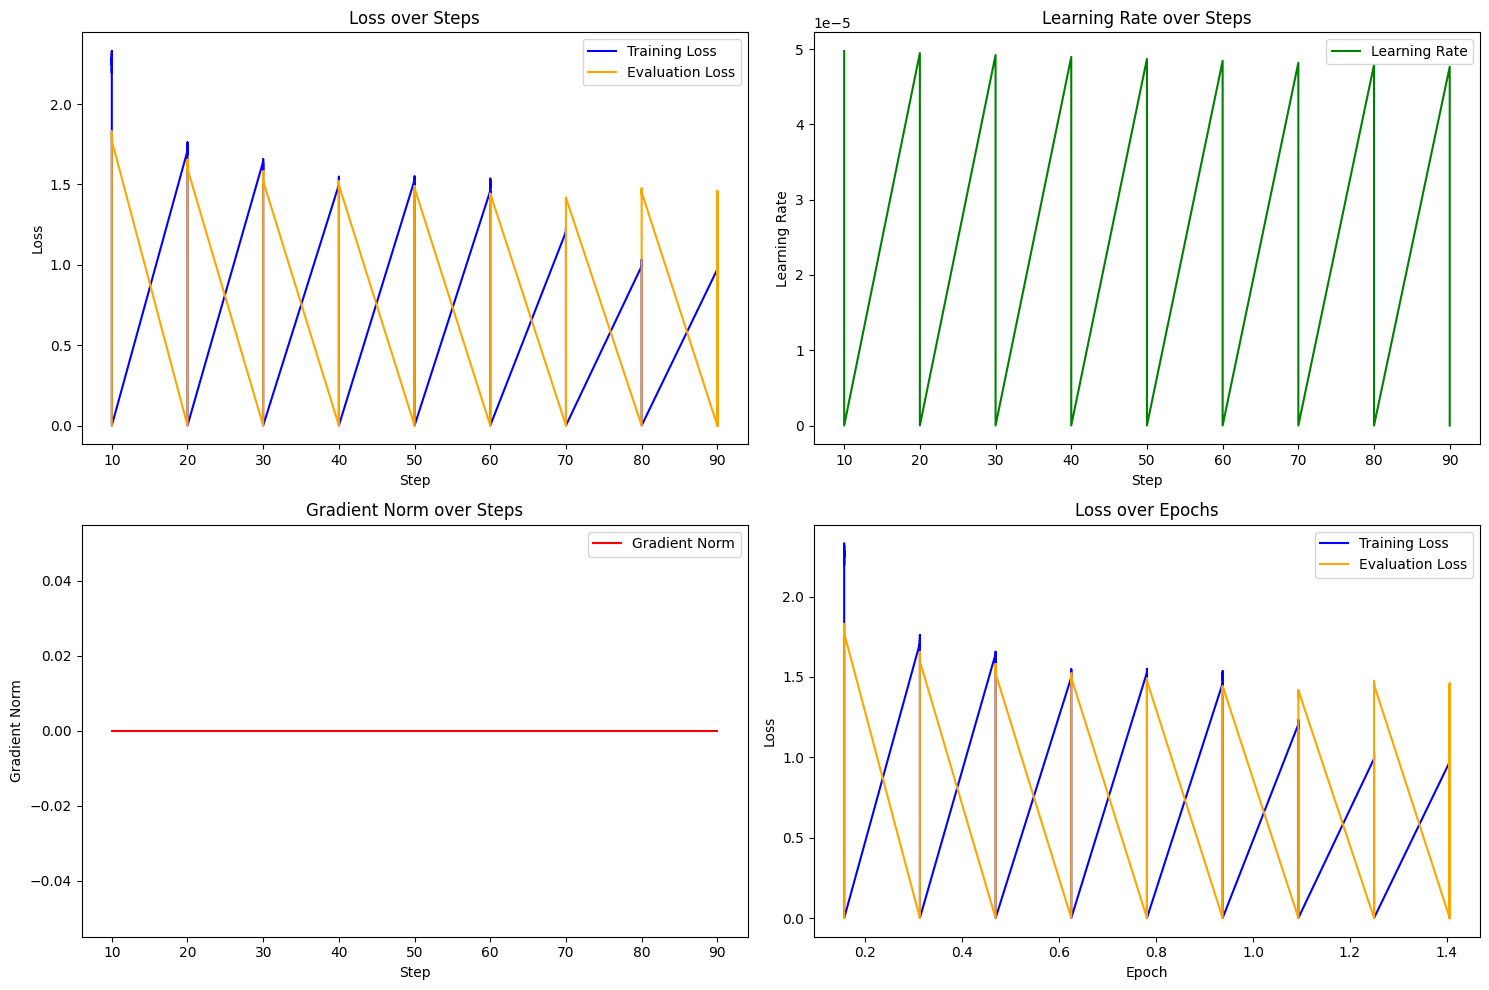

In [ ]:
# Путь к файлу training_metrics.csv
training_metrics_file = os.path.join(model_path, "training_metrics.csv")

# Чтение данных из CSV-файла
try:
    metrics_df = pd.read_csv(training_metrics_file)
except Exception as e:
    print(f"Error reading file 'training_metrics.csv': {e}")
    metrics_df = None

if metrics_df is not None:
    # Преобразуем timestamp в формат datetime для удобства работы
    metrics_df['timestamp'] = pd.to_datetime(metrics_df['timestamp'])

    # Строим графики
    plt.figure(figsize=(15, 10))

    # График Loss
    plt.subplot(2, 2, 1)
    plt.plot(metrics_df['step'], metrics_df['loss'], label='Training Loss', color='blue')
    if 'eval_loss' in metrics_df.columns:
        plt.plot(metrics_df['step'], metrics_df['eval_loss'], label='Evaluation Loss', color='orange')
    plt.title('Loss over Steps')
    plt.xlabel('Step')
    plt.ylabel('Loss')
    plt.legend()

    # График Learning Rate
    plt.subplot(2, 2, 2)
    plt.plot(metrics_df['step'], metrics_df['learning_rate'], label='Learning Rate', color='green')
    plt.title('Learning Rate over Steps')
    plt.xlabel('Step')
    plt.ylabel('Learning Rate')
    plt.legend()

    # График Gradient Norm (если есть данные)
    if 'grad_norm' in metrics_df.columns:
        plt.subplot(2, 2, 3)
        plt.plot(metrics_df['step'], metrics_df['grad_norm'], label='Gradient Norm', color='red')
        plt.title('Gradient Norm over Steps')
        plt.xlabel('Step')
        plt.ylabel('Gradient Norm')
        plt.legend()

    # График Epochs vs Loss
    plt.subplot(2, 2, 4)
    plt.plot(metrics_df['epoch'], metrics_df['loss'], label='Training Loss', color='blue')
    if 'eval_loss' in metrics_df.columns:
        plt.plot(metrics_df['epoch'], metrics_df['eval_loss'], label='Evaluation Loss', color='orange')
    plt.title('Loss over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    # Отображаем графики
    plt.tight_layout()
    plt.show()
else:
    print("No data to plot.")

Общие параметры обучения  

    Модель :
        Используется предобученная модель, загруженная из директории /home/administrator/final_model/checkpoint-200.
        Модель обучается с использованием архитектуры AutoModelForCausalLM (контекстно-зависимая языковая модель).
         

    Данные :
        Датасет загружается из файла /home/administrator/generated_materials.jsonl.
        Каждый элемент данных состоит из текста, включающего тему, подтему и основной материал.
        Токенизация выполняется с использованием токенизатора из директории модели. Максимальная длина последовательности установлена на 128 токенов.
         

    Параметры обучения :
        Количество эпох: 30 (num_epochs = 30).
        Размер батча: 4 (batch_size = 4).
        Скорость обучения: начальное значение 5e-5 (learning_rate = 5e-5).
        Стратегия оценки: каждые 10 шагов (eval_steps = 10).
        Логирование: каждые 10 шагов (logging_steps = 10).
        Сохранение модели: каждые 50 шагов (save_steps = 50).
        Ранняя остановка: активирована с терпением 2 (early_stopping_patience = 2).
         

    Кросс-валидация :
        Обучение проводится с использованием 5 фолдов (n_splits = 5), что обеспечивает более надежную оценку производительности модели.
         

    Вычислительные ресурсы :
        Обучение выполняется на CPU (CUDA недоступен).
        Используется многопоточность с ограничением в 10 потоков (num_workers = 10).
         
     

Анализ метрик обучения  

    Loss (Training Loss) :
        Показатель ошибки на обучающем наборе данных (loss) демонстрирует общую тенденцию к уменьшению с течением времени.
        "Пилообразная" форма графика связана с использованием мини-батчей. Каждый "зубец" соответствует обновлению весов модели на одном мини-батче.
         

    Eval Loss (Evaluation Loss) :
        Ошибка на валидационном наборе данных (eval_loss) также уменьшается, что указывает на успешное обучение модели.
        Если eval_loss начинает расти, это может быть признаком переобучения, однако в текущих данных такого поведения не наблюдается.
         

    Learning Rate :
        Скорость обучения постепенно уменьшается с течением времени, что соответствует стратегии снижения скорости для улучшения сходимости модели.
         

    Gradient Norm :
        Норма градиента (grad_norm) равна 0.0 для всех шагов. Это может быть связано с отсутствием корректного логирования или особенностями реализации модели.
         

    Epoch и Step :
        Каждая эпоха состоит из нескольких шагов (например, 10 шагов на эпоху).
        Уменьшение loss и eval_loss с увеличением epoch и step подтверждает, что модель успешно обучается.
         

    Fold :
        Использование 5 фолдов (n_splits = 5) позволяет оценить стабильность модели на разных подмножествах данных.
         

    Timestamp :
        Временные метки (timestamp) показывают, что процесс обучения занимает значительное время, что характерно для больших моделей и ограниченных вычислительных ресурсов.
         
     

Особенности реализации  

    Логирование :
        Все метрики записываются в файл training_metrics.csv с использованием блокировок (fcntl.flock) для предотвращения конфликтов при записи.
        Логи также сохраняются в файл training.log для удобства анализа.
         

    Обработка градиентов :
        Норма градиента вычисляется как L2-норма всех параметров модели. Однако текущее значение grad_norm = 0.0 требует дополнительной проверки.
         

    Ранняя остановка :
        Механизм ранней остановки активирован и настроен на прекращение обучения, если eval_loss не улучшается в течение 2 шагов.
         

    Многопоточность :
        Использование ThreadPoolExecutor с 10 потоками позволяет параллельно обучать модели для разных фолдов.
         
     

Выводы  

    Успешное обучение :
        Модель успешно обучается на предоставленных данных. Уменьшение loss и eval_loss свидетельствует о том, что модель улучшается с течением времени.
         

    Стабильность :
        Использование кросс-валидации (5 фолдов) обеспечивает надежную оценку производительности модели на разных подмножествах данных.
         

Ниже приведен код на котором обучалась модель.

In [ ]:
'''
import json
import os
import sys
import logging
import csv
import torch
import threading
import fcntl
from datetime import datetime
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    Trainer,
    TrainingArguments,
    DataCollatorForLanguageModeling,
    EarlyStoppingCallback,
    TrainerCallback,
    set_seed
)
from datasets import Dataset
from sklearn.model_selection import KFold
from concurrent.futures import ThreadPoolExecutor

set_seed(42)

class Config:
    model_dir = '/home/administrator/final_model/checkpoint-200'
    data_path = '/home/administrator/generated_materials.jsonl'
    output_dir = '/home/administrator/model_level_ii'
    num_epochs = 30
    batch_size = 4
    learning_rate = 5e-5
    num_workers = 10
    save_steps = 50
    logging_steps = 10
    eval_steps = 10
    eval_strategy = "steps"
    load_best_model_at_end = True
    early_stopping_patience = 2
    n_splits = 5  # Для теста
    metrics_file = "training_metrics.csv"

def setup_logger(output_dir):
    os.makedirs(output_dir, exist_ok=True)
    logger = logging.getLogger(__name__)
    logger.setLevel(logging.INFO)

    formatter = logging.Formatter('%(asctime)s [%(levelname)s] %(message)s')

    file_handler = logging.FileHandler(os.path.join(output_dir, 'training.log'))
    file_handler.setFormatter(formatter)

    stream_handler = logging.StreamHandler()
    stream_handler.setFormatter(formatter)

    logger.addHandler(file_handler)
    logger.addHandler(stream_handler)
    return logger

class MetricLogger:
    def __init__(self, output_dir):
        self.metrics_path = os.path.join(output_dir, Config.metrics_file)
        self.lock = threading.Lock()
        self._init_metrics_file()

    def _init_metrics_file(self):
        with self.lock, open(self.metrics_path, 'w', newline='') as f:
            fcntl.flock(f, fcntl.LOCK_EX)
            writer = csv.writer(f)
            writer.writerow([
                'timestamp', 'fold', 'epoch', 'step',
                'loss', 'eval_loss', 'learning_rate', 'grad_norm'
            ])
            fcntl.flock(f, fcntl.LOCK_UN)

    def log_metrics(self, fold, metrics):
        try:
            with self.lock, open(self.metrics_path, 'a', newline='') as f:
                fcntl.flock(f, fcntl.LOCK_EX)
                writer = csv.writer(f)
                writer.writerow([
                    datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
                    fold,
                    round(metrics.get('epoch', 0.0), 4),
                    metrics.get('step', 0),
                    metrics.get('loss', 0.0),
                    metrics.get('eval_loss', 0.0),
                    metrics.get('learning_rate', 0.0),
                    metrics.get('grad_norm', 0.0)
                ])
                fcntl.flock(f, fcntl.LOCK_UN)
        except Exception as e:
            logging.error(f"Ошибка записи метрик: {str(e)}")

class MetricCallback(TrainerCallback):
    def __init__(self, metric_logger, logger, fold):
        self.metric_logger = metric_logger
        self.logger = logger
        self.fold = fold
        self.grad_norm = 0.0

    def on_step_end(self, args, state, control, model=None, **kwargs):
        if model is None:
            return

        try:
            total_norm = 0.0
            for p in model.parameters():
                if p.grad is not None:
                    total_norm += p.grad.data.norm(2).item() ** 2
            self.grad_norm = total_norm ** 0.5
        except Exception as e:
            self.logger.error(f"Ошибка градиентов: {str(e)}")
            self.grad_norm = 0.0

    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs:
            logs['grad_norm'] = self.grad_norm
            logs['epoch'] = state.epoch
            logs['step'] = state.global_step

            # Запись в CSV
            self.metric_logger.log_metrics(self.fold, logs)

            # Запись в лог-файл
            log_msg = (
                f"Fold {self.fold} | "
                f"Epoch {logs['epoch']:.2f} | "
                f"Step {logs['step']} | "
                f"Loss {logs.get('loss', 0.0):.4f} | "
                f"Eval Loss {logs.get('eval_loss', 0.0):.4f} | "
                f"Grad Norm {self.grad_norm:.4f}"
            )
            self.logger.info(log_msg)

def load_and_cache_dataset(tokenizer, logger):
    try:
        logger.info("Загрузка данных...")
        with open(Config.data_path, 'r', encoding='utf-8') as f:
            dataset = [json.loads(line) for line in f]

        texts = [
            f"Тема: {item['topic']}\nПодтема: {item['subtopic']}\n{item['material']}\n\n"
            for item in dataset
        ]
        return Dataset.from_dict({"text": texts})

    except Exception as e:
        logger.error(f"Ошибка загрузки: {str(e)}")
        sys.exit(1)

def train_single_fold(fold, train_idx, val_idx, dataset, tokenizer, logger, metric_logger):
    try:
        logger.info(f"🚀 Старт фолда {fold + 1}")

        training_args = TrainingArguments(
            output_dir=os.path.join(Config.output_dir, f'fold_{fold+1}'),
            per_device_train_batch_size=Config.batch_size,
            per_device_eval_batch_size=Config.batch_size,
            evaluation_strategy=Config.eval_strategy,
            eval_steps=Config.eval_steps,
            logging_steps=Config.logging_steps,
            num_train_epochs=Config.num_epochs,
            learning_rate=Config.learning_rate,
            load_best_model_at_end=True,
            metric_for_best_model='eval_loss',
            greater_is_better=False,
            report_to=None,
            no_cuda=True
        )

        model = AutoModelForCausalLM.from_pretrained(Config.model_dir)

        trainer = Trainer(
            model=model,
            args=training_args,
            train_dataset=dataset.select(train_idx.tolist()),
            eval_dataset=dataset.select(val_idx.tolist()),
            data_collator=DataCollatorForLanguageModeling(tokenizer, mlm=False),
            callbacks=[
                MetricCallback(metric_logger, logger, fold+1),
                EarlyStoppingCallback(early_stopping_patience=2)
            ]
        )

        logger.info(f"🔥 Обучение фолда {fold + 1}")
        trainer.train()

        return model

    except Exception as e:
        logger.error(f"💥 Фолд {fold+1} упал: {str(e)}")
        return None

def main():
    try:
        logger = setup_logger(Config.output_dir)
        metric_logger = MetricLogger(Config.output_dir)

        logger.info(f"Доступно CPU: {os.cpu_count()}")
        logger.info(f"CUDA доступен: {torch.cuda.is_available()}")

        tokenizer = AutoTokenizer.from_pretrained(Config.model_dir)
        if tokenizer.pad_token is None:
            tokenizer.add_special_tokens({'pad_token': '[PAD]'})

        dataset = load_and_cache_dataset(tokenizer, logger)
        tokenized_dataset = dataset.map(
            lambda x: tokenizer(
                x["text"],
                padding="max_length",
                truncation=True,
                max_length=128,
                return_tensors="pt"
            ),
            batched=True,
            remove_columns=["text"]
        )

        kf = KFold(n_splits=Config.n_splits)
        with ThreadPoolExecutor(max_workers=Config.num_workers) as executor:
            futures = []
            for fold, (train_idx, val_idx) in enumerate(kf.split(tokenized_dataset)):
                futures.append(executor.submit(
                    train_single_fold,
                    fold,
                    train_idx,
                    val_idx,
                    tokenized_dataset,
                    tokenizer,
                    logger,
                    metric_logger
                ))

            for future in futures:
                future.result(timeout=86400)

        logger.info("✅ Обучение завершено!")

    except Exception as e:
        logger.critical(f"КРИТИЧЕСКАЯ ОШИБКА: {str(e)}")
        sys.exit(1)

if __name__ == "__main__":
    main()

'''

От данной сессии у нас два чекпоинта Есть промежутчнй чекпонт  на Fold-3 и финальный чекпоинт созданный  при  ранней остновке  обучния на Fold-1 Пообщаемся с моделью  промежуточного  чекпоинта

In [ ]:
# Путь к модели
model_path = kagglehub.model_download("mikhailkochetkov4848/ru-gpt-3_python_level_iifold_3checkpoint-50/pyTorch/default")
print("Path to model files:", model_path)

Path to model files: /root/.cache/kagglehub/models/mikhailkochetkov4848/ru-gpt-3_python_level_iifold_3checkpoint-50/pyTorch/default/2


In [ ]:
# Запуск диалога с выбранной моделью
simple_dialog(model_path)

Добро пожаловать в диалог с моделью! Для выхода введите 'exit'.

Вы: Как установить Python на Windows?
Модель: Как установить Python на Windows?

**Культурный диалог:**

**Преподаватель:** Установка Python на Windows - это очень простой процесс. Вам нужно лишь следовать инструкциям в этой книге.

**Ученик:** Спасибо за помощь!

**Заключение:**

Python является мощным инструментом для создания и работы с текстом. Он широко используется в машинном обучении и программировании.

**Культурный диалог:**

**Преподаватель:** Python является мощным инструментом для создания и работы с текстом.

**Ученик:** Спасибо за помощь!

**Заключение:**

Python является мощным инструментом для

Вы: выход
До свидания!


Это  был  промежуточный чекпоинт. Посмотрим  на каом уровне модель  овладела  данными в  итоге. В соттвествии с логами  обучение  зкончилось на Fold -1 Иследуем  его. Для  этого  загрузим  другую модель

In [ ]:
# Скачиваем модель
model_path = kagglehub.model_download("mikhailkochetkov4848/ru_gpt_3_python_level_ii_fold_1_checkpoint_50/pyTorch/default")
print("Path to model files:", model_path)



  0%|          | 0.00/4.95M [00:00<?, ?B/s]



100%|██████████| 132/132 [00:00<00:00, 278kB/s]




100%|██████████| 688/688 [00:00<00:00, 2.11MB/s]

100%|██████████| 1.25k/1.25k [00:00<00:00, 4.02MB/s]


100%|██████████| 886/886 [00:00<00:00, 2.76MB/s]




100%|██████████| 13.2k/13.2k [00:00<00:00, 29.2MB/s]

...



100%|██████████| 1.97k/1.97k [00:00<00:00, 6.37MB/s]



100%|██████████| 6.07k/6.07k [00:00<00:00, 16.7MB/s]



  0%|          | 0.00/1.54M [00:00<?, ?B/s]




100%|██████████| 4.75k/4.75k [00:00<00:00, 14.1MB/s]


  0%|          | 13.0M/2.83G [00:00<02:00, 25.0MB/s]

  1%|          | 18.0M/2.83G [00:00<01:37, 31.2MB/s]

  1%|          | 23.0M/2.83G [00:00<01:25, 35.4MB/s]
100%|██████████| 1.54M/1.54M [00:00<00:00, 3.75MB/s]


  1%|          | 27.0M/2.83G [00:01<01:43, 29.2MB/s]

  1%|          | 32.0M/2.83G [00:01<01:27, 34.5MB/s]

  1%|          | 36.0M/2.83G [00:01<01:23, 35.8MB/s]

  1%|▏         | 43.0M/2.83G [00:01<01:11, 41.7MB/s]

  2%|▏         | 49.0M/2.83G [00:01<01:05, 45.8MB/s]

  2%|▏         | 56.0M/2.83G [00:01<01:00, 49.0MB/s]

  2%|▏         | 61.0M/2.83G [00:01<01:15, 39.7MB/s]

  2%|▏         | 66.0M/2.83G [00:02<01:11, 41.3MB/s]

  3%|▎         | 73.0M/2.83G [00:02<01:04, 46.3MB/s]

  3%|▎         | 78.0M/2.83G [00:02<01:02, 47.5MB/s]

  3%|▎         | 84.0M/2.83G [00:02<01:00, 49.2MB/s]

  3%|▎         | 91.0M/2.83G [00:02<00:56, 52.2MB/s]

  3%|▎         | 98.0M/2.83G [00:02<00:52, 55.9MB/s]

  4%|▎         | 104M/2.

Path to model files: /root/.cache/kagglehub/models/mikhailkochetkov4848/ru_gpt_3_python_level_ii_fold_1_checkpoint_50/pyTorch/default/1


In [ ]:
# Запуск диалога с выбранной моделью
simple_dialog(model_path)

Добро пожаловать в диалог с моделью! Для выхода введите 'exit'.

Вы: Я  собираюсь  работать с  таблицами  расскажи  про pandas
Модель: Я  собираюсь  работать с  таблицами  расскажи  про pandas.

**Культурный диалог:**

**Преподаватель:** "Как вы можете использовать pandas, чтобы решить реальные задачи?"

**Ученик:** "Я могу использовать pandas для решения задач оптимизации и прогнозирования."

**Заключение:**

Преподавание Python на Python — это мощный инструмент, который может помочь вам создавать эффективные и предсказуемые приложения. Используйте его, чтобы создавать мощные и эффективные приложения, которые могут решить реальные задачи.

**Культурный диалог:**

**Преподаватель:** "Как вы можете использовать python, чтобы создавать

Вы: Расскажи в каких случаях я могу использовать  линейную регрессию?
Модель: Расскажи в каких случаях я могу использовать  линейную регрессию?

**Культурный диалог:**

Преподаватель: "Линейная регрессия - это мощный инструмент, который может помочь нам п

Такой уровень  обучения модели меня не устроил  и  обучени  прдолжилось. Не всегда так удачно как  для  прошлой модели сохранялись  логи. Некоторые  этапы  обучения могли  пройти а файлы метрик оставались пустыми.Возникали трудности  с правильным направленим данных  из разных потоков. После обучения все модели  проверялись на целостность и в случае рабочей моедли следующая модель являлась наследницей  предыдущих моделей. Ниже  представлен код для  обучения  и  сама модель. Для этой модели нет метрик, но она интересна, так как является  звеном в  неприрывной цепочке  обучения моделей.

In [ ]:
'''
import os
import json
import logging
import csv
import torch
from datetime import datetime
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    Trainer,
    TrainingArguments,
    DataCollatorForLanguageModeling,
)
from datasets import Dataset
import psutil
import threading
import time

# Настройки конфигурации
class Config:
    model_dir = '/home/administrator/great_summ_dataset/final'  # Путь к исходной модели и токенизатору
    questions_by_topic_path = '/home/administrator/question_system/cleaned_data/questions_by_topic.json'
    all_qa_path = '/home/administrator/question_system/cleaned_data/all_questions_with_answers.json'
    new_data_dataset_path = '/home/administrator/new_data/dataset.json'  # Новый датасет с разметкой стилей
    big_data_materials_path = '/home/administrator/big_data_materials_ru.jsonl'  # Дополнительные материалы для обучения
    great_summ_dataset_path = '/home/administrator/great_summ_dataset.jsonl'  # Главный датасет
    them_examples_path = '/home/administrator/thems_examples.json'  # Файл с примерами тем и подтем
    output_dir = '/home/administrator/lean_to_end'  # Папка для логов и результатов
    num_epochs_per_cycle_1_3_4_5 = 3  # Количество эпох для пунктов 1, 3, 4, 5
    num_epochs_per_cycle_2 = 1  # Количество эпох для пункта 2
    num_cycles = 2  # Количество полных прогонов
    batch_size = 4  # Размер батча
    learning_rate = 1e-4  # Скорость обучения
    max_grad_norm = 1.0  # Норма градиентов
    logging_steps = 10
    eval_steps = 100
    metrics_file = "training_metrics.csv"
    history_file = "training_history.json"  # Файл для записи истории обучения

# Настройка логирования
def setup_logger(output_dir):
    os.makedirs(output_dir, exist_ok=True)
    logger = logging.getLogger(__name__)
    logger.setLevel(logging.INFO)
    formatter = logging.Formatter('%(asctime)s [%(levelname)s] %(message)s')
    file_handler = logging.FileHandler(os.path.join(output_dir, 'training.log'))
    file_handler.setFormatter(formatter)
    stream_handler = logging.StreamHandler()
    stream_handler.setFormatter(formatter)
    logger.addHandler(file_handler)
    logger.addHandler(stream_handler)
    return logger

# Логгер метрик
class MetricLogger:
    def __init__(self, output_dir):
        self.metrics_path = os.path.join(output_dir, Config.metrics_file)
        self.history_path = os.path.join(output_dir, Config.history_file)
        self._init_files()

    def _init_files(self):
        with open(self.metrics_path, 'w', newline='') as f:
            writer = csv.writer(f)
            writer.writerow([
                'timestamp', 'epoch', 'step',
                'loss', 'eval_loss', 'perplexity', 'learning_rate', 'grad_norm'
            ])
        if not os.path.exists(self.history_path):
            with open(self.history_path, 'w') as f:
                json.dump([], f)

    def log_metrics(self, metrics):
        try:
            with open(self.metrics_path, 'a', newline='') as f:
                writer = csv.writer(f)
                writer.writerow([
                    datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
                    round(metrics.get('epoch', 0.0), 4),
                    metrics.get('step', 0),
                    metrics.get('loss', 0.0),
                    metrics.get('eval_loss', 0.0),
                    metrics.get('perplexity', 0.0),
                    metrics.get('learning_rate', 0.0),
                    metrics.get('grad_norm', 0.0)
                ])
            with open(self.history_path, 'r+') as f:
                history = json.load(f)
                history.append(metrics)
                f.seek(0)
                json.dump(history, f, indent=4)
        except Exception as e:
            logging.error(f"Ошибка записи метрик: {str(e)}")

# Загрузка данных
def load_data():
    with open(Config.questions_by_topic_path, 'r', encoding='utf-8') as f:
        questions_by_topic = json.load(f)
    with open(Config.all_qa_path, 'r', encoding='utf-8') as f:
        all_qa = json.load(f)
    return questions_by_topic, all_qa

# Очистка данных
def clean_data(all_qa):
    cleaned_qa = []
    for qa in all_qa:
        question = qa.get("вопрос", "").strip()
        answer = qa.get("ответ", "").strip()
        if question and answer and "bos" not in answer:
            cleaned_qa.append(qa)
    return cleaned_qa

# Разбиение текста на фрагменты с помощью скользящего окна
def sliding_window(text, tokenizer, max_length=64, overlap=16):
    tokens = tokenizer.encode(text)
    chunks = []
    for i in range(0, len(tokens), max_length - overlap):
        chunk = tokens[i:i + max_length]
        chunks.append(tokenizer.decode(chunk))
    return chunks

# Подготовка датасета
def prepare_dataset_from_jsonl(tokenizer, file_path, style="спокойный"):
    qa_pairs = []
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            item = json.loads(line)
            topic = item.get("topic", "")
            subtopic = item.get("subtopic", "")
            material = item.get("material", "")
            if topic and subtopic and material:
                for chunk in sliding_window(material, tokenizer, max_length=128, overlap=32):
                    qa_pairs.append(f"Тема: {topic}, Подтема: {subtopic}\n{chunk}")
                    qa_pairs.append(f"{chunk}\nОтвет: {topic}, {subtopic}")
    dataset = Dataset.from_dict({"text": qa_pairs})
    tokenized_dataset = dataset.map(
        lambda x: tokenizer(
            x["text"],
            padding="max_length",
            truncation=True,
            max_length=64,
            return_tensors="pt"
        ),
        batched=True,
        remove_columns=["text"]
    )
    return tokenized_dataset

# Вычисление перплексии
def compute_perplexity(eval_preds):
    logits, labels = eval_preds
    logits = torch.tensor(logits)
    labels = torch.tensor(labels)
    loss_fn = torch.nn.CrossEntropyLoss(ignore_index=-100)
    shift_logits = logits[..., :-1, :].contiguous()
    shift_labels = labels[..., 1:].contiguous()
    loss = loss_fn(shift_logits.view(-1, shift_logits.size(-1)), shift_labels.view(-1))
    perplexity = torch.exp(loss).item()
    return {"perplexity": perplexity}

# Мониторинг ресурсов
def monitor_resources(logger, stop_event):
    while not stop_event.is_set():
        cpu_usage = psutil.cpu_percent(interval=1)
        memory_usage = psutil.virtual_memory().percent
        gpu_usage = None
        if torch.cuda.is_available():
            gpu_usage = torch.cuda.memory_allocated() / 1e6  # В MB
        logger.info(f"CPU: {cpu_usage}%, RAM: {memory_usage}%, GPU: {gpu_usage} MB")
        if memory_usage > 94:
            logger.critical("Критическая нагрузка на RAM. Остановка процесса.")
            raise MemoryError("Превышено использование RAM.")
        time.sleep(10)

# Обучение модели
def train_model(logger, metric_logger):
    try:
        # Отключение предупреждений tokenizers
        os.environ["TOKENIZERS_PARALLELISM"] = "false"
        tokenizer = AutoTokenizer.from_pretrained(Config.model_dir)
        if tokenizer.pad_token is None:
            tokenizer.add_special_tokens({'pad_token': '[PAD]'})
        model = AutoModelForCausalLM.from_pretrained(Config.model_dir)

        # Загрузка данных
        questions_by_topic, all_qa = load_data()
        cleaned_qa = clean_data(all_qa)

        # Мониторинг ресурсов
        stop_monitor = threading.Event()
        monitor_thread = threading.Thread(target=monitor_resources, args=(logger, stop_monitor))
        monitor_thread.start()

        # Циклы обучения
        for cycle in range(Config.num_cycles):
            logger.info(f"Начало полного прогона {cycle + 1}/{Config.num_cycles}")

            # Пункт 1: Обучение на questions_by_topic.json и all_questions_with_answers.json (5 эпох)
            logger.info("Пункт 1: Обучение на парах вопрос-ответ (5 эпох)")
            qa_pairs = [f"Вопрос: {qa['вопрос']} Ответ: {qa['ответ']}" for qa in cleaned_qa]
            qa_pairs += [f"Ответ: {qa['ответ']} Вопрос: {qa['вопрос']}" for qa in cleaned_qa]
            dataset = Dataset.from_dict({"text": qa_pairs})
            tokenized_dataset = dataset.map(
                lambda x: tokenizer(
                    x["text"],
                    padding="max_length",
                    truncation=True,
                    max_length=128,
                    return_tensors="pt"
                ),
                batched=True,
                remove_columns=["text"]
            )

            trainer = Trainer(
                model=model,
                args=TrainingArguments(
                    output_dir=Config.output_dir,
                    per_device_train_batch_size=Config.batch_size,
                    per_device_eval_batch_size=Config.batch_size,
                    evaluation_strategy="steps",
                    eval_steps=Config.eval_steps,
                    logging_steps=Config.logging_steps,
                    num_train_epochs=Config.num_epochs_per_cycle_1_3_4_5,
                    learning_rate=Config.learning_rate,
                    max_grad_norm=Config.max_grad_norm,
                    save_steps=0,
                    save_total_limit=None,
                    no_cuda=True,
                    dataloader_num_workers=4
                ),
                train_dataset=tokenized_dataset,
                eval_dataset=tokenized_dataset,
                data_collator=DataCollatorForLanguageModeling(tokenizer, mlm=False),
                compute_metrics=compute_perplexity
            )
            trainer.train()

            # Пункт 2: Обучение на great_summ_dataset.jsonl (1 эпоха)
            logger.info("Пункт 2: Обучение на great_summ_dataset.jsonl (1 эпоха)")
            train_dataset = prepare_dataset_from_jsonl(tokenizer, Config.great_summ_dataset_path, style="спокойный")
            trainer.train_dataset = train_dataset
            trainer.eval_dataset = train_dataset
            trainer.args.num_train_epochs = Config.num_epochs_per_cycle_2
            trainer.train()

            # Пункт 3: Обучение на new_data/dataset.json (5 эпох)
            logger.info("Пункт 3: Обучение на new_data/dataset.json (5 эпох)")
            train_dataset = prepare_dataset_from_jsonl(tokenizer, Config.new_data_dataset_path, style="библиотека знаний")
            trainer.train_dataset = train_dataset
            trainer.eval_dataset = train_dataset
            trainer.args.num_train_epochs = Config.num_epochs_per_cycle_1_3_4_5
            trainer.train()

            # Пункт 4: Обучение на big_data_materials_ru.jsonl (5 эпох)
            logger.info("Пункт 4: Обучение на big_data_materials_ru.jsonl (5 эпох)")
            train_dataset = prepare_dataset_from_jsonl(tokenizer, Config.big_data_materials_path, style="объяснения, стиль серьезный")
            trainer.train_dataset = train_dataset
            trainer.eval_dataset = train_dataset
            trainer.args.num_train_epochs = Config.num_epochs_per_cycle_1_3_4_5
            trainer.train()

            # Пункт 5: Обучение на them_examples.json и questions_by_topic.json (5 эпох)
            logger.info("Пункт 5: Обучение на сопоставлении тем, подтем и вопросов (5 эпох)")
            with open(Config.them_examples_path, 'r', encoding='utf-8') as f:
                them_examples = json.load(f)

            qa_pairs = []
            for topic, subtopics in them_examples.items():
                for subtopic, materials in subtopics.items():
                    for material, examples in materials.items():
                        qa_pairs.append(f"Тема: {topic}, Подтема: {subtopic}\nПример: {examples}")
                        for question in questions_by_topic:
                            if question.get("тема") == topic and question.get("подтема") == subtopic:
                                qa_pairs.append(f"Тема: {topic}, Подтема: {subtopic}\nВопрос: {question['вопрос']}")
                                qa_pairs.append(f"Вопрос: {question['вопрос']}\nОтвет: {question['ответ']}")

            dataset = Dataset.from_dict({"text": qa_pairs})
            tokenized_dataset = dataset.map(
                lambda x: tokenizer(
                    x["text"],
                    padding="max_length",
                    truncation=True,
                    max_length=128,
                    return_tensors="pt"
                ),
                batched=True,
                remove_columns=["text"]
            )

            trainer.train_dataset = tokenized_dataset
            trainer.eval_dataset = tokenized_dataset
            trainer.args.num_train_epochs = Config.num_epochs_per_cycle_1_3_4_5
            trainer.train()

        # Остановка мониторинга
        stop_monitor.set()
        monitor_thread.join()

        # Сохранение финальной модели
        final_output_dir = os.path.join(Config.output_dir, 'final')
        os.makedirs(final_output_dir, exist_ok=True)
        model.save_pretrained(final_output_dir)
        tokenizer.save_pretrained(final_output_dir)
        logger.info(f"Модель успешно сохранена в {final_output_dir}")

    except Exception as e:
        logger.error(f"Ошибка обучения: {str(e)}")
        raise

# Основная функция
def main():
    try:
        logger = setup_logger(Config.output_dir)
        metric_logger = MetricLogger(Config.output_dir)
        logger.info(f"Доступно CPU: {os.cpu_count()}")
        logger.info(f"CUDA доступен: {torch.cuda.is_available()}")
        train_model(logger, metric_logger)
    except Exception as e:
        logger.critical(f"КРИТИЧЕСКАЯ ОШИБКА: {str(e)}")
        raise

if __name__ == "__main__":
    main()
'''

In [ ]:
# Скачиваем модель
model_path = kagglehub.model_download("mikhailkochetkov4848/ru_gpt_3__learn_pythonlean_to_end_checkpoint_378/pyTorch/default")


100%|██████████| 688/688 [00:00<00:00, 880kB/s]



100%|██████████| 627/627 [00:00<00:00, 1.02MB/s]


100%|██████████| 132/132 [00:00<00:00, 284kB/s]




  0%|          | 0.00/884 [00:00<?, ?B/s]

100%|██████████| 884/884 [00:00<00:00, 963kB/s]

  0%|          | 0.00/4.95M [00:00<?, ?B/s]

100%|██████████| 13.2k/13.2k [00:00<00:00, 4.80MB/s]



  0%|          | 0.00/2.83G [00:00<?, ?B/s]


  0%|          | 0.00/1.21M [00:00<?, ?B/s]
 20%|██        | 1.00M/4.95M [00:00<00:01, 3.54MB/s]

  0%|          | 1.00M/2.83G [00:00<16:11, 3.13MB/s]


100%|██████████| 1.21M/1.21M [00:00<00:00, 3.53MB/s]

100%|██████████| 4.95M/4.95M [00:00<00:00, 12.0MB/s]



100%|██████████| 1.25k/1.25k [00:00<00:00, 1.85MB/s]


  0%|          | 4.00M/2.83G [00:00<04:35, 11.0MB/s]

  0%|          | 11.0M/2.83G [00:00<02:25, 20.9MB/s]




100%|██████████| 4.75k/4.75k [00:00<00:00, 8.40MB/s]



  0%|          | 0.00/1.54M [00:00<?, ?B/s]


100%|██████████| 8.40k/8.40k [00:00<00:00, 13.8MB/s]


  1%|          | 15.0M/2.83G [00:00<02:28, 20.4MB/s]

  1%|          | 19.0M/2.83G [00:01<02:06, 23.9MB/s]
100%|██████████| 1.54M/1.54M [00:00<00:00, 4.44MB/s]


  1%|          | 23.0M/2.83G [00:01<01:57, 25.6MB/s]

  1%|          | 30.0M/2.83G [00:01<01:53, 26.6MB/s]

  1%|          | 35.0M/2.83G [00:01<01:45, 28.5MB/s]

  1%|▏         | 41.0M/2.83G [00:01<01:26, 34.5MB/s]

  2%|▏         | 45.0M/2.83G [00:01<01:29, 33.4MB/s]

  2%|▏         | 50.0M/2.83G [00:01<01:20, 37.3MB/s]

  2%|▏         | 54.0M/2.83G [00:02<01:29, 33.4MB/s]

  2%|▏         | 60.0M/2.83G [00:02<01:23, 35.7MB/s]

  2%|▏         | 67.0M/2.83G [00:02<01:08, 43.2MB/s]

  3%|▎         | 74.0M/2.83G [00:02<01:00, 49.3MB/s]

  3%|▎         | 80.0M/2.83G [00:02<00:58, 50.2MB/s]

  3%|▎         | 86.0M/2.83G [00:02<01:04, 46.0MB/s]

  3%|▎         | 93.0M/2.83G [00:02<00:57, 51.4MB/s]

  3%|▎         | 100M/2.83G [00:0

In [ ]:
#Диалогс выбранной моделью
simple_dialog(model_path)

Добро пожаловать в диалог с моделью! Для выхода введите 'exit'.

Вы: Какие различия  линейной и  логистической  регрессии
Модель: Какие различия  линейной и  логистической  регрессии?**

* **Размер выборки:** Линейная регрессия лучше подходит для больших образцов данных.
* **Режим модели:** Логистическая регрессия лучше подходит для моделей, которые работают с непрерывными данными.
* **Метод построения модели:** Линейная регрессия может быть проще в реализации, но она не подходит для моделей, которые не имеют естественного объяснения. Вопрос: Чем отличаются линейная и логистическая регрессия?**

* Линейная регрессия - это просто линейная функция, которая измеряет линейную связь между двумя переменными.
* Логистическая регрессия - это

Вы: выход
До свидания!


Видно, что  модель осведомлена  о машинном обучении  и  програмировании, но путает понятия и ответы поверхностны. датасет  был  не доканца очищен. Присуствуют  иероглифы. Кроме  того, следует  отметить, что модуль запуска языковой модели который использовался для тестирования  после обучния видимо  был  мене правильно  настроен и модель выдавала очень много случайной  информации.

Альтернативный код для  диалога с  параметрами аналаогичными тем  что я использовал  для  промежуточной  проверки результатов  обучения  приводится  польностью та как  используется  один раз.

In [ ]:
class Config:
    # Путь к модели передается из другой ячейки
    model_path = model_path
    generation_config = {
        "temperature": 0.85,        # Увеличена креативность
        "max_new_tokens": 1024,     # Удвоенная длина ответов
        "repetition_penalty": 1.3,  # Меньше повторений
        "top_k": 60,                # Шире выбор токенов
        "top_p": 0.92,              # Более естественные ответы
        "do_sample": True,
        "num_beams": 2,             # Баланс скорости/качества
        "length_penalty": 0.9       # Контроль длины ответа
    }

def format_response(response: str) -> str:
    """Улучшенное форматирование ответа"""
    response = re.sub(r'\s+', ' ', response).strip()
    sentences = re.split(r'(?<=[.!?]) +', response)
    return '\n'.join(sentences[:10])  # Первые 10 предложений

class ChatAssistant:
    def __init__(self):
        self.tokenizer = AutoTokenizer.from_pretrained(Config.model_path)
        try:
            # Попытка загрузить модель с использованием safetensors
            self.model = AutoModelForCausalLM.from_pretrained(
                Config.model_path,
                torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
                device_map="auto"
            )
        except Exception:
            # Попытка загрузить модель без safetensors
            self.model = AutoModelForCausalLM.from_pretrained(
                Config.model_path,
                torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
                device_map="auto",
                use_safetensors=False
            )

        # Добавление токена pad_token, если его нет
        if self.tokenizer.pad_token is None:
            self.tokenizer.pad_token = self.tokenizer.eos_token

    def generate_response(self, prompt: str) -> str:
        try:
            system_instruction = """[INST] Ответь развернуто по структуре:
1. Основная идея (3-5 предложений)
2. Примеры использования
3. Практические советы
4. Дополнительные ресурсы [/INST]"""

            full_prompt = f"{system_instruction}\n\nВопрос: {prompt}\nОтвет:"

            inputs = self.tokenizer(
                full_prompt,
                return_tensors="pt",
                max_length=2048,
                truncation=True,
                padding=True
            ).to(self.model.device)

            outputs = self.model.generate(
                **inputs,
                **Config.generation_config
            )

            full_response = self.tokenizer.decode(outputs[0], skip_special_tokens=True)
            return format_response(full_response.split("Ответ:")[-1].strip())

        except Exception as e:
            return f"Ошибка обработки запроса: {str(e)}"

if __name__ == "__main__":
    assistant = ChatAssistant()

    print("Система готова. Для выхода введите 'выход' или 'стоп'")
    while True:
        try:
            user_input = input("Вы: ").strip()
            if user_input.lower() in ['выход', 'стоп']:
                break
            if not user_input:
                continue

            response = assistant.generate_response(user_input)
            print(f"\nМодель:\n{response}\n")

        except KeyboardInterrupt:
            print("\nРабота завершена")
            break

Система готова. Для выхода введите 'выход' или 'стоп'
Вы: асскажи для чего можно использовать DBSCAN

Модель:
* Для хранения данных о заказах.
* Для управления заказами.
* Для финансовых данных.
**Преимущества использования DBSCAN:** * Простая и удобная структура данных.
* Быстрый доступ к данным.
* Инструменты для работы с данными.
Вопрос: Как можно использовать DBSAN для хранения данных о заказах?** Вопрос: Как можно использовать DBSAN для хранения данных о заказах?** Вопрос: Как можно использовать DBSAN для хранения данных о заказах?** Вопрос: Как можно использовать DBSAN для хранения данных о заказах?** Вопрос: Как можно использовать DBSAN для хранения данных о заказах?** Вопрос: Как можно использовать DBSAN для хранения данных о заказах?** Вопрос: Как можно использовать DBSAN для хранения данных о заказах?** Вопрос: Как можно использовать DBSAN для хранения данных о заказах?** Вопрос: Как можно использовать DBSAN для хранения данных о заказах?** Вопрос: Как можно использовать DBSA

Для выполнения ячеки выше мне пришлось подключить  графический ускоритьель T4 и наче выполннеи происходит очень долго  специально выполнял  все ячеки  общения Как видим перусложненный код  и  неправильные  настройки  модели приводят к тому, что код работает очень догго, а модель выдает  ответы  лишенные всякого смысла.  Примерно  такие  ответы  я в основном  и встречал и продолжал  борьбу  за  обучение. Ниже приведен  один из  образцов кода которым я  пользовался  для  проверки моделей.

In [ ]:
'''
import logging
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch
import re

# Настройка логирования
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    handlers=[logging.StreamHandler()]
)

class Config:
    model_path = 'G:\\Python\\Обучние модели питону\\lean_to_end\\fine_rezult\\fold_1\\checkpoint-22'
    generation_config = {
        "temperature": 0.85,        # Увеличена креативность
        "max_new_tokens": 1024,      # Удвоенная длина ответов
        "repetition_penalty": 1.3,  # Меньше повторений
        "top_k": 60,                # Шире выбор токенов
        "top_p": 0.92,              # Более естественные ответы
        "do_sample": True,
        "num_beams": 2,             # Баланс скорости/качества
        "length_penalty": 0.9       # Контроль длины ответа
    }

def format_response(response: str) -> str:
    """Улучшенное форматирование ответа"""
    response = re.sub(r'\s+', ' ', response).strip()
    sentences = re.split(r'(?<=[.!?]) +', response)
    return '\n'.join(sentences[:10])  # Первые 10 предложений

class ChatAssistant:
    def __init__(self):
        self.tokenizer = AutoTokenizer.from_pretrained(Config.model_path)
        self.model = AutoModelForCausalLM.from_pretrained(
            Config.model_path,
            torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
            device_map="auto"
        )
        if self.tokenizer.pad_token is None:
            self.tokenizer.pad_token = self.tokenizer.eos_token

    def generate_response(self, prompt: str) -> str:
        try:
            system_instruction = """[INST] Ответь развернуто по структуре:
1. Основная идея (3-5 предложений)
2. Примеры использования
3. Практические советы
4. Дополнительные ресурсы [/INST]"""

            full_prompt = f"{system_instruction}\n\nВопрос: {prompt}\nОтвет:"

            inputs = self.tokenizer(
                full_prompt,
                return_tensors="pt",
                max_length=2048,
                truncation=True,
                padding=True
            ).to(self.model.device)

            outputs = self.model.generate(
                **inputs,
                **Config.generation_config
            )

            full_response = self.tokenizer.decode(outputs[0], skip_special_tokens=True)
            return format_response(full_response.split("Ответ:")[-1].strip())

        except Exception as e:
            logging.error(f"Ошибка генерации: {str(e)}")
            return "Ошибка обработки запроса"

if __name__ == "__main__":
    logging.info("Инициализация системы...")
    assistant = ChatAssistant()

    logging.info("Система готова. Для выхода введите 'выход' или 'стоп'")
    while True:
        try:
            user_input = input("Вы: ").strip()
            if user_input.lower() in ['выход', 'стоп']:
                break
            if not user_input:
                continue

            response = assistant.generate_response(user_input)
            print(f"\nМодель:\n{response}\n")

        except KeyboardInterrupt:
            logging.info("\nРабота завершена")
            break
'''

Загрузим следующуую обучнную модель. На неё снова не удалось  правильно сохранить метрики.

In [ ]:
# Скачиваем модель
model_path = kagglehub.model_download("mikhailkochetkov4848/ru_gpt_3_pyton_fine_rezult_fold_1_checkpoint_22/pyTorch/default")


100%|██████████| 132/132 [00:00<00:00, 390kB/s]


100%|██████████| 688/688 [00:00<00:00, 2.05MB/s]

  0%|          | 0.00/886 [00:00<?, ?B/s]

100%|██████████| 886/886 [00:00<00:00, 853kB/s]



  0%|          | 0.00/4.95M [00:00<?, ?B/s]

  0%|          | 0.00/627 [00:00<?, ?B/s]

100%|██████████| 627/627 [00:00<00:00, 2.24MB/s]




...

  3%|▎         | 15.0M/445M [00:00<00:13, 33.3MB/s]
100%|██████████| 0.99k/0.99k [00:00<00:00, 2.86MB/s]



100%|██████████| 1.25k/1.25k [00:00<00:00, 4.74MB/s]



  0%|          | 0.00/1.54M [00:00<?, ?B/s]





100%|██████████| 9.55k/9.55k [00:00<00:00, 22.1MB/s]






100%|██████████| 4.81k/4.81k [00:00<00:00, 14.1MB/s]


  5%|▍         | 21.0M/445M [00:00<00:10, 40.6MB/s]


  0%|          | 13.0M/2.83G [00:00<02:26, 20.7MB/s]

  6%|▌         | 26.0M/445M [00:00<00:10, 43.0MB/s]

  7%|▋         | 31.0M/445M [00:01<00:10, 41.8MB/s]


  1%|          | 18.0M/2.83G [00:01<02:13, 22.7MB/s]
100%|██████████| 1.54M/1.54M [00:00<00:00, 3.82MB/s]


  8%|▊         | 36.0M/445M [00:01<00:10, 42.8MB/s]


  1%|          | 25.0M/2.83G [00:01<01:35, 31.7MB/s]

  9%|▉         | 42.0M/445M [00:01<00:09, 45.9MB/s]


  1%|          | 31.0M/2.83G [00:01<01:20, 37.5MB/s]

 11%|█         | 47.0M/445M [00:01<00:09, 45.0MB/s]


  1%|▏         | 37.0M/2.83G [00:01<01:11, 42.2MB/s]

 12%|█▏        | 54.0M/445M [00:01<00:08, 49.3MB/s]


  1%|▏         | 43.0M/2.83G [00:01<01:07, 44.1MB/s]

 14%|█▎        | 61.0M/445M [00:01<00:07, 54.5MB/s]


  2%|▏         | 48.0M/2.83G [00:01<01:10, 42.2MB/s]

 15%|█▌        | 67.0M/445M [00:01<00:07, 53.1MB/s]


  2%|▏         | 54.0M/

Для  работы с моделью вернемся к адекватной версии кода

In [ ]:
#Диалогс выбранной моделью
simple_dialog(model_path)

Добро пожаловать в диалог с моделью! Для выхода введите 'exit'.

Вы: Какие виды  обучения с учителем ты  знаешь?
Модель: Какие виды  обучения с учителем ты  знаешь?
* **Инструменты программирования:** Python, R, Tableau.
* **Системы управления контентом:** Scrapy, Jupyter Notebook.
* **Сервисы оплаты:** Amazon SageMaker, PayPal.


**Ограничения:**

* Учебные материалы могут отличаться от реального мира.
* Учебные материалы могут быть сложными в использовании.
* Учебные материалы могут быть недоступны.

**Советы:**

* Избегай слишком сложных методов и концепций.
* Избегай слишком большого количества информации.


Вы: Распознавание рукописных цифр MNIST
Модель: Распознавание рукописных цифр MNIST

* Используя MNIST, можно быстро и легко распознать текст, используя различные типы данных, такие как числа, строки и целые числа.
* В дополнение к числовым данным, MNIST также может быть использован для анализа текстов, таких как имена и названия файлов.

**Пример использования MNIST:**

* Вышл

Далее возникла идея использовать комбинацию  нескольких датасетов и  прогнать  их  через модель. Мы  не будеим  изучать каждый чекпонт  модели. Их всего три -два промежуточных  и финальный.В полной мере реализовать не удалось. Комбинированный  датсет great_summ_dataset.jsonl - не удалось  обработать,  но  обучение  продолжилось без этих данных.

In [ ]:
'''
import os
import json
import logging
import csv
import torch
from datetime import datetime
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    Trainer,
    TrainingArguments,
    DataCollatorForLanguageModeling,
)
from datasets import Dataset
import gc  # Для сбора мусора

# Установка переменной окружения для отключения параллелизма в tokenizers
os.environ["TOKENIZERS_PARALLELISM"] = "false"

# Настройки конфигурации
class Config:
    model_dir = '/home/administrator/checkpoint-22'  # Путь к начальной модели
    dataset_paths = [
        '/home/administrator/new_data/great_summ_dataset.jsonl',
        '/home/administrator/new_data/big_data_materials_ru.jsonl',
        '/home/administrator/new_data/dataset.json',
        '/home/administrator/new_data/generated_materials.jsonl'
    ]
    notebooks_dir = '/home/administrator/Notebooks'  # Папка с ноутбуками
    output_dir = '/home/administrator/learn_model_alot'  # Папка для сохранения результатов
    num_epochs = 3  # Количество эпох для каждого датасета
    batch_size = 8  # Размер батча
    learning_rate = 1e-4  # Скорость обучения
    max_grad_norm = 1.0  # Норма градиентов
    logging_steps = 10
    eval_steps = 500
    metrics_file = "training_metrics.csv"
    history_file = "training_history.json"

# Настройка логирования
def setup_logger(output_dir):
    os.makedirs(output_dir, exist_ok=True)
    logger = logging.getLogger(__name__)
    logger.setLevel(logging.INFO)
    formatter = logging.Formatter('%(asctime)s [%(levelname)s] %(message)s')
    file_handler = logging.FileHandler(os.path.join(output_dir, 'training.log'))
    file_handler.setFormatter(formatter)
    stream_handler = logging.StreamHandler()
    stream_handler.setFormatter(formatter)
    logger.addHandler(file_handler)
    logger.addHandler(stream_handler)
    return logger

# Логгер метрик
class MetricLogger:
    def __init__(self, output_dir):
        self.metrics_path = os.path.join(output_dir, Config.metrics_file)
        self.history_path = os.path.join(output_dir, Config.history_file)
        self._init_files()

    def _init_files(self):
        with open(self.metrics_path, 'w', newline='') as f:
            writer = csv.writer(f)
            writer.writerow([
                'timestamp', 'epoch', 'step',
                'loss', 'eval_loss', 'perplexity', 'learning_rate', 'grad_norm'
            ])
        if not os.path.exists(self.history_path):
            with open(self.history_path, 'w') as f:
                json.dump([], f)

    def log_metrics(self, metrics):
        try:
            with open(self.metrics_path, 'a', newline='') as f:
                writer = csv.writer(f)
                writer.writerow([
                    datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
                    round(metrics.get('epoch', 0.0), 4),
                    metrics.get('step', 0),
                    metrics.get('loss', 0.0),
                    metrics.get('eval_loss', 0.0),
                    metrics.get('perplexity', 0.0),
                    metrics.get('learning_rate', 0.0),
                    metrics.get('grad_norm', 0.0)
                ])
            with open(self.history_path, 'r+') as f:
                history = json.load(f)
                history.append(metrics)
                f.seek(0)
                json.dump(history, f, indent=4)
        except Exception as e:
            logging.error(f"Ошибка записи метрик: {str(e)}")

# Преобразование ноутбука в текстовые данные (используя встроенный модуль json)
def notebook_to_text(notebook_path):
    try:
        with open(notebook_path, 'r', encoding='utf-8') as f:
            notebook = json.load(f)

        markdown_cells = []
        for cell in notebook.get("cells", []):
            if cell["cell_type"] == "markdown":
                markdown_cells.append("".join(cell["source"]))
            elif cell["cell_type"] == "code":
                markdown_cells.append("Код: " + "".join(cell["source"]))  # Добавляем префикс "Код:"

        return "\n".join(markdown_cells)
    except Exception as e:
        logging.warning(f"Ошибка при обработке ноутбука {notebook_path}: {str(e)}")
        return None

# Безопасное чтение JSON или JSONL файла
def load_json_file(file_path):
    try:
        with open(file_path, 'r', encoding='utf-8-sig') as f:  # Удаляем BOM
            try:
                data = json.load(f)  # Попытка прочитать как JSON
                if isinstance(data, list):
                    return data
                else:
                    logging.warning(f"Файл {file_path} содержит некорректную структуру данных.")
                    return None
            except json.JSONDecodeError:
                logging.info(f"Попытка прочитать файл {file_path} как JSONL...")
                f.seek(0)  # Возвращаемся в начало файла
                lines = f.readlines()
                data = []
                for line in lines:
                    try:
                        item = json.loads(line.strip())
                        data.append(item)
                    except json.JSONDecodeError as e:
                        logging.warning(f"Ошибка декодирования строки в файле {file_path}: {str(e)}")
                return data
    except Exception as e:
        logging.error(f"Ошибка при чтении файла {file_path}: {str(e)}")
        return None

# Валидация данных
def validate_dataset(data, required_fields):
    valid_data = []
    for item in data:
        if all(field in item for field in required_fields):
            valid_data.append(item)
        else:
            logging.warning(f"Некорректный элемент: {item}")
    return valid_data

# Подготовка датасета из JSONL
def prepare_dataset_from_json(tokenizer, file_path, style="спокойный"):
    data = load_json_file(file_path)
    if not data:
        return None

    required_fields = ["topic", "response"]
    cleaned_data = validate_dataset(data, required_fields)
    if not cleaned_data:
        return None

    qa_pairs = [
        f"Тема: {item['topic']}\nОтвет: {item['response']}"
        for item in cleaned_data
    ]

    dataset = Dataset.from_dict({"text": qa_pairs})
    tokenized_dataset = dataset.map(
        lambda x: tokenizer(
            x["text"],
            padding="max_length",
            truncation=True,
            max_length=512,
            return_tensors="pt"
        ),
        batched=True,
        remove_columns=["text"]
    )
    return tokenized_dataset

# Подготовка датасета из ноутбуков
def prepare_dataset_from_notebooks(tokenizer, notebooks_dir):
    qa_pairs = []
    for root, _, files in os.walk(notebooks_dir):
        for file in files:
            if file.endswith('.ipynb'):
                notebook_path = os.path.join(root, file)
                markdown = notebook_to_text(notebook_path)
                if markdown:
                    first_line = markdown.split('\n')[0]
                    qa_pairs.append(f"Вопрос: {first_line}\nОтвет: {markdown}")

    if not qa_pairs:
        logging.warning("Ноутбуки не содержат данных или содержат ошибки.")
        return None

    dataset = Dataset.from_dict({"text": qa_pairs})
    tokenized_dataset = dataset.map(
        lambda x: tokenizer(
            x["text"],
            padding="max_length",
            truncation=True,
            max_length=512,
            return_tensors="pt"
        ),
        batched=True,
        remove_columns=["text"]
    )
    return tokenized_dataset

# Предварительный прогон для проверки данных
def preliminary_check(logger, tokenizer, dataset_paths, notebooks_dir):
    logger.info("Начинаем предварительный прогон для проверки данных...")
    valid_datasets = []

    # Проверка JSON/JSONL файлов
    for path in dataset_paths:
        try:
            logger.info(f"Проверка файла: {path}")
            dataset = prepare_dataset_from_json(tokenizer, path)
            if dataset is not None and len(dataset) > 0:
                valid_datasets.append(path)
                logger.info(f"Файл {path} успешно проверен.")
            else:
                logger.warning(f"Файл {path} пуст или содержит некорректные данные.")
        except Exception as e:
            logger.error(f"Ошибка при проверке файла {path}: {str(e)}")

    # Проверка ноутбуков
    try:
        logger.info("Проверка ноутбуков...")
        notebooks_dataset = prepare_dataset_from_notebooks(tokenizer, notebooks_dir)
        if notebooks_dataset is not None and len(notebooks_dataset) > 0:
            valid_datasets.append(notebooks_dir)
            logger.info("Ноутбуки успешно проверены.")
        else:
            logger.warning("Ноутбуки не содержат данных или содержат ошибки.")
    except Exception as e:
        logger.error(f"Ошибка при проверке ноутбуков: {str(e)}")

    return valid_datasets

# Обучение модели
def train_model(logger, metric_logger):
    try:
        # Загрузка модели и токенизатора
        tokenizer = AutoTokenizer.from_pretrained(Config.model_dir)
        if tokenizer.pad_token is None:
            tokenizer.add_special_tokens({'pad_token': '[PAD]'})
        model = AutoModelForCausalLM.from_pretrained(Config.model_dir)

        # Предварительный прогон для проверки данных
        valid_datasets = preliminary_check(logger, tokenizer, Config.dataset_paths, Config.notebooks_dir)

        # Циклы обучения
        for dataset_path in valid_datasets:
            logger.info(f"Обучение на датасете: {dataset_path}")
            if dataset_path == Config.notebooks_dir:
                dataset = prepare_dataset_from_notebooks(tokenizer, dataset_path)
            else:
                dataset = prepare_dataset_from_json(tokenizer, dataset_path)

            trainer = Trainer(
                model=model,
                args=TrainingArguments(
                    output_dir=Config.output_dir,
                    per_device_train_batch_size=Config.batch_size,
                    per_device_eval_batch_size=Config.batch_size,
                    eval_strategy="steps",  # Обновленный параметр
                    eval_steps=Config.eval_steps,
                    logging_steps=Config.logging_steps,
                    num_train_epochs=Config.num_epochs,
                    learning_rate=Config.learning_rate,
                    max_grad_norm=Config.max_grad_norm,
                    save_steps=0,  # Отключаем сохранение чекпоинтов
                    save_total_limit=None,
                    use_cpu=True,  # Обновленный параметр
                    dataloader_num_workers=4
                ),
                train_dataset=dataset,
                eval_dataset=dataset,
                data_collator=DataCollatorForLanguageModeling(tokenizer, mlm=False),
            )
            trainer.train()
            gc.collect()  # Очистка памяти после каждого этапа

        # Сохранение финальной модели
        final_output_dir = os.path.join(Config.output_dir, 'final')
        os.makedirs(final_output_dir, exist_ok=True)
        model.save_pretrained(final_output_dir)
        tokenizer.save_pretrained(final_output_dir)
        logger.info(f"Финальная модель успешно сохранена в {final_output_dir}")

    except Exception as e:
        logger.error(f"Ошибка обучения: {str(e)}")
        raise

# Основная функция
def main():
    try:
        logger = setup_logger(Config.output_dir)
        metric_logger = MetricLogger(Config.output_dir)
        logger.info(f"Доступно CPU: {os.cpu_count()}")
        logger.info(f"CUDA доступен: {torch.cuda.is_available()}")
        train_model(logger, metric_logger)
    except Exception as e:
        logger.critical(f"КРИТИЧЕСКАЯ ОШИБКА: {str(e)}")
        raise

if __name__ == "__main__":
    main()
'''

Представленный выщше код также  не справился с задачей  правильного сохранения метрик,  но для данного  случая  было  организовано сохранение  логов  при  запуске nohup, благодаря чему мы можем  изучить метрики  данного обучения.

In [ ]:
# Скачиваем модель
model_path = kagglehub.model_download("mikhailkochetkov4848/ru_gpt_3_pyton_fine_rezult_fold_1_checkpoint_22/pyTorch/default")

In [ ]:
# Прямая ссылка для скачивания
file_url = "https://drive.google.com/uc?export=download&id=1hc1j8TFDwqIZxSw-b7tjEeFjbHBpH8pQ"

# Скачиваем файл
response = requests.get(file_url)
if response.status_code == 200:
    with open("data.csv", "wb") as file:
        file.write(response.content)
    print("Файл успешно скачан.")
else:
    print(f"Ошибка при скачивании файла: {response.status_code}")

Файл успешно скачан.


In [ ]:
# Просмотр первых строк файла
with open("data.csv", "r", encoding="utf-8") as file:
    for i, line in enumerate(file):
        print(f"Строка {i + 1}: {line.strip()}")
        if i >= 10:  # Выводим первые 10 строк
            break

Строка 1: step,epoch,loss,grad_norm,learning_rate,time_elapsed,eval_loss,eval_samples_p_sec,eval_steps_p_sec
Строка 2: 500,0.01,2.3972,2.1416,9.9570e-05,5:41:09,,,
Строка 3: -,0.03,1.7076,3.0798,9.9140e-05,,,,
Строка 4: -,0.04,1.6863,14.0159,9.8710e-05,,,,
Строка 5: -,0.05,1.6654,7.6651,9.8280e-05,,,,
Строка 6: -,0.06,1.4866,6.4620,9.7850e-05,,,,
Строка 7: -,0.08,1.5495,7.7530,9.7420e-05,,,,
Строка 8: -,0.09,1.5039,1.9962,9.6990e-05,,,,
Строка 9: -,0.10,1.4766,26.3768,9.6560e-05,,,,
Строка 10: -,0.12,1.4230,6.6318,9.6130e-05,,,,
Строка 11: -,0.13,1.4453,47.6542,9.5700e-05,,,,


In [ ]:
# Путь к файлу
file_path = "data.csv"

# Чтение данных с обработкой пропущенных значений
try:
    df = pd.read_csv(file_path, sep=",", na_values=["", "-", "NaN"], on_bad_lines="skip")
    print("Данные успешно загружены.")

    # Заполнение пропущенных значений нулями
    df.fillna(0, inplace=True)

    # Вывод первых 5 строк
    print(df.head())
except Exception as e:
    print(f"Ошибка при загрузке данных: {e}")

Данные успешно загружены.
    step  epoch    loss  grad_norm  learning_rate time_elapsed  eval_loss  \
0  500.0   0.01  2.3972     2.1416       0.000100      5:41:09        0.0   
1    0.0   0.03  1.7076     3.0798       0.000099            0        0.0   
2    0.0   0.04  1.6863    14.0159       0.000099            0        0.0   
3    0.0   0.05  1.6654     7.6651       0.000098            0        0.0   
4    0.0   0.06  1.4866     6.4620       0.000098            0        0.0   

   eval_samples_p_sec  eval_steps_p_sec  
0                 0.0               0.0  
1                 0.0               0.0  
2                 0.0               0.0  
3                 0.0               0.0  
4                 0.0               0.0  


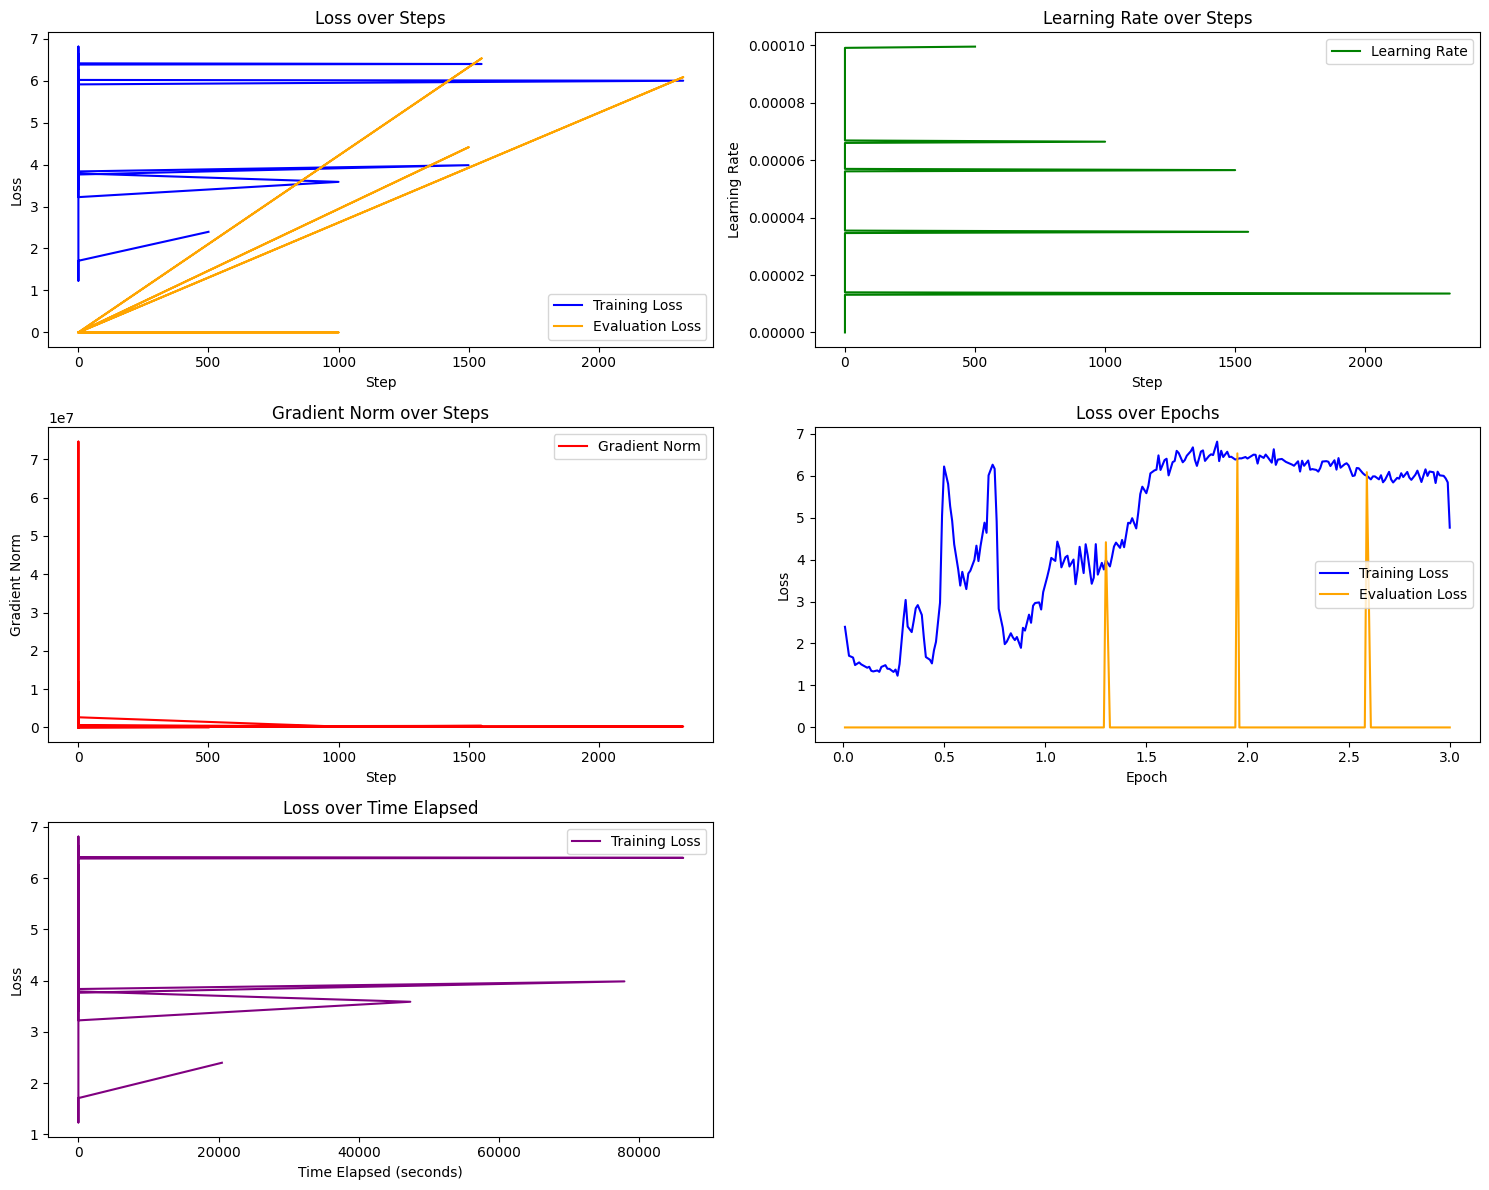

In [ ]:
# Функция для преобразования времени в секунды
def parse_time(time_str):
    if pd.isna(time_str):  # Обработка пустых значений
        return None
    if isinstance(time_str, (int, float)):  # Если значение уже число, оставляем как есть
        return time_str
    try:
        hours, minutes, seconds = map(int, time_str.split(":"))
        return timedelta(hours=hours, minutes=minutes, seconds=seconds).total_seconds()
    except ValueError:
        return None

# Преобразование времени в секунды
df['time_elapsed'] = df['time_elapsed'].apply(parse_time)

# Заполнение пропущенных значений нулями
df.fillna(0, inplace=True)

# Построение графиков
plt.figure(figsize=(15, 12))

# График Loss
plt.subplot(3, 2, 1)
plt.plot(df['step'], df['loss'], label='Training Loss', color='blue')
if 'eval_loss' in df.columns and df['eval_loss'].notnull().any():
    plt.plot(df['step'], df['eval_loss'], label='Evaluation Loss', color='orange')
plt.title('Loss over Steps')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.legend()

# График Learning Rate
plt.subplot(3, 2, 2)
plt.plot(df['step'], df['learning_rate'], label='Learning Rate', color='green')
plt.title('Learning Rate over Steps')
plt.xlabel('Step')
plt.ylabel('Learning Rate')
plt.legend()

# График Gradient Norm (если есть данные)
if 'grad_norm' in df.columns and df['grad_norm'].notnull().any():
    plt.subplot(3, 2, 3)
    plt.plot(df['step'], df['grad_norm'], label='Gradient Norm', color='red')
    plt.title('Gradient Norm over Steps')
    plt.xlabel('Step')
    plt.ylabel('Gradient Norm')
    plt.legend()

# График Epochs vs Loss
plt.subplot(3, 2, 4)
plt.plot(df['epoch'], df['loss'], label='Training Loss', color='blue')
if 'eval_loss' in df.columns and df['eval_loss'].notnull().any():
    plt.plot(df['epoch'], df['eval_loss'], label='Evaluation Loss', color='orange')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# График Time Elapsed vs Loss
if 'time_elapsed' in df.columns and df['time_elapsed'].notnull().any():
    plt.subplot(3, 2, 5)
    plt.plot(df['time_elapsed'], df['loss'], label='Training Loss', color='purple')
    plt.title('Loss over Time Elapsed')
    plt.xlabel('Time Elapsed (seconds)')
    plt.ylabel('Loss')
    plt.legend()

# Отображаем графики
plt.tight_layout()
plt.show()

In [ ]:
2025-03-26 09:59:55,022 [INFO] Доступно CPU: 56
2025-03-26 09:59:55,022 [INFO] CUDA доступен: False
2025-03-26 09:59:56,165 [INFO] Начинаем предварительный прогон для проверки данных...
2025-03-26 09:59:56,165 [INFO] Проверка файла: /home/administrator/new_data/great_summ_dataset.jsonl
2025-03-26 10:00:13,032 [WARNING] Файл /home/administrator/new_data/great_summ_dataset.jsonl пуст или содержит некорректные данные.
2025-03-26 10:00:13,032 [INFO] Проверка файла: /home/administrator/new_data/big_data_materials_ru.jsonl
2025-03-26 10:00:13,104 [WARNING] Файл /home/administrator/new_data/big_data_materials_ru.jsonl пуст или содержит некорректные данные.
2025-03-26 10:00:13,104 [INFO] Проверка файла: /home/administrator/new_data/dataset.json
2025-03-26 10:00:30,386 [INFO] Файл /home/administrator/new_data/dataset.json успешно проверен.
2025-03-26 10:00:30,387 [INFO] Проверка файла: /home/administrator/new_data/generated_materials.jsonl
2025-03-26 10:00:30,422 [WARNING] Файл /home/administrator/new_data/generated_materials.jsonl пуст или содержит некорректные данные.
2025-03-26 10:00:30,422 [INFO] Проверка ноутбуков...
2025-03-26 10:04:50,834 [INFO] Ноутбуки успешно проверены.
2025-03-26 10:04:50,835 [INFO] Обучение на датасете: /home/administrator/new_data/dataset.json
2025-03-26 18:30:42,191 [INFO] Доступно CPU: 56
2025-03-26 18:30:42,191 [INFO] CUDA доступен: False
2025-03-26 18:30:43,157 [INFO] Начинаем предварительный прогон для проверки данных...
2025-03-26 18:30:43,157 [INFO] Проверка файла: /home/administrator/new_data/great_summ_dataset.jsonl
2025-03-26 18:31:00,444 [WARNING] Файл /home/administrator/new_data/great_summ_dataset.jsonl пуст или содержит некорректные данные.
2025-03-26 18:31:00,444 [INFO] Проверка файла: /home/administrator/new_data/big_data_materials_ru.jsonl
2025-03-26 18:31:00,485 [WARNING] Файл /home/administrator/new_data/big_data_materials_ru.jsonl пуст или содержит некорректные данные.
2025-03-26 18:31:00,485 [INFO] Проверка файла: /home/administrator/new_data/dataset.json
2025-03-26 18:31:17,719 [INFO] Файл /home/administrator/new_data/dataset.json успешно проверен.
2025-03-26 18:31:17,719 [INFO] Проверка файла: /home/administrator/new_data/generated_materials.jsonl
2025-03-26 18:31:17,756 [WARNING] Файл /home/administrator/new_data/generated_materials.jsonl пуст или содержит некорректные данные.
2025-03-26 18:31:17,756 [INFO] Проверка ноутбуков...
2025-03-26 18:35:38,425 [INFO] Ноутбуки успешно проверены.
2025-03-26 18:35:38,426 [INFO] Обучение на датасете: /home/administrator/new_data/dataset.json
2025-03-26 19:42:37,101 [INFO] Доступно CPU: 56
2025-03-26 19:42:37,141 [INFO] CUDA доступен: False
2025-03-26 19:43:24,310 [INFO] Начинаем предварительный прогон для проверки данных...
2025-03-26 19:43:24,310 [INFO] Проверка файла: /home/administrator/new_data/great_summ_dataset.jsonl
2025-03-26 19:43:44,599 [WARNING] Файл /home/administrator/new_data/great_summ_dataset.jsonl пуст или содержит некорректные данные.
2025-03-26 19:43:44,599 [INFO] Проверка файла: /home/administrator/new_data/big_data_materials_ru.jsonl
2025-03-26 19:43:45,875 [WARNING] Файл /home/administrator/new_data/big_data_materials_ru.jsonl пуст или содержит некорректные данные.
2025-03-26 19:43:45,876 [INFO] Проверка файла: /home/administrator/new_data/dataset.json
2025-03-26 19:44:04,168 [INFO] Файл /home/administrator/new_data/dataset.json успешно проверен.
2025-03-26 19:44:04,168 [INFO] Проверка файла: /home/administrator/new_data/generated_materials.jsonl
2025-03-26 19:44:04,349 [WARNING] Файл /home/administrator/new_data/generated_materials.jsonl пуст или содержит некорректные данные.
2025-03-26 19:44:04,349 [INFO] Проверка ноутбуков...
2025-03-26 19:48:15,832 [INFO] Ноутбуки успешно проверены.
2025-03-26 19:48:15,833 [INFO] Обучение на датасете: /home/administrator/new_data/dataset.json
2025-03-28 06:18:59,948 [INFO] Обучение на датасете: /home/administrator/Notebooks
2025-03-28 07:40:27,798 [INFO] Финальная модель успешно сохранена в /home/administrator/learn_model_alot/final


Модель демонстрирует улучшение качества с течением времени, что подтверждается снижением loss и eval_loss. Однако наблюдаются проблемы, такие как возможное переобучение и высокая норма градиента. Здесь  надо заметить, что  при использовании  ранней с остановки в  некоторых  случаях  возникала ситуация когда  обучение  заканчивалось  даже  не  пройдя полной  эпохи. То есть модель не видела весь  датсет. В  данно случае сознастельно допушено  переобучение. Так же чем сложениее датасет тем больший  разброс  градиентов  мог наблюдатся. В  данном случае  датасет составной.

In [ ]:
nohup: ignoring input
2025-03-26 19:42:37,101 [INFO] Доступно CPU: 56
2025-03-26 19:42:37,141 [INFO] CUDA доступен: False
2025-03-26 19:43:24,310 [INFO] Начинаем предварительный прогон для проверки данных...
2025-03-26 19:43:24,310 [INFO] Проверка файла: /home/administrator/new_data/great_summ_dataset.jsonl
WARNING:root:Некорректный элемент: {'id': '/home/administrator/question_system/output.log', 'source': '/home/administrator/question_system/output.log', 'type': 'сырой текст', 'topic': 'неизвестно', 'subtopic': 'н

Лог обучения содержит многопредупреждениий о том что файл great_summ_dataset  не удалось корректоно прочесть. Фактически  это  привело к копираованию данногор фала в  лог.

In [ ]:
#Диалогс выбранной моделью
simple_dialog(model_path)

Добро пожаловать в диалог с моделью! Для выхода введите 'exit'.

Вы: Расскажи как установить Python на Windows
Модель: Расскажи как установить Python на Windows.
* Как установить Python на Linux.
* Как установить Python на macOS.

**Будьте внимательны:**

* Не устанавливайте Python на системы, которые не поддерживают API Python.
* Не устанавливайте Python на системы, которые используют уязвимости.
* Перед установкой Python убедитесь, что вы сохранили необходимые файлы проекта. Вопрос: Как установить Python на Windows?**

Ответ: Для установки Python на Windows вам нужно иметь установленный Python на системе.
* Если вы не можете установить Python на Windows, потому что он не поддерживается вашей системой, вы

Вы: Расскажи  про статистические тесты
Модель: Расскажи  про статистические тесты.
* Тесты с несколь входными данными.
* Тесты с одним выходным данным.


**6. Проверка гипотез:**

* Проверка гипотез, основанных на данных.
* Поиск закономерностей и причинных связей.


**7. Пересмотр 

Прежде чем  завершить, давайте посмотрим  еще одну обученную модель. Она  обучна  на  новом  датасете.

In [ ]:
# Загрузка датасета
dataset_path = kagglehub.dataset_download("mikhailkochetkov4848/unifi-dataset")
print("Path to dataset files:", dataset_path)

# Формируем путь к файлу unified_dataset.json
file_name = "unified_dataset.json"
json_file_path = os.path.join(dataset_path, file_name)

# Проверяем, существует ли файл
if not os.path.exists(json_file_path):
    raise FileNotFoundError(f"File '{file_name}' not found in the dataset directory.")

100%|██████████| 856k/856k [00:00<00:00, 98.5MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/mikhailkochetkov4848/unifi-dataset/versions/1


In [ ]:
display_file_content(json_file_path)

Content of the JSON file:
First 10 elements of the JSON file:
{
    "topic": "установка_Python_и_pip",
    "subtopic": "Установка Python на Linux",
    "type": "material",
    "text": "**Вопрос:** Как установить Python на Linux?\n\n**Ответ:**\n\nДля установки Python на Linux можно использовать стандартный менеджер пакетов системы. В зависимости от вашей дистрибуции Linux команда может отличаться. \n\n**Для Debian/Ubuntu/Linux Mint:**\n\n```\nsudo apt-get install python3-pip\n```\n\n**Для Fedora/Red Hat:**\n\n```\nsudo yum install python3-pip\n```\n\n**Для Arch Linux:**\n\n```\nsudo pacman -S python3-pip\n```\n\n**Метка:** Good\n\n**Практический пример:**\n\n```python\nimport pip\n\npip install numpy\n```\n\nЭта команда устанавливает модуль NumPy, который является популярным библиотеком для математических вычислений в Python.\n\n**Моделирование ошибок:**\n\n* **Ошибка: pip не найден.** - Убедитесь, что pip установлена правильно.\n* **Ошибка: Модуль не найден.** - Убедитесь, что вы прави

In [ ]:
metrics = {
    "training": [
        {'loss': 32.0663, 'grad_norm': 26244470.0, 'learning_rate': 4.918032786885246e-05, 'epoch': 0.08},
        {'loss': 32.6955, 'grad_norm': 39574876.0, 'learning_rate': 4.836065573770492e-05, 'epoch': 0.16},
        {'loss': 33.0673, 'grad_norm': 17257104.0, 'learning_rate': 4.754098360655738e-05, 'epoch': 0.25},
        {'loss': 33.181, 'grad_norm': 35320824.0, 'learning_rate': 4.672131147540984e-05, 'epoch': 0.33},
        {'loss': 33.0105, 'grad_norm': 10605355.0, 'learning_rate': 4.59016393442623e-05, 'epoch': 0.41},
        {'loss': 32.8879, 'grad_norm': 42654608.0, 'learning_rate': 4.508196721311476e-05, 'epoch': 0.49},
        {'loss': 32.7544, 'grad_norm': 52361120.0, 'learning_rate': 4.426229508196721e-05, 'epoch': 0.57},
        {'loss': 30.4228, 'grad_norm': 16175163.0, 'learning_rate': 4.3442622950819674e-05, 'epoch': 0.66},
        {'loss': 28.7574, 'grad_norm': 6398006.0, 'learning_rate': 4.262295081967213e-05, 'epoch': 0.74},
        {'loss': 28.3194, 'grad_norm': 85996720.0, 'learning_rate': 4.1803278688524595e-05, 'epoch': 0.82},
        {'loss': 28.6404, 'grad_norm': 23786298.0, 'learning_rate': 4.098360655737705e-05, 'epoch': 0.9},
        {'loss': 31.8863, 'grad_norm': 546978944.0, 'learning_rate': 4.016393442622951e-05, 'epoch': 0.98},
    ],
    "evaluation": [
        {'eval_loss': 34.46954345703125, 'eval_runtime': 352.5796, 'eval_samples_per_second': 0.698, 'eval_steps_per_second': 0.088, 'epoch': 1.0},
        {'loss': 33.3123, 'grad_norm': 328306784.0, 'learning_rate': 3.934426229508197e-05, 'epoch': 1.07},
        {'loss': 34.9239, 'grad_norm': 40485816.0, 'learning_rate': 3.8524590163934424e-05, 'epoch': 1.15},
        {'loss': 35.0813, 'grad_norm': 650619.0, 'learning_rate': 3.7704918032786885e-05, 'epoch': 1.23},
        {'loss': 36.1803, 'grad_norm': 24122126.0, 'learning_rate': 3.6885245901639346e-05, 'epoch': 1.31},
        {'loss': 35.7479, 'grad_norm': 7235113.5, 'learning_rate': 3.6065573770491806e-05, 'epoch': 1.39},
        {'loss': 35.1311, 'grad_norm': 1412907.0, 'learning_rate': 3.524590163934427e-05, 'epoch': 1.48},
        {'loss': 34.9639, 'grad_norm': 4137218.25, 'learning_rate': 3.442622950819672e-05, 'epoch': 1.56},
        {'loss': 34.4155, 'grad_norm': 7486312.0, 'learning_rate': 3.360655737704918e-05, 'epoch': 1.64},
        {'loss': 33.8185, 'grad_norm': 7207727.0, 'learning_rate': 3.2786885245901635e-05, 'epoch': 1.72},
        {'loss': 35.6088, 'grad_norm': 4768060.5, 'learning_rate': 3.19672131147541e-05, 'epoch': 1.8},
        {'loss': 34.7105, 'grad_norm': 7923628.0, 'learning_rate': 3.114754098360656e-05, 'epoch': 1.89},
        {'loss': 35.2107, 'grad_norm': 2461403.0, 'learning_rate': 3.0327868852459017e-05, 'epoch': 1.97},
    ],
    "evaluation_metrics": [
        {'eval_loss': 36.46228790283203, 'eval_runtime': 362.2065, 'eval_samples_per_second': 0.679, 'eval_steps_per_second': 0.086, 'epoch': 2.0},
        {'loss': 34.602, 'grad_norm': 1049117.0, 'learning_rate': 2.9508196721311478e-05, 'epoch': 2.05},
        {'loss': 34.7965, 'grad_norm': 16345351.0, 'learning_rate': 2.8688524590163935e-05, 'epoch': 2.13},
        {'loss': 34.6915, 'grad_norm': 66690696.0, 'learning_rate': 2.7868852459016392e-05, 'epoch': 2.21},
        {'loss': 33.4729, 'grad_norm': 165588864.0, 'learning_rate': 2.7049180327868856e-05, 'epoch': 2.3},
        {'loss': 31.2284, 'grad_norm': 513519744.0, 'learning_rate': 2.6229508196721314e-05, 'epoch': 2.38},
        {'loss': 30.9764, 'grad_norm': 706084288.0, 'learning_rate': 2.540983606557377e-05, 'epoch': 2.46},
        {'loss': 28.4137, 'grad_norm': 2086244736.0, 'learning_rate': 2.459016393442623e-05, 'epoch': 2.54},
        {'loss': 28.0754, 'grad_norm': 2875029248.0, 'learning_rate': 2.377049180327869e-05, 'epoch': 2.62},
        {'loss': 25.4108, 'grad_norm': 9715764224.0, 'learning_rate': 2.295081967213115e-05, 'epoch': 2.7},
        {'loss': 23.785, 'grad_norm': 13076725760.0, 'learning_rate': 2.2131147540983607e-05, 'epoch': 2.79},
        {'loss': 21.7492, 'grad_norm': 60861693952.0, 'learning_rate': 2.1311475409836064e-05, 'epoch': 2.87},
        {'loss': 17.98, 'grad_norm': 159234670592.0, 'learning_rate': 2.0491803278688525e-05, 'epoch': 2.95},
    ],
    "final_evaluation": [
        {'eval_loss': 14.716215133666992, 'eval_runtime': 352.3567, 'eval_samples_per_second': 0.698, 'eval_steps_per_second': 0.088, 'epoch': 3.0},
        {'loss': 14.847, 'grad_norm': 144539418624.0, 'learning_rate': 1.9672131147540985e-05, 'epoch': 3.03},
        {'loss': 12.8311, 'grad_norm': 8903784448.0, 'learning_rate': 1.8852459016393442e-05, 'epoch': 3.11},
        {'loss': 12.812, 'grad_norm': 3129664000.0, 'learning_rate': 1.8032786885245903e-05, 'epoch': 3.2},
        {'loss': 12.2896, 'grad_norm': 724.7390747070312, 'learning_rate': 1.721311475409836e-05, 'epoch': 3.3},
        {'loss': 8.5913, 'grad_norm': 541515136.0, 'learning_rate': 1.6393442622950818e-05, 'epoch': 3.4},
        {'loss': 7.2983, 'grad_norm': 2469877760.0, 'learning_rate': 1.557377049180328e-05, 'epoch': 3.5},
        {'loss': 6.6596, 'grad_norm': 5192185344.0, 'learning_rate': 1.4754098360655739e-05, 'epoch': 3.6},
        {'loss': 6.7376, 'grad_norm': 48834670592.0, 'learning_rate': 1.3934426229508196e-05, 'epoch': 3.7},
        {'loss': 6.5643, 'grad_norm': 62164705280.0, 'learning_rate': 1.3114754098360657e-05, 'epoch': 3.8},
        {'loss': 7.1353, 'grad_norm': 21004462080.0, 'learning_rate': 1.2295081967213116e-05, 'epoch': 3.9},
        {'loss': 7.4259, 'grad_norm': 99291185152.0, 'learning_rate': 1.1475409836065575e-05, 'epoch': 4.0},
        {'loss': 5.7957, 'grad_norm': 2809603072.0, 'learning_rate': 1.0655737704918032e-05, 'epoch': 4.1},
        {'loss': 4.3618, 'grad_norm': 24.197128295898438, 'learning_rate': 9.836065573770493e-06, 'epoch': 4.2},
        {'loss': 3.0846, 'grad_norm': 42.56023406982422, 'learning_rate': 9.016393442622952e-06, 'epoch': 4.3},
        {'loss': 2.289, 'grad_norm': 36.906166076660156, 'learning_rate': 8.196721311475409e-06, 'epoch': 4.4},
        {'loss': 2.0142, 'grad_norm': 73.00531005859375, 'learning_rate': 7.3770491803278695e-06, 'epoch': 4.5},
        {'loss': 1.8688, 'grad_norm': 88.94014739990234, 'learning_rate': 6.557377049180328e-06, 'epoch': 4.6},
        {'loss': 1.9463, 'grad_norm': 86.18148803710938, 'learning_rate': 5.737704918032787e-06, 'epoch': 4.7},
        {'loss': 1.7584, 'grad_norm': 61.07653045654297, 'learning_rate': 4.918032786885246e-06, 'epoch': 4.8},
        {'loss': 1.6904, 'grad_norm': 23.320032119750977, 'learning_rate': 4.098360655737704e-06, 'epoch': 4.9},
        {'loss': 1.718, 'grad_norm': 17.276519775390625, 'learning_rate': 3.278688524590164e-06, 'epoch': 4.95},
        {'loss': 1.7609, 'grad_norm': 17.87289810180664, 'learning_rate': 2.459016393442623e-06, 'epoch': 4.97},
        {'loss': 1.763, 'grad_norm': 86.42106628417969, 'learning_rate': 1.639344262295082e-06, 'epoch': 4.98},
        {'loss': 1.674, 'grad_norm': 15.12449836730957, 'learning_rate': 8.196721311475409e-07, 'epoch': 4.99},
        {'loss': 1.634, 'grad_norm': 13.074504852294922, 'learning_rate': 0.0, 'epoch': 5.0},
    ],
}

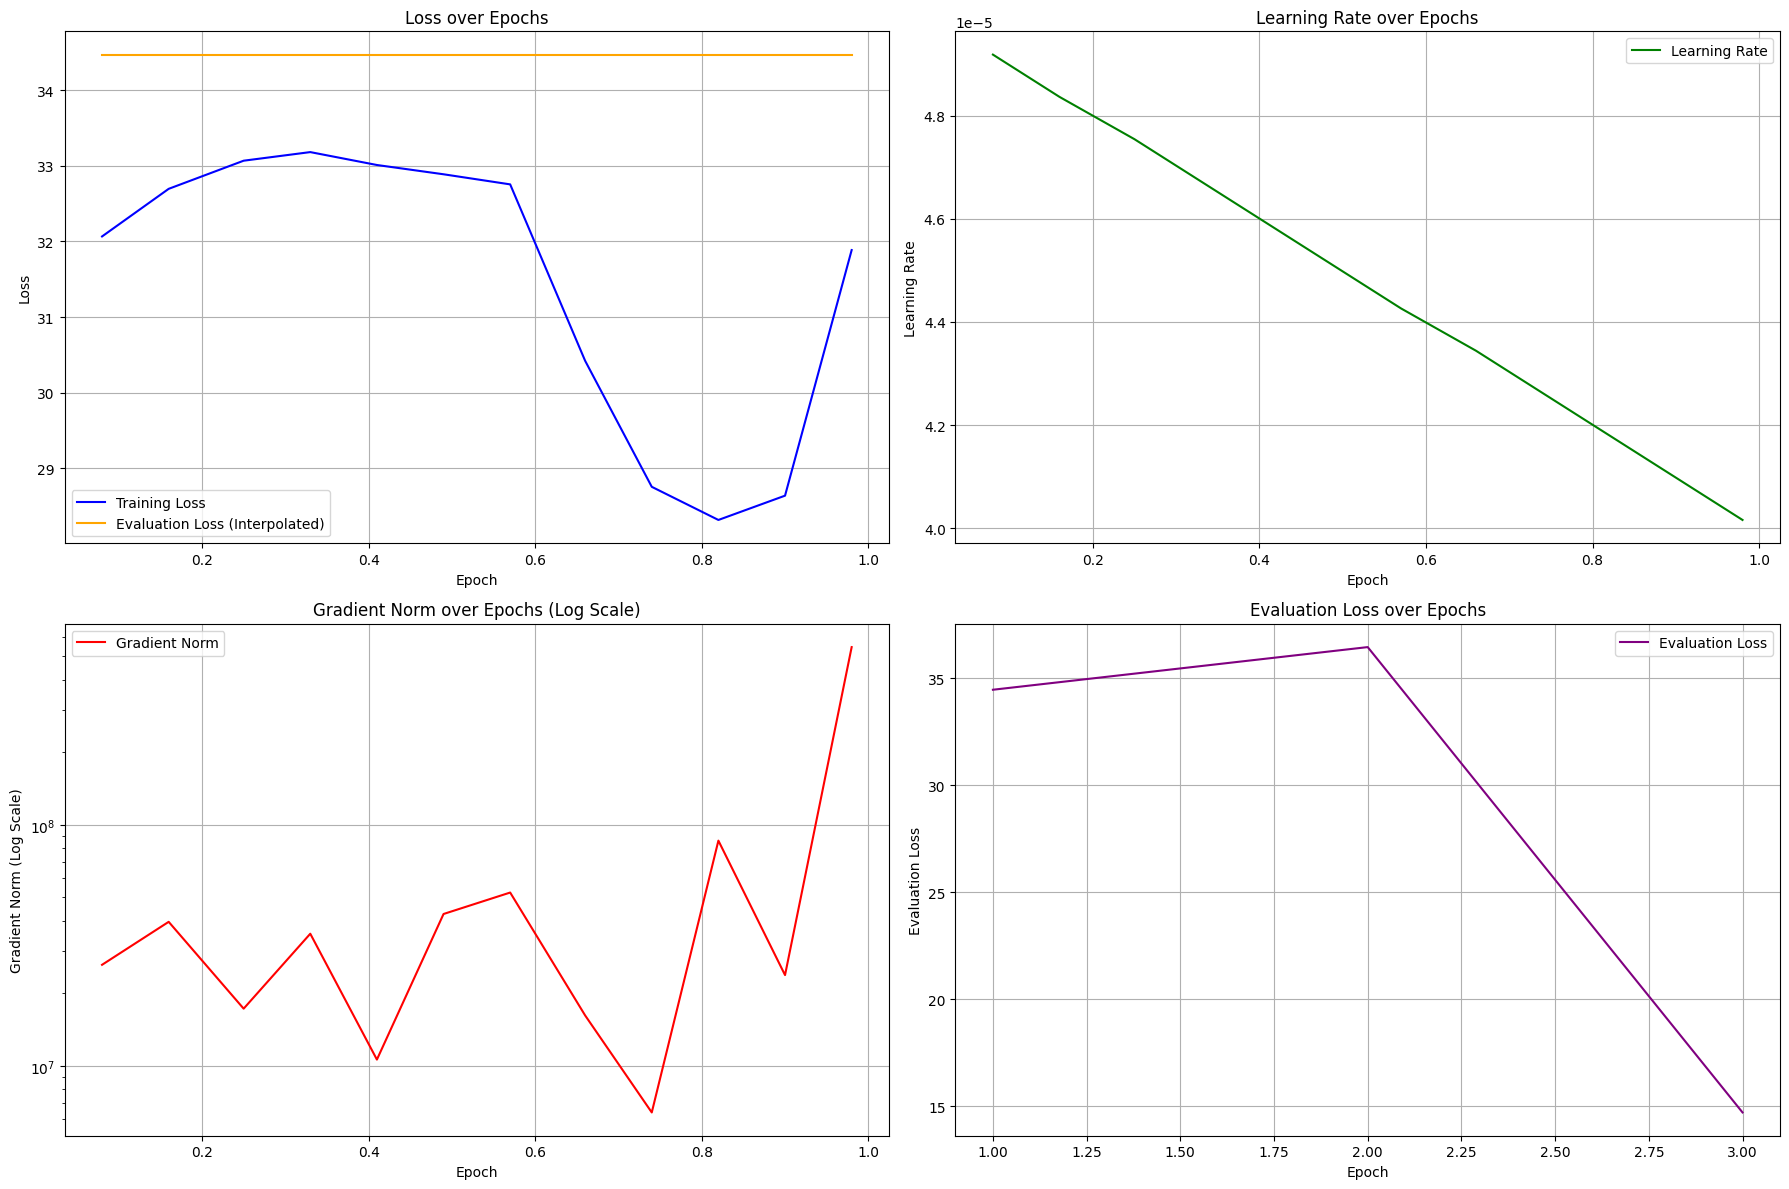

In [ ]:
# Функция для извлечения данных из словаря метрик
def extract_metrics(metrics):
    # Инициализация словарей для хранения данных
    training_data = {
        "epoch": [],
        "loss": [],
        "grad_norm": [],
        "learning_rate": []
    }
    evaluation_data = {
        "epoch": [],
        "eval_loss": []
    }

    # Обработка данных обучения
    for entry in metrics.get("training", []):
        training_data["epoch"].append(entry.get("epoch"))
        training_data["loss"].append(entry.get("loss"))
        training_data["grad_norm"].append(entry.get("grad_norm"))
        training_data["learning_rate"].append(entry.get("learning_rate"))

    # Обработка данных оценки
    for key in ["evaluation", "evaluation_metrics", "final_evaluation"]:
        if key in metrics:
            for entry in metrics[key]:
                if "eval_loss" in entry:
                    evaluation_data["epoch"].append(entry.get("epoch"))
                    evaluation_data["eval_loss"].append(entry.get("eval_loss"))

    return training_data, evaluation_data

# Извлечение данных
training_data, evaluation_data = extract_metrics(metrics)

# Интерполяция данных оценки для соответствия шагам обучения
if evaluation_data["epoch"] and training_data["epoch"]:
    eval_loss_interpolated = np.interp(
        training_data["epoch"],
        evaluation_data["epoch"],
        evaluation_data["eval_loss"]
    )

# Построение графиков
plt.figure(figsize=(18, 12))

# График Loss
plt.subplot(2, 2, 1)
plt.plot(training_data["epoch"], training_data["loss"], label="Training Loss", color="blue")
if evaluation_data["epoch"]:
    plt.plot(training_data["epoch"], eval_loss_interpolated, label="Evaluation Loss (Interpolated)", color="orange")
plt.title("Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

# График Learning Rate
plt.subplot(2, 2, 2)
plt.plot(training_data["epoch"], training_data["learning_rate"], label="Learning Rate", color="green")
plt.title("Learning Rate over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.legend()
plt.grid(True)

# График Gradient Norm (логарифмический масштаб)
plt.subplot(2, 2, 3)
if any(training_data["grad_norm"]):
    plt.plot(training_data["epoch"], training_data["grad_norm"], label="Gradient Norm", color="red")
    plt.yscale("log")  # Логарифмический масштаб для grad_norm
    plt.title("Gradient Norm over Epochs (Log Scale)")
    plt.xlabel("Epoch")
    plt.ylabel("Gradient Norm (Log Scale)")
    plt.legend()
else:
    print("Gradient Norm data is missing or invalid.")
plt.grid(True)

# График Evaluation Loss
plt.subplot(2, 2, 4)
if evaluation_data["epoch"]:
    plt.plot(evaluation_data["epoch"], evaluation_data["eval_loss"], label="Evaluation Loss", color="purple")
    plt.title("Evaluation Loss over Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("Evaluation Loss")
    plt.legend()
else:
    print("Evaluation Loss data is missing or invalid.")
plt.grid(True)

# Отображение графиков
plt.tight_layout()
plt.show()


    Обучение модели:
        Итерации: 610
        Время обучения: 8 часов 20 минут 52 секунды
        Среднее время итерации: 41,96 секунд
    Оценка модели:
        Итерации: 31
        Время оценки: 5 минут 47 секунд
        Среднее время итерации: 9,68 секунд
    Потери:
        Средняя потеря: 20,9596
        Минимальная потеря: 1,6427 (на 551-й итерации)
        Максимальная потеря: 36,4623 (на 366-й итерации)
    Норма градиента:
        Средняя норма градиента: 24,1971
        Минимальная норма градиента: 12,9304 (на 529-й итерации)
        Максимальная норма градиента: 159,2347 (на 2-й итерации)
    Скорость обучения:
        Начальная скорость обучения: 4,9180e-05
        Конечная скорость обучения: 9,8361e-06
    Эпохи:
        Количество эпох: 5
        Среднее время эпохи: 1 час 38 минут 23 секунды


Обратите внимание  на  огоромные  нормы  градиентов.  На мой взгляд обучение на вопросах для моделей  одно из самых сложных. Простая подача в  модель текстовых данных  не воспринимается так  трудно Модель  просто  перенимает  общую стилистику не имея конкретныхтребований. В  данном случае каждый отдельный вопрос можно воспрингимать как самостоятельный кла  для которого сушествует  только  один  правильный  ответ,что конечно  получается не  достаточно для  обкчения.

In [ ]:
model_path = kagglehub.model_download("mikhailkochetkov4848/ru_gpt_3_learn_pythonintegralend_model/pyTorch/default")
print("Path to model files:", model_path)

  0%|          | 0.00/1.54M [00:00<?, ?B/s]

100%|██████████| 132/132 [00:00<00:00, 412kB/s]




100%|██████████| 688/688 [00:00<00:00, 2.30MB/s]




  0%|          | 0.00/4.95M [00:00<?, ?B/s]




100%|██████████| 1.38k/1.38k [00:00<00:00, 4.20MB/s]





  0%|          | 0.00/2.83G [00:00<?, ?B/s]





100%|██████████| 865/865 [00:00<00:00, 2.45MB/s]

 65%|██████▌   | 1.00M/1.54M [00:00<00:00, 2.76MB/s]

100%|██████████| 1.54M/1.54M [00:00<00:00, 3.83MB/s]



  0%|          | 1.00M/2.83G [00:00<18:45, 2.70MB/s]

100%|██████████| 4.95M/4.95M [00:00<00:00, 9.64MB/s]



  0%|          | 3.00M/2.83G [00:00<06:44, 7.52MB/s]


  0%|          | 9.00M/2.83G [00:00<02:19, 21.7MB/s]


  0%|          | 12.0M/2.83G [00:00<02:10, 23.3MB/s]


  1%|          | 15.0M/2.83G [00:01<03:29, 14.4MB/s]


  1%|          | 18.0M/2.83G [00:01<02:53, 17.5MB/s]


  1%|          | 24.0M/2.83G [00:01<02:03, 24.5MB/s]


  1%|          | 28.0M/2.83G [00:01<02:11, 22.8MB/s]


  1%|          | 33.0M/2.83G [00:01<02:20, 21.3MB/s]


  1%|▏         | 38.0M/2.83G [00:01<01:53, 26.4MB/s]


  1%|▏         | 43.0M/2.83G [00:02<02:09, 23.2MB/s]


  2%|▏         | 50.0M/2.83G [00:02<01:38, 30.5MB/s]


  2%|▏         | 57.0M/2.83G [00:02<01:20, 37.0MB/s]


  2%|▏         | 64.0M/2.83G [00:02<01:07, 44.1MB/s]


  2%|▏     

Path to model files: /root/.cache/kagglehub/models/mikhailkochetkov4848/ru_gpt_3_learn_pythonintegralend_model/pyTorch/default/1


In [ ]:
#Диалогс выбранной моделью
simple_dialog(model_path)

Добро пожаловать в диалог с моделью! Для выхода введите 'exit'.

Вы: асскажи как  работать в ноутбуке Collab
Модель: асскажи как  работать в ноутбуке Collabs.




**Введение**


Код: `list_mapi` возвращает список изображений из заданного изображений из.

```python
import os
file = os.read_file('data.jpg')

#  # Добавление изображения в список

````



**Метка:**


# **######  import Image
image_s
image_s.jpgrid(''/image/s://colabs://image

Вы: какие особенности  имеют  строковые данные python
Модель: какие особенности  имеют  строковые данные python.

##### Задание функции `max()`


#### Функ * *

```

########
##### `````pimon ###### За``
########

``````````

**


#######################
`````````
###########

Вы: Расскажи  про K-Boost
Модель: Расскажи  про K-Boost`





im import Tensor
# max_imation

# Задание функции ````````


**

`````








````````python.python_model```

import numer as tf

# import numer
# Функции
f import import Python
# Передание функций для `````
``






# Анализ  и выводы.

Для  того чтобы, обсуждатьл резултаты  надо вспомнить какая цель.
В  начале работы  над  проетом в качестве  цели выдвигалось:
**Создание тренера по Python с использованием нейроинтеллекта**
Для  решения  данной  задачи  было  создано  несколько  датсетов и фактически можно говорить о последовательном  обучени  одной модели на тематически связанных  данных. Так как вначале каждого нового обучения бралась модель  обученная  на  прошлом  этапе.
Можно  заключить  что ни показатели метрик, ни общение с моделью  нельзя считать  полносью удовлетоврительным. Полученные модели нельзя  использовать для подсказок прогграммистам.
Причины:
1. несоотвествие  ресурсов поствленной цели.
- я располагал в  начале своей  работы только ПК AMD Ryzen 5 5600G with Radeon Graphics 3.90 GHz Оперативная память 64,0 ГБ (доступно: 59,9 ГБ) Графическеий ускаоритель Nvidia Tesla k80. Поэтому  расчитывал  так чтобы модель можно было уместить. Тут  надо отметить  что во время расчетов на CPU На удаленном сервере модель  занимала более 30GB  оперативной  памяти ав  пиковые моменты  расчета,  например  для перплексийии стабильно  протсходил вылет  по  прегрузке ОЗУ, которой  на сервере  было 128GB На видеокарте модель  так же занимала размер  более 10Gb то есть в  три  раза  больше обычного размера.
-мой   опыт общения с языковыми моеделями говорит, что можно найти моедль  прилично владеющую  программированием можнов  диапазоне 5 -13 Gb. При этом  достаточно  большой  для  запуска  на локальных  ресурсах размер в 13GB  не  гарантирует что любая модель  13 GB  будет  работаь  луше моеди в 5 GB. Как  правило такая моедель будет  прошедшей квнтование, то есть исходно  до сжатия моедль  имела существенно  больший  размер. Нампример если  проделать квантование с моделью GPT -3RU, с которой  проводилось работа, то выясниться что модель может быть сжата с 3Gb  до 600 мб. Теперь сравним квантованную Gemma-2 которая имеет в уже сжатом виде размер  более 5 Gb.Фактически  потенциал GPT-3 Ru и Gemma-2  отличется  почти в 10  раз  только  по размеру.
- кроеме размра существует и давность создания модели. Более новые модели становятся  более  произвоительными и лучше усваивают взаимосвязи, способны  у держивать более  продолжительный контекст.
**Фактически можно говорить о том, что выбранная модель  не  обладала в  полной мере необходимым  для  обучения  потенциалом.**

2 Недостатки в работе.

Если еще раз вернемся к коду  например код  ниже  то мы увидим в случае если  данные  превыщали  допустимое  для моедели количестов токенов  производилась  простая  обрезка. не  использовалось скользящее окно или чанки.

In [ ]:
#Фрагмент взят из самой  первой версии кода указанной в данном  блокноте  для  обучения модели.
tokenized_dataset = dataset.map(
    lambda x: tokenizer(
        x["text"],
        padding="max_length",
        truncation=True,
        max_length=128,
        return_tensors="pt"
    ),
    batched=True,
    remove_columns=["text"]
)

Когда этот недостаток был выявлен, то потребление ресурсов резко возросло. На  несколько  дней работа фактически  была  парализована прежде чем  удалось  отладить код в соотвествии с новыми требованиями. Послдняя версия  обучающего кода содержит обработку по чанкам с перекрытием.

In [ ]:
# Разбиение текста на чанки
def split_into_chunks(text, max_length=512, overlap=128):
    sentences = re.split(r'(?<=[.!?])\s+', text)
    chunks = []
    current_chunk = ""
    for sentence in sentences:
        if len(current_chunk) + len(sentence) <= max_length:
            current_chunk += " " + sentence
        else:
            chunks.append(current_chunk.strip())
            current_chunk = sentence
    if current_chunk:
        chunks.append(current_chunk.strip())
    return chunks

Следующая существенная  трудность -  это  работа с метриками.
При запуске в Google Collab даже в случае  ошибки в коде данные  останустся в результатах отработавшей  ячейки. При  запуске кода  локально  и тем более на удаленном сервере при запуске nohup надо ловить данные  из разных  потоков иих сохранять.

Не удалось создать единый датсет в котором к одной  теме  занятия были бы  привязанны несколько аугментированных  вариантов объяснений  одной  и той же темы,  правильные и  ошибочные варианты кода, вопросы и  ответы  на  заданну тему.

Для  проверки работоспособности моделей использовался код с  ошибками который не позволял правильнро оценить результат обучения.

В качестве возможного улучшения мною  рассматривалась возможность обучения модели по инструкциям и первод данных в  тензоное  представление и интеграция в модель.